<a href="https://colab.research.google.com/github/aislam2346/aislam/blob/main/NYC_Taxi_Pipeline_Clean_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Setup

In [ ]:
# Fix for numpy/numba compatibility issue by explicitly managing versions
# !pip uninstall numba numpy -y
# !pip install "numpy<2.0.0"
# !pip install "numba>=0.61"
# !pip install shap
# !pip install river
# !pip install "numba>=0.61" river shap --upgrade

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import numpy as np
import requests
import os
import hashlib
import json
import gc
import shutil
import holidays
from calendar import month_name
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import ks_2samp, chi2_contingency, spearmanr
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import warnings
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

warnings.filterwarnings('ignore')


In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Raw parquet files — where TLC files live on your Drive
PARQUET_DIR = Path("/content/drive/MyDrive/ODATA57078/nyc_taxi_parquet_files")

# Support files
ZONE_LOOKUP_PATH = Path("/content/drive/MyDrive/ODATA57078/taxi_zone_lookup.csv")

ZONE_LOOKUP_SHP_PATH = Path("/content/drive/MyDrive/ODATA57078/taxi_zones")

# Output folders — created automatically if missing
BASE     = Path("/content/drive/MyDrive/ODATA57078")
STAGING_DIR = BASE / "staging"       # one parquet per month, e.g. staging/2019-01.parquet
GOLD_DIR = BASE / "gold"          # one parquet per month, e.g. gold/2019-01.parquet
FEAT_DIR = BASE / "features"      # final modeling table
CKPT_DIR = BASE / "checkpoints"   # watermark.json lives here
OUT_DIR  = BASE / "eda_outputs"   # saved plots
MODEL_DIR = BASE / "models"       # saved models
PREDICT_DIR = BASE / "predictions" # saved predictions
DRIFT_DIR = BASE / "drift_outputs" # saved drift outputs

for d in [STAGING_DIR, GOLD_DIR, FEAT_DIR, CKPT_DIR, OUT_DIR, PREDICT_DIR, DRIFT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── DuckDB — lives in /tmp, NOT on Drive ─────────────────────────────────────
# /tmp is wiped when Colab disconnects, which is fine
# staging and gold parquet files on Drive are the real persistent storage.
DB_PATH = Path("/tmp/taxi_work.duckdb")  # fast working copy

def get_connection():
    con = duckdb.connect(DB_PATH)
    con.execute("PRAGMA threads=4")
    con.execute("PRAGMA memory_limit='3GB'")
    return con

# ── Months to process ────────────────────────────────────────────────────────
# The watermark means already-completed months are always skipped.
MONTHS_TO_INGEST = [
    '2019-01', '2019-02', '2019-03',
    '2019-04', '2019-05', '2019-06',
    '2019-07', '2019-08', '2019-09',
    '2019-10', '2019-11', '2019-12',
    '2020-01', '2020-02', '2020-03',
    '2020-04', '2020-05', '2020-06',
    '2020-07', '2020-08', '2020-09',
    '2020-10', '2020-11', '2020-12',
    '2021-01'
]

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
})
COLORS = {
    'primary': '#4C9BE8', 'secondary': '#F5A623',
    'green': '#50C878',   'purple': '#A78BFA', 'red': '#E85D75',
}

print("Section 1 complete — paths and imports ready")
print(f"   GOLD_DIR : {GOLD_DIR}")
print(f"   DB_PATH  : {DB_PATH}  (local /tmp — not on Drive)")

Section 1 complete — paths and imports ready
   GOLD_DIR : /content/drive/MyDrive/ODATA57078/gold
   DB_PATH  : /tmp/taxi_work.duckdb  (local /tmp — not on Drive)


In [ ]:
# Read saved parquet files
df_gold_2019 = pd.read_parquet(GOLD_DIR / 'all_gold_2019.parquet')
df_zone_2019 = pd.read_parquet(FEAT_DIR / 'all_zone_aggregated_2019.parquet')
df_gold_2020 = pd.read_parquet(GOLD_DIR / 'all_gold_2020.parquet')
df_zone_2020 = pd.read_parquet(FEAT_DIR / 'all_zone_aggregated_2020.parquet')

In [ ]:
# # Run this chunk to read saved objects generated in subsequent steps such as baseline modelling
# # and drift detection preparation

# # 1. HISTORICAL FEATURES
# # Load saved features parquet
# df_2019 = pd.read_parquet(FEAT_DIR/ "df_2019_features.parquet")
# # display(df_2019.head())

# # 2. BASELINE MODELLING
# # Load saved model
# with open(MODEL_DIR / "model_with_more_features.pkl", "rb") as f:
#   baseline_model = pickle.load(f)
# print(f" Model loaded — best iteration: {baseline_model.best_iteration_}")

# # Model prediction tables

# # Read from parquets
# df_2020_model = pd.read_parquet(BASE / "predictions" / "2020_predictions_full.parquet")
# # display(df_2020_model.head())

# # 3. DRIFT ANALYSIS
# # Read saved drift detection data
# DRIFT_DATA = BASE / 'drift_data'
# # drift_data_parquet_directory = DRIFT_DATA / "full_drift_data_no_boundary_rows.parquet"
# drift_data_parquet_directory = DRIFT_DATA / "drift_data_with_more_feat_no_boundary_rows.parquet"
# df_drift = pd.read_parquet(drift_data_parquet_directory)

# # Read drift data saved in csv files

# # Monthly Drift table
# monthly_drift = pd.read_csv(DRIFT_DIR / "monthly_drift_table.csv")
# # display(monthly_drift.head(20))

# # Overall Drift table
# overall_drift_table = pd.read_csv(DRIFT_DIR / "overall_drift_table.csv")
# # display(overall_drift_table.head(20))


In [ ]:
# 1. HISTORICAL FEATURES
# Load saved features parquet
# df_2019 = pd.read_parquet(FEAT_DIR/ "df_2019_features.parquet")
# display(df_2019.head())

In [ ]:
# df_2019.info()

In [ ]:
# df_2020_model.info()

In [ ]:
# # Print out baseline model metadata

# # Get Parameters
# params = baseline_model.get_params()
# print("Parameters:")
# for param, value in params.items():
#     print(f"{param}: {value}")

# # Get feature names
# feature_names = baseline_model.feature_name_
# print("\nFeature Names:")
# print(feature_names)

# # Get feature importance
# feature_importance = baseline_model.feature_importances_
# print("\nFeature Importance:")
# print(feature_importance)

In [ ]:
# df_2020_model = pd.read_parquet(BASE / "predictions" / "2020_predictions_full.parquet")

# # print(type(df_2020_model))  # Should show <class 'pandas.core.frame.DataFrame'>
# # if df_2020_model is not None:
# #     print(df_2020_model.columns)

## Section 2: Define Schema and Watermark

In [ ]:
# ── Schema bootstrap ──────────────────────────────────────────────────────────
# raw_taxi_trips and staging_taxi_trips are TEMP tables — they exist only
# for the duration of processing one month, then disappear automatically.
# gold_hourly_demand and weather_hourly are permanent in /tmp DuckDB,
# but their durable copy is the parquet files on Drive.

def bootstrap_schema(con):
    """Create all tables. Safe to call every session — idempotent."""

    # Watermark — tracks what has been ingested (permanent, small)
    con.execute("""
        CREATE TABLE IF NOT EXISTS pipeline_watermark (
            file_name   VARCHAR PRIMARY KEY,
            file_month  VARCHAR,
            checksum    VARCHAR,
            row_count   BIGINT,
            ingested_at TIMESTAMP,
            layer       VARCHAR
        )
    """)

    # Raw — TEMP: holds one month of raw parquet data during processing
    # Dropped automatically when the connection closes
    con.execute("""
        CREATE TEMP TABLE IF NOT EXISTS raw_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       DOUBLE,
            trip_distance         DOUBLE,
            RatecodeID            DOUBLE,
            store_and_fwd_flag    VARCHAR,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          BIGINT,
            fare_amount           DOUBLE,
            extra                 DOUBLE,
            mta_tax               DOUBLE,
            tip_amount            DOUBLE,
            tolls_amount          DOUBLE,
            improvement_surcharge DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            airport_fee           DOUBLE,
            file_name             VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP
        )
    """)

    # Staging : holds one month of cleaned data during processing
    con.execute("""
        CREATE TEMP TABLE IF NOT EXISTS staging_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       INTEGER,
            trip_distance         DOUBLE,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          INTEGER,
            fare_amount           DOUBLE,
            tip_amount            DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            trip_duration_mins    DOUBLE,
            pickup_hour           INTEGER,
            pickup_dow            INTEGER,
            pickup_month          INTEGER,
            is_weekend            BOOLEAN,
            time_of_day           VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP,
            rowhash               VARCHAR
        )
    """)

    # Gold — permanent in DuckDB session, but real persistence is parquet on Drive
    # Removed weather details - temporary fix.
    con.execute("""
      CREATE OR REPLACE TABLE gold_hourly_demand (
          pickup_hour_ts       TIMESTAMP,
          file_month           VARCHAR,
          PULocationID         INTEGER,
          borough              VARCHAR,
          service_zone         VARCHAR,
          zone                 VARCHAR,
          trip_count           BIGINT,
          pct_card_payment     DOUBLE,
          pct_cash_payment     DOUBLE,
          avg_trip_distance    DOUBLE,
          avg_fare_amount      DOUBLE,
          avg_duration_mins    DOUBLE,
          avg_passenger_count  DOUBLE,
          hour_of_day          INTEGER,
          day_of_week          INTEGER,
          is_weekend           BOOLEAN,
          is_holiday           BOOLEAN
      )
""")

    # Schema for aggregated results by zone and hour for EDA and modelling
    # same as gold, removed weather details
    con.execute("""
    CREATE OR REPLACE TABLE zone_features (
        pickup_hour_ts        TIMESTAMP,
        file_month            VARCHAR,
        borough               VARCHAR,
        service_zone          VARCHAR,
        zone                  VARCHAR,
        trip_count            BIGINT,
        avg_trip_distance     DOUBLE,
        avg_fare_amount       DOUBLE,
        avg_duration_mins     DOUBLE,
        avg_passenger_count   DOUBLE,
        pct_card_payment      DOUBLE,
        pct_cash_payment      DOUBLE,
        hour_of_day           INTEGER,
        day_of_week           INTEGER,
        is_weekend            BOOLEAN,
        is_holiday            BOOLEAN
    )
  """)

    # Weather — permanent in DuckDB session (fetched once from API)
    # con.execute("""
    #     CREATE TABLE IF NOT EXISTS weather_hourly (
    #         weather_ts         TIMESTAMP PRIMARY KEY,
    #         temperature_2m     DOUBLE,
    #         precipitation      DOUBLE,
    #         snowfall           DOUBLE,
    #         windspeed_10m      DOUBLE,
    #         weathercode        INTEGER,
    #         is_snowing         BOOLEAN,
    #         is_raining         BOOLEAN,
    #         is_extreme_weather BOOLEAN
    #     )
    # """)

    print("  Schema bootstrapped (idempotent)")

In [ ]:
# ── Watermark — JSON on Drive, survives session restarts ──────────────────────
# Used to track ingestion progress - avoids re-ingestion of tables, and thus duplicates.
# The DuckDB watermark table above is kept as a within-session fast lookup.
# The JSON file on Drive is the source of truth across sessions.

WATERMARK_PATH = CKPT_DIR / "watermark.json"

def _load_watermark_json():
    """Load watermark from Drive JSON. Returns empty dict on first run."""
    if WATERMARK_PATH.exists():
        return json.loads(WATERMARK_PATH.read_text())
    return {}

def _save_watermark_json(wm: dict):
    """Persist watermark dict back to Drive JSON."""
    WATERMARK_PATH.write_text(json.dumps(wm, indent=2, default=str))

def check_gold_watermark_exists(file_month):
    """
    Check if the gold parquet for a given month is already marked as ingested
    in the persistent watermark (JSON on Drive).
    Returns (True, row_count) if exists and has rows, else (False, 0).
    """
    wm = _load_watermark_json()
    gold_key = f"gold::yellow_tripdata_{file_month}.parquet"
    if gold_key in wm and wm[gold_key]['row_count'] > 0:
        return True, wm[gold_key]['row_count']
    return False, 0

def is_already_processed(base_path, file_name, layer):
    """
    Check if a file exists physically AND is registered in the watermark JSON.
    """
    wm = _load_watermark_json()
    key = f"{layer}::{file_name}"

    # Use os.path.join for safety across different operating systems
    full_path = os.path.join(base_path, file_name)

    # Check 1: Does the file physically exist?
    file_exists = os.path.exists(full_path)

    # Check 2: Is it in the watermark?
    in_watermark = key in wm

    # Check 3: (Optional but recommended) Did it actually have rows?
    # This prevents skipping if a previous run crashed and left an empty file.
    has_rows = wm.get(key, {}).get('row_count', 0) > 0 if in_watermark else False

    return file_exists and in_watermark and has_rows

def file_checksum(path):
    """MD5 checksum of a file — detects if source data changed."""
    md5 = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            md5.update(chunk)
    return md5.hexdigest()

def is_already_processed(file_month):
    """
    Check if gold parquet for this month is registered in the watermark JSON with rows.
    """
    wm = _load_watermark_json()

    file_name = f"yellow_tripdata_{file_month}.parquet"
    gold_path = GOLD_DIR / f"{file_month}.parquet"
    zone_path = FEAT_DIR / f"zone_features_{file_month}.parquet"
    key       = f"gold::{file_name}"

    gold_file_exists  = gold_path.exists()
    zone_file_exists = zone_path.exists()

    file_exists = gold_file_exists and zone_file_exists
    in_watermark = key in wm
    has_rows     = wm.get(key, {}).get('row_count', 0) > 0

    return file_exists and in_watermark and has_rows

def mark_ingested(con, file_name, file_month, checksum, row_count, layer):
    """
    Write to both Drive JSON (persistent) and DuckDB table (fast lookup).
    """
    # Drive JSON — survives session restarts
    wm = _load_watermark_json()
    key = f"{layer}::{file_name}"
    wm[key] = {
        'file_name':   file_name,
        'file_month':  file_month,
        'checksum':    checksum,
        'row_count':   row_count,
        'ingested_at': str(datetime.now()),
        'layer':       layer,
    }
    _save_watermark_json(wm)

    # DuckDB table — fast within-session lookup
    con.execute("""
        INSERT INTO pipeline_watermark
            (file_name, file_month, checksum, row_count, ingested_at, layer)
        VALUES (?, ?, ?, ?, now(), ?)
        ON CONFLICT (file_name) DO UPDATE SET
            checksum    = excluded.checksum,
            row_count   = excluded.row_count,
            ingested_at = excluded.ingested_at,
            layer       = excluded.layer
    """, [file_name, file_month, checksum, row_count, layer])

def show_watermark():
    """Print all ingested files — useful for debugging and audit."""
    wm = _load_watermark_json()
    if not wm:
        print("  No watermark entries yet")
        return
    df = pd.DataFrame(wm.values()).sort_values(['layer', 'file_month'])
    display(df[['layer', 'file_month', 'file_name', 'row_count', 'ingested_at']])

print("Section 2 complete — schema and watermark functions ready")

Section 2 complete — schema and watermark functions ready


## Section 3: Define Ingestion Functions

In [ ]:
def ingest_raw(con, parquet_path, file_month):
    """
    Load one month parquet as-is into raw_taxi_trips TEMP table.
    Validates data integrity natively inside DuckDB before proceeding.
    """
    file_name = parquet_path.name
    checksum  = file_checksum(parquet_path)

    # 1. Idempotency Check / Cache Optimization
    current_temp_row_count = con.execute(
        "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_month = ?", [file_month]
    ).fetchone()[0]

    if current_temp_row_count == 0:
        print(f"  Ingesting raw: {file_name}")

        # Idempotency safety: Clear out any partial remnants for this month before inserting
        con.execute("DELETE FROM raw_taxi_trips WHERE file_month = ?", [file_month])

        con.execute(f"""
            INSERT INTO raw_taxi_trips
            SELECT
                VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
                passenger_count, trip_distance, RatecodeID, store_and_fwd_flag,
                PULocationID, DOLocationID, payment_type, fare_amount, extra,
                mta_tax, tip_amount, tolls_amount, improvement_surcharge,
                total_amount,
                TRY_CAST(congestion_surcharge AS DOUBLE),
                TRY_CAST(airport_fee          AS DOUBLE),
                '{file_name}'  AS file_name,
                '{file_month}' AS file_month,
                now()          AS ingested_at
            FROM read_parquet('{parquet_path}')
        """)

        row_count = con.execute(
            "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_month = ?", [file_month]
        ).fetchone()[0]

        mark_ingested(con, file_name, file_month, checksum, row_count, layer='raw')
        print(f"  Raw  | {file_name} | {row_count:,} rows loaded into TEMP")
    else:
        print(f"  Raw data for {file_month} already present in TEMP table, skipping reload.")

    # ==========================================
    # DATA VALIDATION TESTS (Executed in DuckDB)
    # ==========================================
    print(f"  Running data validation for {file_month}...")

    # Test 1: Schema Consistency
    # Checking if required core infrastructure columns exist in the loaded table
    expected_cols = {
        "vendorid", "tpep_pickup_datetime", "tpep_dropoff_datetime",
        "passenger_count", "trip_distance", "fare_amount", "total_amount", "file_month"
    }
    actual_cols = {row[1].lower() for row in con.execute(f"PRAGMA table_info('raw_taxi_trips')").fetchall()}
    missing_cols = expected_cols - actual_cols
    if missing_cols:
        raise ValueError(f"[VALIDATION FAILED] Missing critical columns in raw schema: {missing_cols}")

    # Test 2: Missing Values (Nulls in Critical Business Keys)
    null_counts = con.execute(f"""
        SELECT
            COUNT(*) FILTER (WHERE tpep_pickup_datetime IS NULL),
            COUNT(*) FILTER (WHERE tpep_dropoff_datetime IS NULL),
            COUNT(*) FILTER (WHERE file_month IS NULL)
        FROM raw_taxi_trips
        WHERE file_month = ?
    """, [file_month]).fetchone()

    if sum(null_counts) > 0:
        raise print(f"[WARNING] Critical nulls found! Pickup nulls: {null_counts[0]}, Dropoff nulls: {null_counts[1]}")

    # Test 3: Invalid / Negative Financial and Distance Values
    # Note: We allow 0 for distance/fare occasionally (system errors/cancelled trips), but strictly reject negatives
    invalid_metrics = con.execute(f"""
        SELECT
            COUNT(*) FILTER (WHERE trip_distance < 0),
            COUNT(*) FILTER (WHERE fare_amount < 0),
            COUNT(*) FILTER (WHERE total_amount < 0)
        FROM raw_taxi_trips
        WHERE file_month = ?
    """, [file_month]).fetchone()

    if sum(invalid_metrics) > 0:
        print(f"[WARNING] Negative values detected! Neg Distance: {invalid_metrics[0]}, Neg Fare: {invalid_metrics[1]}, Neg Total: {invalid_metrics[2]}")

    # Test 4: Duplicate Records Check
    # Validates if identical trip print signatures exist multiple times
    dup_count = con.execute(f"""
        SELECT COUNT(*) FROM (
            SELECT 1 FROM raw_taxi_trips
            WHERE file_month = ?
            GROUP BY VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, PULocationID, DOLocationID, trip_distance, total_amount
            HAVING COUNT(*) > 1
        )
    """, [file_month]).fetchone()[0]

    if dup_count > 0:
        # Depending on your business rules, you can raise an exception or simply log a warning.
        print(f"  [WARNING] {dup_count} duplicate trip footprints detected in month {file_month}.")

    print(f"  ✓ Performed validation checks for {file_month}! Use these checks to revise staging and gold data preprocessing.")
    return True

In [ ]:
# # Quick Test
# con = get_connection()
# bootstrap_schema(con)

# PARQUET_DRIVE = PARQUET_DIR

# # Test parquet path
# test_path = PARQUET_DIR / f"yellow_tripdata_2019-01.parquet"

# # Run Function
# ingest_raw(con, test_path, '2019-01')

# # Close connection safely
# con.close()

In [ ]:
# __ Layer 2: Staging ingestion ________________________________________________
def ingest_staging(con, file_month):
    """
    Promote one month raw → staging with cleaning rules:
      R1: Valid timestamps (non-null, pickup < dropoff, correct year)
      R2: Passenger count 1–6
      R3: Fare >= $2.50, total_amount > 0
      R4: Trip distance 0.1–50 miles
      R5: Trip duration 1–150 minutes
    Also computes rowhash for duplicate detection.
    """
    expected_year = int(file_month.split('-')[0])

    # Pre-cleaning audit — shows how many rows fail each rule
    df_audit = con.execute(f"""
        SELECT
            file_month,
            COUNT(*) AS total_rows,
            SUM(CASE WHEN tpep_pickup_datetime IS NULL
                      OR tpep_dropoff_datetime IS NULL
                      OR tpep_pickup_datetime >= tpep_dropoff_datetime
                      OR YEAR(tpep_pickup_datetime)  != {expected_year}
                      OR YEAR(tpep_dropoff_datetime) != {expected_year}
                                                         THEN 1 ELSE 0 END) AS bad_timestamps,
            SUM(CASE WHEN passenger_count IS NULL
                      OR passenger_count < 1
                      OR passenger_count > 6             THEN 1 ELSE 0 END) AS bad_passengers,
            SUM(CASE WHEN fare_amount IS NULL
                      OR fare_amount < 2.50
                      OR total_amount IS NULL
                      OR total_amount <= 0               THEN 1 ELSE 0 END) AS bad_fares,
            SUM(CASE WHEN trip_distance <= 0.1
                      OR trip_distance > 50              THEN 1 ELSE 0 END) AS bad_distance
        FROM raw_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    """).fetchdf()
    print(f"\n  Pre-cleaning audit for {file_month}:")
    display(df_audit)

    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [file_month])

    con.execute(f"""
          INSERT INTO staging_taxi_trips
          WITH generated_staging_table AS (
              SELECT DISTINCT
                  VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
                  CAST(passenger_count AS INTEGER),
                  trip_distance,
                  PULocationID, DOLocationID,
                  CAST(payment_type AS INTEGER),
                  fare_amount, tip_amount, total_amount, congestion_surcharge,
                  DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) AS trip_duration_mins,
                  HOUR(tpep_pickup_datetime)                        AS pickup_hour,
                  DAYOFWEEK(tpep_pickup_datetime)                   AS pickup_dow,
                  MONTH(tpep_pickup_datetime)                       AS pickup_month,
                  DAYOFWEEK(tpep_pickup_datetime) IN (0, 6)        AS is_weekend,
                  CASE
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 6  AND 11 THEN 'Morning'
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 12 AND 16 THEN 'Afternoon'
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 17 AND 21 THEN 'Evening'
                      ELSE 'Night'
                  END                                               AS time_of_day,
                  file_month,
                  ingested_at,
                  md5(
                      COALESCE(CAST(VendorID             AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(tpep_pickup_datetime AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(tpep_dropoff_datetime AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(PULocationID         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(DOLocationID         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(trip_distance        AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(fare_amount          AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(total_amount         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(passenger_count      AS VARCHAR), '')
                  ) AS rowhash
              FROM raw_taxi_trips
              WHERE file_month = '{file_month}'
                AND tpep_pickup_datetime  IS NOT NULL
                AND tpep_dropoff_datetime IS NOT NULL
                AND tpep_pickup_datetime  < tpep_dropoff_datetime
                AND YEAR(tpep_pickup_datetime)  = {expected_year}
                AND YEAR(tpep_dropoff_datetime) = {expected_year}
                -- Filters out entries which are not in the right file month
                AND MONTH(tpep_pickup_datetime) = MONTH(STRPTIME('{file_month}', '%Y-%m'))
                AND passenger_count IS NOT NULL
                AND passenger_count BETWEEN 1 AND 6
                AND fare_amount  IS NOT NULL
                AND fare_amount  >= 2.50
                AND total_amount IS NOT NULL
                AND total_amount >  0
                AND trip_distance BETWEEN 0.1 AND 50
                AND DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) BETWEEN 1 AND 150
        )

        SELECT * FROM generated_staging_table
        WHERE rowhash NOT IN (
            SELECT DISTINCT rowhash FROM staging_taxi_trips
            WHERE file_month = '{file_month}')

    """)

    # Post-cleaning sense check
    df_sense = con.execute(f"""
        SELECT
            file_month,
            COUNT(*) AS staging_rows,
            COUNT(*) - COUNT(DISTINCT rowhash) AS duplicate_hashes,
            SUM(CASE WHEN rowhash IS NULL THEN 1 ELSE 0 END) AS null_hashes,
            SUM(CASE WHEN fare_amount < 2.50 THEN 1 ELSE 0 END) AS bad_fare_remaining,
            SUM(CASE WHEN passenger_count NOT BETWEEN 1 AND 6 THEN 1 ELSE 0 END) AS bad_pax_remaining,
            SUM(CASE WHEN total_amount <= 0 THEN 1 ELSE 0 END) AS bad_total_remaining,
            SUM(CASE WHEN trip_duration_mins NOT BETWEEN 1 AND 150 THEN 1 ELSE 0 END) AS bad_duration_remaining
        FROM staging_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    """).fetchdf()

    print(f"\n  Post-cleaning sense check for {file_month}:")

    if df_sense.empty:
        print(f"  [WARNING] No staging rows found for {file_month}.")
        return False

    stats = df_sense.iloc[0]
    file_month = stats["file_month"]
    staging_rows = int(stats["staging_rows"])
    duplicate_hashes = int(stats["duplicate_hashes"])
    null_hashes = int(stats["null_hashes"])
    bad_fare_remaining = int(stats["bad_fare_remaining"])
    bad_pax_remaining = int(stats["bad_pax_remaining"])
    bad_total_remaining = int(stats["bad_total_remaining"])
    bad_duration_remaining = int(stats["bad_duration_remaining"])

    if staging_rows == 0:
        print(f"  [WARNING] 0 rows reached staging for {file_month}. Check raw data quality.")
        return False

    if duplicate_hashes > 0:
        raise ValueError(
            f"[VALIDATION FAILED] Staging duplicates found: {duplicate_hashes} duplicate rowhash values."
        )

    if null_hashes > 0:
        raise ValueError(
            f"[VALIDATION FAILED] {null_hashes} null rowhash values found."
        )

    if bad_fare_remaining > 0 or bad_pax_remaining > 0 or bad_total_remaining > 0 or bad_duration_remaining > 0:
        raise ValueError(
            f"[VALIDATION FAILED] Remaining bad values for {file_month}: "
            f"fare={bad_fare_remaining}, pax={bad_pax_remaining}, "
            f"total={bad_total_remaining}, duration={bad_duration_remaining}"
        )

    print(f"  Staging | {file_month} | {staging_rows:,} valid rows (0 duplicates)")
    return True


In [ ]:
def build_gold(con, file_month, zone_lookup_path=None):
    """
    Aggregate staging -> gold at hourly grain per pickup zone.
    Grain: (pickup_hour_ts, PULocationID)
    """
    # Load zone lookup once
    try:
        con.execute("SELECT 1 FROM taxi_zones LIMIT 1")
    except Exception:
        src = zone_lookup_path or str(ZONE_LOOKUP_PATH)
        df_zones = pd.read_csv(src)
        df_zones.columns = df_zones.columns.str.lower().str.strip()
        con.register("taxi_zones", df_zones)
        print(f"  Zone lookup registered: {len(df_zones)} zones")

    # Check zone lookup uniqueness on LocationID
    zone_dups = con.execute("""
        SELECT COUNT(*) FROM (
            SELECT locationid
            FROM taxi_zones
            GROUP BY locationid
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]
    if zone_dups > 0:
        raise ValueError("taxi_zones has duplicate locationid values.")

    # Check weather exists and is unique by hour
    # weather_stats = con.execute(f"""
    #     SELECT
    #         COUNT(*) AS n_rows,
    #         COUNT(DISTINCT weather_ts) AS n_unique
    #     FROM weather_hourly
    #     WHERE weather_ts BETWEEN '{file_month}-01'
    #                          AND '{file_month}-01'::DATE + INTERVAL 1 MONTH
    # """).fetchone()

    # if weather_stats[0] == 0:
    #     print(f"  No weather data found for {file_month} — run ingest_weather() first")
    #     return

    # if weather_stats[0] != weather_stats[1]:
    #     raise ValueError(f"weather_hourly has duplicate timestamps in {file_month}")

    # Holiday table
    nyc_holidays = holidays.US(state="NY", years=[2019, 2020, 2021])
    df_holidays = pd.DataFrame({
        "holiday_date": [str(d) for d in nyc_holidays.keys()]
    })
    con.register("temp_holidays", df_holidays)

    # Idempotent rebuild for this month
    con.execute("DELETE FROM gold_hourly_demand WHERE file_month = ?", [file_month])

    con.execute(f"""
        INSERT INTO gold_hourly_demand
        SELECT
            DATE_TRUNC('hour', s.tpep_pickup_datetime) AS pickup_hour_ts,
            s.file_month,
            s.PULocationID,
            z.borough,
            z.service_zone,
            z.zone,
            COUNT(*) AS trip_count,
            ROUND(AVG(CASE WHEN s.payment_type = 1 THEN 1.0 ELSE 0.0 END), 4) AS pct_card_payment,
            ROUND(AVG(CASE WHEN s.payment_type = 2 THEN 1.0 ELSE 0.0 END), 4) AS pct_cash_payment,
            ROUND(AVG(s.trip_distance), 4) AS avg_trip_distance,
            ROUND(AVG(s.fare_amount), 4) AS avg_fare_amount,
            ROUND(AVG(s.trip_duration_mins), 4) AS avg_duration_mins,
            ROUND(AVG(s.passenger_count), 4) AS avg_passenger_count,
            HOUR(s.tpep_pickup_datetime) AS hour_of_day,
            DAYOFWEEK(s.tpep_pickup_datetime) AS day_of_week,
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6) AS is_weekend,
            CASE
                WHEN CAST(DATE_TRUNC('hour', s.tpep_pickup_datetime) AS DATE)::VARCHAR
                     IN (SELECT holiday_date FROM temp_holidays)
                THEN TRUE ELSE FALSE
            END AS is_holiday,
            -- w.temperature_2m,
            -- w.precipitation,
            -- w.snowfall,
            -- w.windspeed_10m,
            -- w.weathercode,
            -- w.is_snowing,
            -- w.is_raining,
            -- w.is_extreme_weather
        FROM staging_taxi_trips s
        LEFT JOIN taxi_zones z
            ON s.PULocationID = z.locationid
        -- LEFT JOIN weather_hourly w
            -- ON DATE_TRUNC('hour', s.tpep_pickup_datetime) = w.weather_ts
        WHERE s.file_month = ?
          AND z.borough NOT IN ('EWR', 'Unknown')
        GROUP BY
            DATE_TRUNC('hour', s.tpep_pickup_datetime),
            s.file_month,
            s.PULocationID,
            z.borough,
            z.zone,
            z.service_zone,
            HOUR(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6),
            CASE
                WHEN CAST(DATE_TRUNC('hour', s.tpep_pickup_datetime) AS DATE)::VARCHAR
                     IN (SELECT holiday_date FROM temp_holidays)
                THEN TRUE ELSE FALSE
            END
    """, [file_month])

    row_count = con.execute(
        "SELECT COUNT(*) FROM gold_hourly_demand WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]

    # Grain check: one row per hour + zone
    grain_violation = con.execute(f"""
        SELECT COUNT(*) FROM (
            SELECT pickup_hour_ts, PULocationID
            FROM gold_hourly_demand
            WHERE file_month = '{file_month}'
            GROUP BY 1, 2
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]

    if grain_violation > 0:
        raise ValueError(f"Gold grain violation for {file_month}")

    gold_path = GOLD_DIR / f"{file_month}.parquet"
    con.execute(f"""
        COPY (SELECT * FROM gold_hourly_demand WHERE file_month = '{file_month}')
        TO '{gold_path}' (FORMAT PARQUET)
    """)

    file_name = f"yellow_tripdata_{file_month}.parquet"
    mark_ingested(con, file_name, file_month, checksum="derived", row_count=row_count, layer="gold")

    print(f"  Gold | {file_month} | {row_count:,} hourly zone records")
    print(f"  Saved: {gold_path}")

In [ ]:
def build_zone_features(con, file_month):
    """
    Aggregate gold (PULocationID grain) → zone grain for EDA and modelling.
    Grain: (pickup_hour_ts, zone)

    Uses weighted averages so busier locations within a zone
    don't get diluted by quieter ones.
    """
    # Confirm gold exists for this month before aggregating
    gold_rows = con.execute(
        "SELECT COUNT(*) FROM gold_hourly_demand WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]

    if gold_rows == 0:
        print(f"  No gold data for {file_month} — run build_gold() first")
        return

    con.execute("DELETE FROM zone_features WHERE file_month = ?", [file_month])

    con.execute(f"""
        INSERT INTO zone_features
        SELECT
            pickup_hour_ts,
            file_month,
            borough,
            service_zone,
            zone,

            -- Trip volume: sum across all locations in this zone-hour
            SUM(trip_count)                                      AS trip_count,

            -- Weighted averages: weight = trip_count per location
            -- Prevents a quiet location from diluting a busy one
            ROUND(SUM(avg_trip_distance  * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_trip_distance,
            ROUND(SUM(avg_fare_amount    * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_fare_amount,
            ROUND(SUM(avg_duration_mins  * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_duration_mins,
            ROUND(SUM(avg_passenger_count * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_passenger_count,
            ROUND(SUM(pct_card_payment   * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS pct_card_payment,
            ROUND(SUM(pct_cash_payment   * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS pct_cash_payment,

            -- Temporal — identical within a zone-hour, take first
            ANY_VALUE(hour_of_day)   AS hour_of_day,
            ANY_VALUE(day_of_week)   AS day_of_week,
            ANY_VALUE(is_weekend)    AS is_weekend,
            ANY_VALUE(is_holiday)    AS is_holiday

        FROM gold_hourly_demand
        WHERE file_month = ?
        GROUP BY pickup_hour_ts, file_month, borough,service_zone, zone
    """, [file_month])

    # Grain check
    dupes = con.execute(f"""
        SELECT COUNT(*) FROM (
            SELECT pickup_hour_ts, zone
            FROM zone_features
            WHERE file_month = ?
            GROUP BY 1, 2 HAVING COUNT(*) > 1
        )
    """, [file_month]).fetchone()[0]
    assert dupes == 0, f"Zone feature grain violation for {file_month}"

    # Trip count conservation — must match gold exactly
    gold_trips  = con.execute(
        "SELECT SUM(trip_count) FROM gold_hourly_demand WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]
    zone_trips  = con.execute(
        "SELECT SUM(trip_count) FROM zone_features WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]
    assert gold_trips == zone_trips, (
        f"Trip count not conserved: gold={gold_trips:,}, zone={zone_trips:,}"
    )

    row_count = con.execute(
        "SELECT COUNT(*) FROM zone_features WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]
    print(f"  Zone features | {file_month} | {row_count:,} zone-hour rows")

    # Save to parquet
    feat_path = FEAT_DIR / f"zone_features_{file_month}.parquet"
    con.execute(f"""
        COPY (SELECT * FROM zone_features WHERE file_month = '{file_month}')
        TO '{feat_path}' (FORMAT PARQUET)
    """)
    print(f"  Saved: {feat_path}")

## Section 4: Weather Ingestion

In [ ]:
# def ingest_weather(con, start_date='2019-01-01', end_date='2020-12-31'):
#     """s
#     Fetch hourly weather from Open-Meteo archive API for NYC.
#     Watermark-based — resumes from last loaded hour if interrupted.

#     Units: temperature_2m=°F, precipitation=mm, snowfall=cm, windspeed=km/h
#     Extreme thresholds: snowfall > 7.62 cm OR precipitation > 25.4 mm
#     """
#     # Check if weather data for the full requested range already exists in the table
#     existing_data_check = con.execute(
#         "SELECT MIN(weather_ts), MAX(weather_ts), COUNT(*) FROM weather_hourly"
#     ).fetchone()

#     min_ts_existing, max_ts_existing, count_existing = existing_data_check

#     if count_existing > 0 and min_ts_existing <= pd.to_datetime(start_date) and max_ts_existing >= pd.to_datetime(end_date):
#         print(f"  Weather data for {start_date} to {end_date} already exists in weather_hourly ({count_existing:,} hours), skipping API call.")
#         return

#     last_ts = con.execute("SELECT MAX(weather_ts) FROM weather_hourly").fetchone()[0]

#     if last_ts is not None:
#         fetch_from = str((last_ts + timedelta(hours=1)).date())
#         if fetch_from > end_date:
#             total = con.execute("SELECT COUNT(*) FROM weather_hourly").fetchone()[0]
#             print(f"  Weather already loaded to {last_ts} ({total:,} hours).")
#             return
#         print(f"  Resuming weather from {fetch_from} \u2192 {end_date}")
#     else:
#         fetch_from = start_date
#         print(f"  Fetching hourly weather {fetch_from} \u2192 {end_date}")

#     resp = requests.get(
#         'https://archive-api.open-meteo.com/v1/archive',
#         params={
#             'latitude': 40.7128, 'longitude': -74.0060,
#             'start_date': fetch_from, 'end_date': end_date,
#             'hourly': [
#                 'temperature_2m', 'precipitation', 'snowfall',
#                 'windspeed_10m', 'weathercode'
#             ],
#             'timezone': 'America/New_York',
#             'temperature_unit': 'celsius',  # Temperature unit
#             'windspeed_unit': 'kmh',           # Explicitly set km/h
#             'precipitation_unit': 'mm'         # Explicitly set mm
#         },
#         timeout=60,
#     )
#     resp.raise_for_status()
#     data = resp.json()

#     df_w = pd.DataFrame({
#         'weather_ts':    pd.to_datetime(data['hourly']['time']),
#         'temperature_2m': data['hourly']['temperature_2m'],
#         'precipitation':  data['hourly']['precipitation'],
#         'snowfall':       data['hourly']['snowfall'],
#         'windspeed_10m':  data['hourly']['windspeed_10m'],
#         'weathercode':    data['hourly']['weathercode'],
#     })

#     df_w['is_snowing']         = df_w['snowfall']       > 7.62
#     df_w['is_raining']         = df_w['precipitation']  > 0
#     df_w['is_extreme_weather'] = (df_w['snowfall'] > 7.62) | (df_w['precipitation'] > 25.4)

#     con.register('weather_staging', df_w)
#     con.execute("""
#         INSERT OR REPLACE INTO weather_hourly
#         SELECT * FROM weather_staging
#     """)
#     con.unregister('weather_staging')

#     total = con.execute("SELECT COUNT(*) FROM weather_hourly").fetchone()[0]
#     print(f"  Weather loaded: {total:,} hours ({fetch_from} \u2192 {end_date})")

Use this function to wipeout any records and **make sure to comment out this section afterwards!!!**

In [ ]:
# wm = _load_watermark_json()
# # months_to_reprocess = ['2020-01','2020-02',
# #                        '2020-03','2020-04',
# #                        '2020-05','2020-06',
# #                        '2020-07','2020-08',
# #                        '2020-09','2020-10',
# #                        '2020-11','2020-12']  # etc.
# months_to_reprocess = ['2020-01']  # etc.
# for month in months_to_reprocess:
#     key = f"gold::yellow_tripdata_{month}.parquet"
#     wm.pop(key, None)
# _save_watermark_json(wm)
# # # Also delete the stale gold parquets from Drive

## Section 5: Main Pipeline Loop

In [ ]:
con = get_connection()
bootstrap_schema(con)
# ingest_weather(con, start_date='2019-01-01', end_date='2020-12-31')

PARQUET_DRIVE = PARQUET_DIR

# For each month
for month in MONTHS_TO_INGEST:

    if is_already_processed(month):
        print(f"  {month}: gold and zone data exists in watermark — skipping")
        continue

    print(f"\n{'='*55}")
    print(f"  Processing: {month}")
    print(f"{'='*55}")

    # Retrieve the file path of the parquet data
    parquet_path = PARQUET_DRIVE / f"yellow_tripdata_{month}.parquet"

    # If it does not exist skip this step
    if not parquet_path.exists():
        print(f"  File not found: {parquet_path.name} — skipping")
        continue

    # --- IDEMPOTENCY SAFEGUARD ---
    # In case a previous run failed halfway, purge the target staging/gold slices
    # to guarantee we aren't appending duplicate batches.
    con.execute("DELETE FROM raw_taxi_trips WHERE file_month = ?", [month])
    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [month])

    # Run ingestion and validation tests natively
    did_ingest = ingest_raw(con, parquet_path, month)
    if not did_ingest:
        continue

    # Advance downstream transformations safely
    ingest_staging(con, month)
    build_gold(con, file_month=month, zone_lookup_path=str(ZONE_LOOKUP_PATH))

    # After preparing staging and gold data, we need to prepare our zone
    # aggregated data for EDA and modelling
    build_zone_features(con, file_month=month)

    # Clean up working tables
    con.execute("DELETE FROM raw_taxi_trips    WHERE file_month = ?", [month])
    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [month])
    con.execute("CHECKPOINT")
    gc.collect()
    print(f"  Memory cleared for {month}")

print("\n Pipeline complete")
print(f"   DuckDB size: {os.path.getsize(DB_PATH)/1024/1024:.1f} MB  (local /tmp)")
show_watermark()


  Schema bootstrapped (idempotent)
  2019-01: gold and zone data exists in watermark — skipping
  2019-02: gold and zone data exists in watermark — skipping
  2019-03: gold and zone data exists in watermark — skipping
  2019-04: gold and zone data exists in watermark — skipping
  2019-05: gold and zone data exists in watermark — skipping
  2019-06: gold and zone data exists in watermark — skipping
  2019-07: gold and zone data exists in watermark — skipping
  2019-08: gold and zone data exists in watermark — skipping
  2019-09: gold and zone data exists in watermark — skipping
  2019-10: gold and zone data exists in watermark — skipping
  2019-11: gold and zone data exists in watermark — skipping
  2019-12: gold and zone data exists in watermark — skipping

  Processing: 2020-01
  Ingesting raw: yellow_tripdata_2020-01.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Raw  | yellow_tripdata_2020-01.parquet | 6,405,008 rows loaded into TEMP
  Running data validation for 2020-01...
[WARNING] Negative values detected! Neg Distance: 2338, Neg Fare: 19505, Neg Total: 19505


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [WARNING] 12950 duplicate trip footprints detected in month 2020-01.
  ✓ Performed validation checks for 2020-01! Use these checks to revise staging and gold data preprocessing.

  Pre-cleaning audit for 2020-01:


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Post-cleaning sense check for 2020-01:
  Staging | 2020-01 | 6,108,885 valid rows (0 duplicates)
  Zone lookup registered: 265 zones


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Gold | 2020-01 | 78,095 hourly zone records
  Saved: /content/drive/MyDrive/ODATA57078/gold/2020-01.parquet
  Zone features | 2020-01 | 78,093 zone-hour rows
  Saved: /content/drive/MyDrive/ODATA57078/features/zone_features_2020-01.parquet
  Memory cleared for 2020-01
  2020-02: gold and zone data exists in watermark — skipping
  2020-03: gold and zone data exists in watermark — skipping
  2020-04: gold and zone data exists in watermark — skipping
  2020-05: gold and zone data exists in watermark — skipping
  2020-06: gold and zone data exists in watermark — skipping
  2020-07: gold and zone data exists in watermark — skipping
  2020-08: gold and zone data exists in watermark — skipping
  2020-09: gold and zone data exists in watermark — skipping
  2020-10: gold and zone data exists in watermark — skipping
  2020-11: gold and zone data exists in watermark — skipping
  2020-12: gold and zone data exists in watermark — skipping
  2021-01: gold and zone data exists in watermark — skippi

,layer,file_month,file_name,row_count,ingested_at
26,gold,2019-01,yellow_tripdata_2019-01.parquet,98628,2026-05-22 09:41:25.797868
27,gold,2019-02,yellow_tripdata_2019-02.parquet,91141,2026-05-22 09:43:16.335225
28,gold,2019-03,yellow_tripdata_2019-03.parquet,101029,2026-05-22 09:44:58.912536
29,gold,2019-04,yellow_tripdata_2019-04.parquet,91444,2026-05-22 09:46:25.946593
30,gold,2019-05,yellow_tripdata_2019-05.parquet,92076,2026-05-22 09:47:42.817297
31,gold,2019-06,yellow_tripdata_2019-06.parquet,89569,2026-05-22 09:49:19.583298
32,gold,2019-07,yellow_tripdata_2019-07.parquet,88156,2026-05-22 09:50:40.242614
33,gold,2019-08,yellow_tripdata_2019-08.parquet,84710,2026-05-22 09:51:44.493158
34,gold,2019-09,yellow_tripdata_2019-09.parquet,82661,2026-05-22 09:53:00.056700
35,gold,2019-10,yellow_tripdata_2019-10.parquet,82636,2026-05-22 09:54:36.784477


In [ ]:
# Load one of the generated gold parquet files to inspect its content
# For example, let's look at the 'yellow_tripdata_2020-01.parquet' file.

gold_example_path = GOLD_DIR / "2019-01.parquet"

if gold_example_path.exists():
    df_example = pd.read_parquet(gold_example_path)
    print(f"\n--- Preview of {gold_example_path.name} ---")
    print("df_example.head():")
    display(df_example.head())

    print("\ndf_example.info():")
    df_example.info()

    print("\nColumns in this parquet file:")
    print(df_example.columns.tolist())
else:
    print(f"Warning: {gold_example_path.name} not found. Please ensure Section 5 (Main Pipeline Loop) has been run successfully to generate gold parquet files.")


--- Preview of 2019-01.parquet ---
df_example.head():


,pickup_hour_ts,file_month,PULocationID,borough,service_zone,zone,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-08 18:00:00,2019-01,158,Manhattan,Yellow Zone,Meatpacking/West Village West,98,0.8163,0.1837,2.3460,...,False,False,5.4,0.0,0.0,6.9,2,False,False,False
1,2019-01-10 12:00:00,2019-01,50,Manhattan,Yellow Zone,Clinton West,117,0.7607,0.2393,2.2668,...,False,False,0.2,0.0,0.0,33.2,3,False,False,False
2,2019-01-10 13:00:00,2019-01,140,Manhattan,Yellow Zone,Lenox Hill East,349,0.6819,0.3095,2.2052,...,False,False,0.2,0.0,0.0,34.1,3,False,False,False
3,2019-01-10 13:00:00,2019-01,42,Manhattan,Boro Zone,Central Harlem North,17,0.5882,0.4118,1.7659,...,False,False,0.2,0.0,0.0,34.1,3,False,False,False
4,2019-01-10 13:00:00,2019-01,262,Manhattan,Yellow Zone,Yorkville East,187,0.6471,0.3529,1.9180,...,False,False,0.2,0.0,0.0,34.1,3,False,False,False



df_example.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98628 entries, 0 to 98627
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   pickup_hour_ts       98628 non-null  datetime64[us]
 1   file_month           98628 non-null  object        
 2   PULocationID         98628 non-null  int32         
 3   borough              98628 non-null  object        
 4   service_zone         98628 non-null  object        
 5   zone                 98628 non-null  object        
 6   trip_count           98628 non-null  int64         
 7   pct_card_payment     98628 non-null  float64       
 8   pct_cash_payment     98628 non-null  float64       
 9   avg_trip_distance    98628 non-null  float64       
 10  avg_fare_amount      98628 non-null  float64       
 11  avg_duration_mins    98628 non-null  float64       
 12  avg_passenger_count  98628 non-null  float64       
 13  hour_of_day

In [ ]:
# ── Load all zone feature parquets into one dataframe ────────────────────────
zone_parquets = sorted(FEAT_DIR.glob("zone_features_*.parquet"))

if not zone_parquets:
    print("No zone feature parquets found — run build_zone_features() for each month first")
else:
    df_zone = pd.concat(
        [pd.read_parquet(p) for p in zone_parquets],
        ignore_index=True
    )
    print(f"Loaded {len(zone_parquets)} months → {len(df_zone):,} rows")
    print(f"Date range : {df_zone['pickup_hour_ts'].min()} → {df_zone['pickup_hour_ts'].max()}")
    print(f"Zones      : {df_zone['zone'].nunique()}")
    print(f"Boroughs   : {df_zone['borough'].nunique()}")
    display(df_zone.head())

Loaded 12 months → 1,062,737 rows
Date range : 2019-01-01 00:00:00 → 2019-12-31 23:00:00
Zones      : 258
Boroughs   : 5


,pickup_hour_ts,file_month,borough,service_zone,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-12 12:00:00,2019-01,Manhattan,Yellow Zone,Lincoln Square West,254,1.8247,9.2972,10.3031,1.5512,...,True,False,-1.5,0.0,0.00,6.5,0,False,False,False
1,2019-01-17 22:00:00,2019-01,Manhattan,Yellow Zone,UN/Turtle Bay South,172,2.2956,9.9622,10.3953,1.5000,...,False,False,-1.8,0.0,0.00,6.5,3,False,False,False
2,2019-01-19 21:00:00,2019-01,Manhattan,Yellow Zone,Sutton Place/Turtle Bay North,226,1.9049,9.0619,10.1327,1.7478,...,True,False,1.3,0.5,0.28,16.3,73,False,True,False
3,2019-01-27 15:00:00,2019-01,Queens,Boro Zone,South Jamaica,3,10.0133,37.8333,28.0000,1.6667,...,True,False,9.3,0.0,0.00,25.6,3,False,False,False
4,2019-01-27 15:00:00,2019-01,Manhattan,Yellow Zone,Upper East Side South,661,1.8809,9.2042,10.0560,1.5477,...,True,False,9.3,0.0,0.00,25.6,3,False,False,False


In [ ]:
# Specify columns
cols_to_keep = ['pickup_hour_ts', 'file_month','zone',
                'avg_trip_distance', 'avg_passenger_count',
                'avg_duration_mins', 'avg_fare_amount',
                'pct_card_payment', 'pct_cash_payment']

# Display duplicates grouped by 'pickup_hour_ts' and 'zone', ordered by those variables
duplicates = (
    df_zone[df_zone.duplicated(subset=['pickup_hour_ts', 'zone'], keep=False)]
    .sort_values(by=['pickup_hour_ts', 'zone'])
    [cols_to_keep]
)

display(duplicates)

,pickup_hour_ts,file_month,zone,avg_trip_distance,avg_passenger_count,avg_duration_mins,avg_fare_amount,pct_card_payment,pct_cash_payment


## Section 6: Exploratory Data Analysis

---



We need to conduct exploratory analysis to see which features are most essential for our baseline modelling.

In [ ]:
def combine_zone_data(months):
  """
  Load zone aggregated parquet files from Drive for the given months.
  Returns a combined pandas DataFrame sorted by zone and timestamp.

  Emits a warning if any parquet is missing columns from ZONE COLUMN
  — revise schema or datasets in pipeline to resolve issues
  """
  frames = []
  for m in months:
      path = FEAT_DIR / f"zone_features_{m}.parquet"
      if path.exists():
          df_m = pd.read_parquet(path)
          frames.append(df_m)
      else:
          print(f"  Warning: {m}.parquet not found \u2014 run pipeline first")
  if not frames:
      raise FileNotFoundError("No zone-based gold parquet files found. Run pipeline first.")
  df = pd.concat(frames, ignore_index=True)
  df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
  df = df.sort_values(['zone', 'pickup_hour_ts']).reset_index(drop=True)
  print(f"  Loaded {len(df):,} rows across {len(frames)} months")
  return df



In [ ]:
def combine_gold_data(months):
    """
    Load zone aggregated parquet files from Drive for the given months.
    Returns a combined pandas DataFrame sorted by zone and timestamp.

    Emits a warning if any parquet is missing columns from ZONE COLUMN
    — revise schema or datasets in pipeline to resolve issues """
    frames = []
    for m in months:
        path = GOLD_DIR / f"{m}.parquet"
        if path.exists():
            df_m = pd.read_parquet(path)
            frames.append(df_m)
        else:
            print(f"  Warning: {m}.parquet not found \u2014 run pipeline first")
    if not frames:
        raise FileNotFoundError("No gold parquet files found. Run pipeline first.")
    df = pd.concat(frames, ignore_index=True)
    df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
    df = df.sort_values(['zone', 'pickup_hour_ts']).reset_index(drop=True)
    print(f"  Loaded {len(df):,} rows across {len(frames)} months")
    return df

In [ ]:
# Define reference and monitoring periods
reference_period_months = ['2019-01', '2019-02', '2019-03','2019-04', '2019-05', '2019-06','2019-07', '2019-08', '2019-09','2019-10', '2019-11', '2019-12']
monitoring_period_months = ['2020-01', '2020-02', '2020-03','2020-04', '2020-05', '2020-06','2020-07', '2020-08', '2020-09','2020-10', '2020-11', '2020-12']

# Create gold and zone data
df_gold_2019 = combine_gold_data(reference_period_months)
df_zone_2019 = combine_zone_data(reference_period_months)

df_gold_2020 = combine_gold_data(monitoring_period_months)
df_zone_2020 = combine_zone_data(monitoring_period_months)

# # Save results
df_gold_2019.to_parquet(GOLD_DIR / 'all_gold_2019.parquet')
df_zone_2019.to_parquet(FEAT_DIR / 'all_zone_aggregated_2019.parquet')
df_gold_2020.to_parquet(GOLD_DIR / 'all_gold_2020.parquet')
df_zone_2020.to_parquet(FEAT_DIR / 'all_zone_aggregated_2020.parquet')

  Loaded 1,062,821 rows across 12 months
  Loaded 1,062,737 rows across 12 months
  Loaded 646,516 rows across 12 months
  Loaded 646,510 rows across 12 months


In [ ]:
df_zone_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062737 entries, 0 to 1062736
Data columns (total 24 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   pickup_hour_ts       1062737 non-null  datetime64[us]
 1   file_month           1062737 non-null  object        
 2   borough              1062737 non-null  object        
 3   service_zone         1062737 non-null  object        
 4   zone                 1062737 non-null  object        
 5   trip_count           1062737 non-null  int64         
 6   avg_trip_distance    1062737 non-null  float64       
 7   avg_fare_amount      1062737 non-null  float64       
 8   avg_duration_mins    1062737 non-null  float64       
 9   avg_passenger_count  1062737 non-null  float64       
 10  pct_card_payment     1062737 non-null  float64       
 11  pct_cash_payment     1062737 non-null  float64       
 12  hour_of_day          1062737 non-null  int32         
 1

In [ ]:
df_zone_2019.head()

,pickup_hour_ts,file_month,borough,service_zone,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-01 10:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,2,11.18,30.92,21.5,1.5,...,False,True,14.2,0.0,0.0,32.0,3,False,False,False
1,2019-01-02 08:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,7.20,26.99,19.0,1.0,...,False,False,0.7,0.0,0.0,7.7,3,False,False,False
2,2019-01-02 13:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,10.20,30.50,22.0,1.0,...,False,False,3.2,0.0,0.0,3.3,3,False,False,False
3,2019-01-03 09:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,12.45,36.51,43.0,1.0,...,False,False,4.8,0.0,0.0,12.6,3,False,False,False
4,2019-01-03 12:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,7.39,30.03,20.0,1.0,...,False,False,6.9,0.0,0.0,22.7,3,False,False,False


In [ ]:
df_zone_2020.head()

,pickup_hour_ts,file_month,borough,service_zone,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,pct_card_payment,pct_cash_payment,hour_of_day,day_of_week,is_weekend,is_holiday
0,2020-01-01 08:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,3.30,14.5,18.0,2.0,0.0,1.0,8,3,False,True
1,2020-01-01 21:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,0.72,5.0,4.0,1.0,0.0,1.0,21,3,False,True
2,2020-01-02 06:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,14.50,42.0,32.0,1.0,1.0,0.0,6,4,False,False
3,2020-01-03 06:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,14.51,41.5,34.0,1.0,1.0,0.0,6,5,False,False
4,2020-01-04 04:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,14.67,41.5,27.0,1.0,1.0,0.0,4,6,True,False


In [ ]:
# See what share of trips you're keeping
borough_share = (df_zone_2019
    .groupby("borough")["trip_count"]
    .sum()
    .sort_values(ascending=False))

total = borough_share.sum()
print((borough_share / total * 100).round(2))

borough
Manhattan        92.02
Queens            6.76
Brooklyn          1.08
Bronx             0.14
Staten Island     0.00
Name: trip_count, dtype: float64


#### Section 6.1 Location data

In [ ]:
# ── Install if needed (run once in Colab) ────────────────────────────────────
# !pip install geopandas mapclassify --break-system-packages -q

In [ ]:
# Load shp file
gdf = gpd.read_file(ZONE_LOOKUP_SHP_PATH)

In [ ]:
gdf

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ..."
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ..."
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19..."
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824...."


Current CRS: EPSG:2263
Reprojected to: EPSG:4326
        minx       miny       maxx       maxy
0 -74.189997  40.670993 -74.153070  40.707974
1 -73.878248  40.581694 -73.766708  40.639953
['objectid', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough', 'geometry']


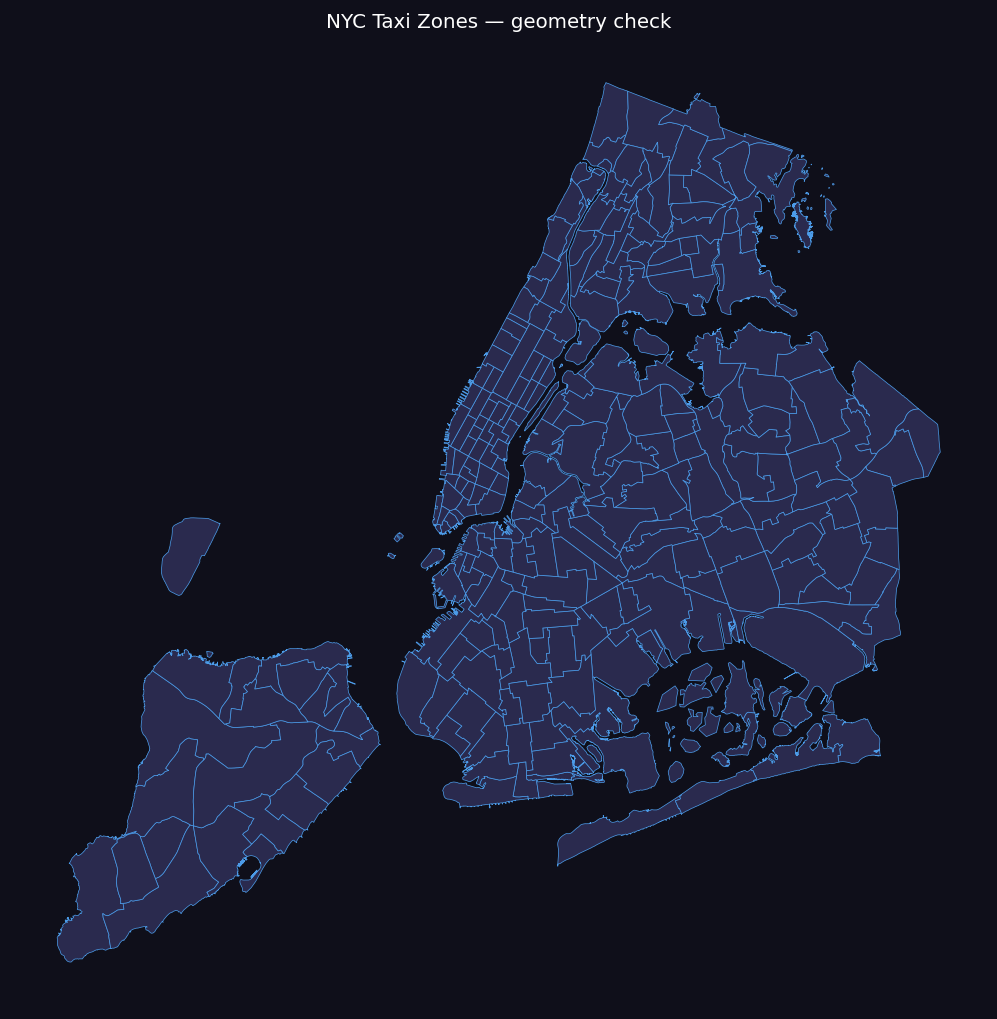

In [ ]:
# ── Fix CRS ───────────────────────────────────────────────────────────────────
print(f"Current CRS: {gdf.crs}")   # confirm it's EPSG:2263

gdf = gdf.to_crs(epsg=4326)        # reproject to WGS84 (degrees)
print(f"Reprojected to: {gdf.crs}")

# Confirm coordinates now look like lat/lon (small numbers)
print(gdf.geometry.bounds.head(2)) # minx should be around -74, miny around 40

# ── Standardise column names ──────────────────────────────────────────────────
gdf.columns = gdf.columns.str.lower().str.strip()
print(gdf.columns.tolist())
# should now be: objectid, shape_leng, shape_area, zone, locationid, borough, geometry

# ── Quick sanity plot — just the outlines before adding data ─────────────────
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#0f0f1a')
ax.set_facecolor('#1a1a2e')
gdf.plot(ax=ax, color='#2a2a4e', edgecolor='#4C9BE8', linewidth=0.4)
ax.set_axis_off()
ax.set_title('NYC Taxi Zones — geometry check', color='white', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Aggregate to one row per PULocationID before merging ─────────────────────
demand_by_location = (
    df_gold_2019
    .groupby('PULocationID', as_index=False)
    .agg(
        total_trips  = ('trip_count', 'sum'),
        avg_hourly   = ('trip_count', 'mean'),
        zone         = ('zone',         'first'),
        borough      = ('borough',       'first'),
        service_zone = ('service_zone',  'first')
    )
)

print(f"Unique PULocationIDs in demand data : {len(demand_by_location)}")
# Should be ~200–230, not millions

# ── Now merge cleanly — shapefile (263 rows) × demand (one row per location) ─
gdf_renamed = gdf.rename(columns={'locationid': 'PULocationID'})

gdf_merged = gdf_renamed.merge(demand_by_location, on='PULocationID', how='left')
gdf_merged['total_trips'] = gdf_merged['total_trips'].fillna(0)
gdf_merged['avg_hourly']  = gdf_merged['avg_hourly'].fillna(0)

print(f"gdf_merged rows : {len(gdf_merged)}")   # should be 263
matched   = gdf_merged['total_trips'].gt(0).sum()
unmatched = gdf_merged['total_trips'].eq(0).sum()
print(f"Matched         : {matched}")
print(f"Unmatched       : {unmatched}")

if unmatched > 0:
    print(gdf_merged[gdf_merged['total_trips'].eq(0)][['PULocationID','zone_x','borough_x']].to_string())

Unique PULocationIDs in demand data : 260
gdf_merged rows : 263
Matched         : 260
Unmatched       : 3
     PULocationID                                         zone_x      borough_x
0               1                                 Newark Airport            EWR
102           103  Governor's Island/Ellis Island/Liberty Island      Manhattan
109           110                               Great Kills Park  Staten Island


In [ ]:
# ── Borough-level demand summary for labels ───────────────────────────────────
borough_demand = (
    demand_by_location
    .groupby('borough', as_index=False)['total_trips']
    .sum()
)
total_all = borough_demand['total_trips'].sum()
borough_demand['pct'] = (borough_demand['total_trips'] / total_all * 100).round(1)

print(borough_demand.sort_values('total_trips', ascending=False))


         borough  total_trips   pct
2      Manhattan     74153934  92.0
3         Queens      5444419   6.8
1       Brooklyn       871925   1.1
0          Bronx       110077   0.1
4  Staten Island         2635   0.0


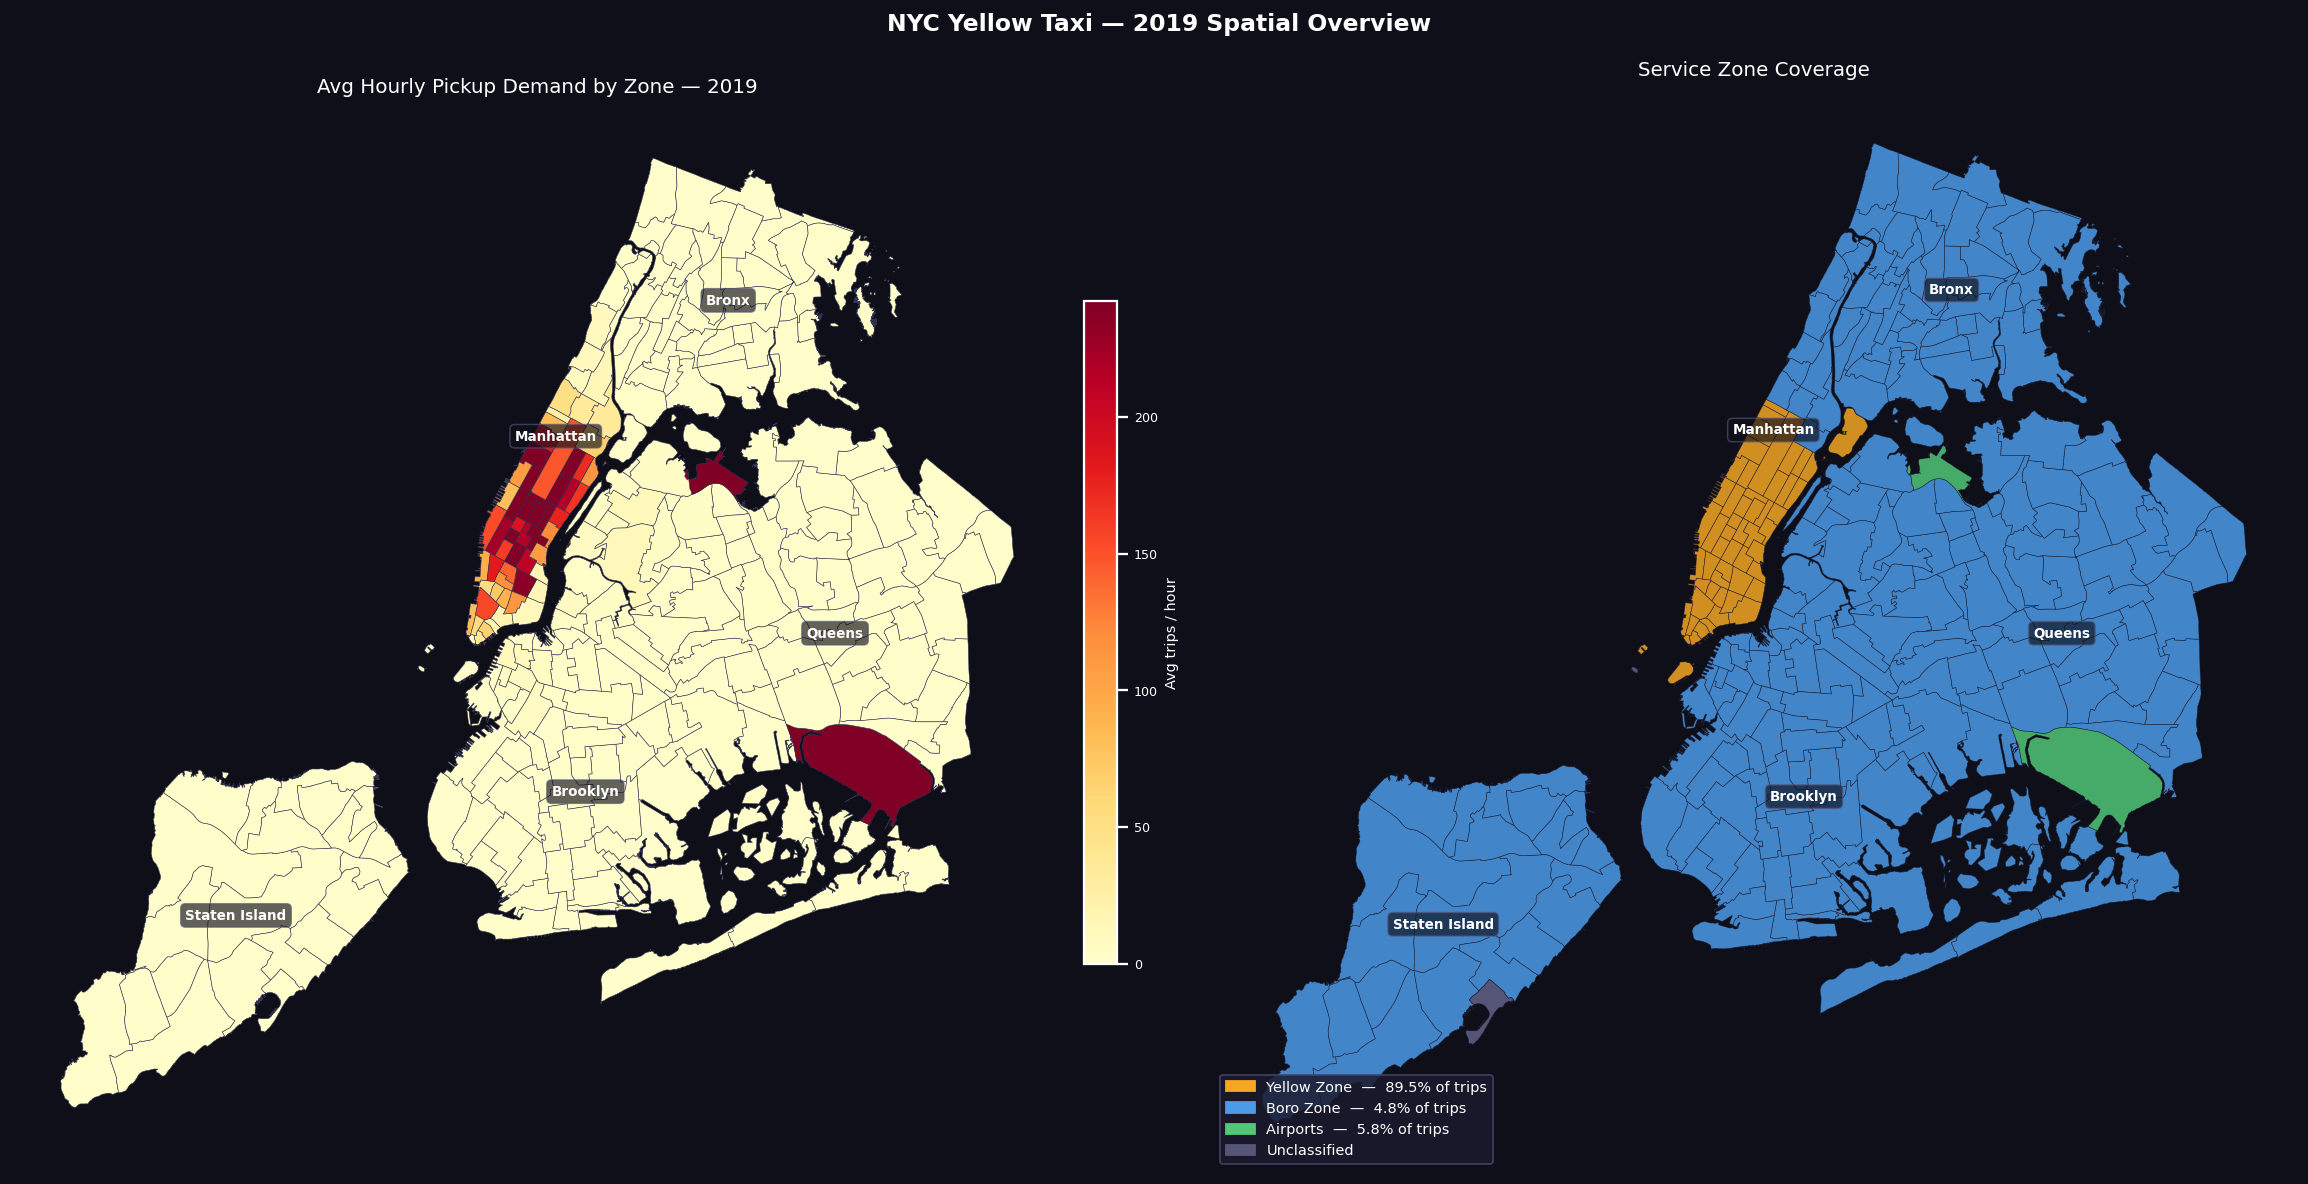

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Demand choropleth  +  Service zone coverage (with borough labels)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#0f0f1a')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.set_axis_off()

# ── Shared: borough centroids + demand labels ─────────────────────────────────
gdf_plot = gdf_merged[~gdf_merged['borough_x'].isin(['EWR', 'Unknown'])].copy()

borough_geom = (
    gdf_plot[gdf_plot['borough_x'].notna()]
    .dissolve(by='borough_x')
    .reset_index()
    .merge(borough_demand, left_on='borough_x', right_on='borough', how='left')
)
borough_geom['centroid'] = borough_geom.geometry.centroid

# Manual label nudges so text doesn't overlap zone boundaries
nudge = {
    'Manhattan':     (0.00,   0.015),
    'Brooklyn':      (0.00,  -0.01),
    'Queens':        (0.015,  0.00),
    'Bronx':         (0.00,   0.00),
    'Staten Island': (0.00,   0.00),
}

def add_borough_labels(ax, show_demand=True):
    for _, row in borough_geom.iterrows():
        if row['borough_x'] in ['EWR', 'Unknown']:
            continue
        cx = row['centroid'].x + nudge.get(row['borough_x'], (0, 0))[0]
        cy = row['centroid'].y + nudge.get(row['borough_x'], (0, 0))[1]

        if show_demand and pd.notna(row.get('total_trips')):
            trips_fmt = f"{int(row['total_trips']):,}"
            pct_fmt   = f"{row['pct']:.1f}%"
            label     = f"{row['borough_x']}\n{trips_fmt} trips\n{pct_fmt}"
        else:
            label = row['borough_x']

        ax.text(
            cx, cy, label,
            fontsize    = 7.5,
            fontweight  = 'bold',
            color       = 'white',
            ha          = 'center',
            va          = 'center',
            linespacing = 1.5,
            bbox        = dict(
                boxstyle    = 'round,pad=0.35',
                facecolor   = '#0f0f1a',
                alpha       = 0.65,
                edgecolor   = '#555577',
                linewidth   = 0.8
            )
        )

# ── Panel A: demand choropleth ────────────────────────────────────────────────
ax = axes[0]

vmax = gdf_plot['avg_hourly'].quantile(0.95)

gdf_plot.plot(
    column      = 'avg_hourly',
    ax          = ax,
    cmap        = 'YlOrRd',
    vmin        = 0,
    vmax        = vmax,
    linewidth   = 0.3,
    edgecolor   = '#333355',
    legend      = False,
    missing_kwds= {'color': '#2a2a3e'}
)

# Colourbar
sm = plt.cm.ScalarMappable(cmap='YlOrRd',
                            norm=plt.Normalize(vmin=0, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.65)
cbar.set_label('Avg trips / hour', color='white', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

add_borough_labels(ax, show_demand=True)

ax.set_title('Avg Hourly Pickup Demand by Zone — 2019',
             color='white', fontsize=11, pad=10)

# ── Panel B: service zone coverage ───────────────────────────────────────────
ax = axes[1]

service_colours = {
    'Yellow Zone' : '#F5A623',
    'Boro Zone'   : '#4C9BE8',
    'Airports'    : '#50C878',
}

for sz, colour in service_colours.items():
    subset = gdf_plot[gdf_plot['service_zone'] == sz]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=0.3,
                    edgecolor='#1a1a2e', alpha=0.85)

# Zones with no service_zone mapping
gdf_plot[gdf_plot['service_zone'].isna()].plot(
    ax=ax, color='#555577', linewidth=0.3, edgecolor='#1a1a2e'
)

# Service zone trip share in legend
service_share = (
    demand_by_location
    .groupby('service_zone')['total_trips']
    .sum()
    .reset_index()
)
service_share['pct'] = (service_share['total_trips'] / total_all * 100).round(1)
sz_pct = dict(zip(service_share['service_zone'], service_share['pct']))

legend_patches = [
    mpatches.Patch(
        color   = c,
        label   = f"{sz}  —  {sz_pct.get(sz, 0):.1f}% of trips"
    )
    for sz, c in service_colours.items()
]
legend_patches.append(
    mpatches.Patch(color='#555577', label='Unclassified')
)
ax.legend(
    handles     = legend_patches,
    loc         = 'lower left',
    facecolor   = '#1a1a2e',
    edgecolor   = '#444466',
    labelcolor  = 'white',
    fontsize     = 8,
    framealpha  = 0.85
)

# Borough labels — name only on service zone map (no trip counts, avoids clutter)
add_borough_labels(ax, show_demand=False)

ax.set_title('Service Zone Coverage', color='white', fontsize=11, pad=10)

plt.suptitle(
    'NYC Yellow Taxi — 2019 Spatial Overview',
    color='white', fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'spatial_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [ ]:
# ── Top / bottom zones ────────────────────────────────────────────────────────
ranked  = demand_by_location[demand_by_location['avg_hourly'] >= 5].sort_values(
    'avg_hourly', ascending=False
)
top3    = ranked.head(3)['zone'].tolist()
bottom3 = ranked.tail(3)['zone'].tolist()
print("Top 3   :", top3)
print("Bottom 3:", bottom3)

Top 3   : ['Upper East Side South', 'Midtown Center', 'Upper East Side North']
Bottom 3: ['Battery Park', 'Cobble Hill', 'DUMBO/Vinegar Hill']


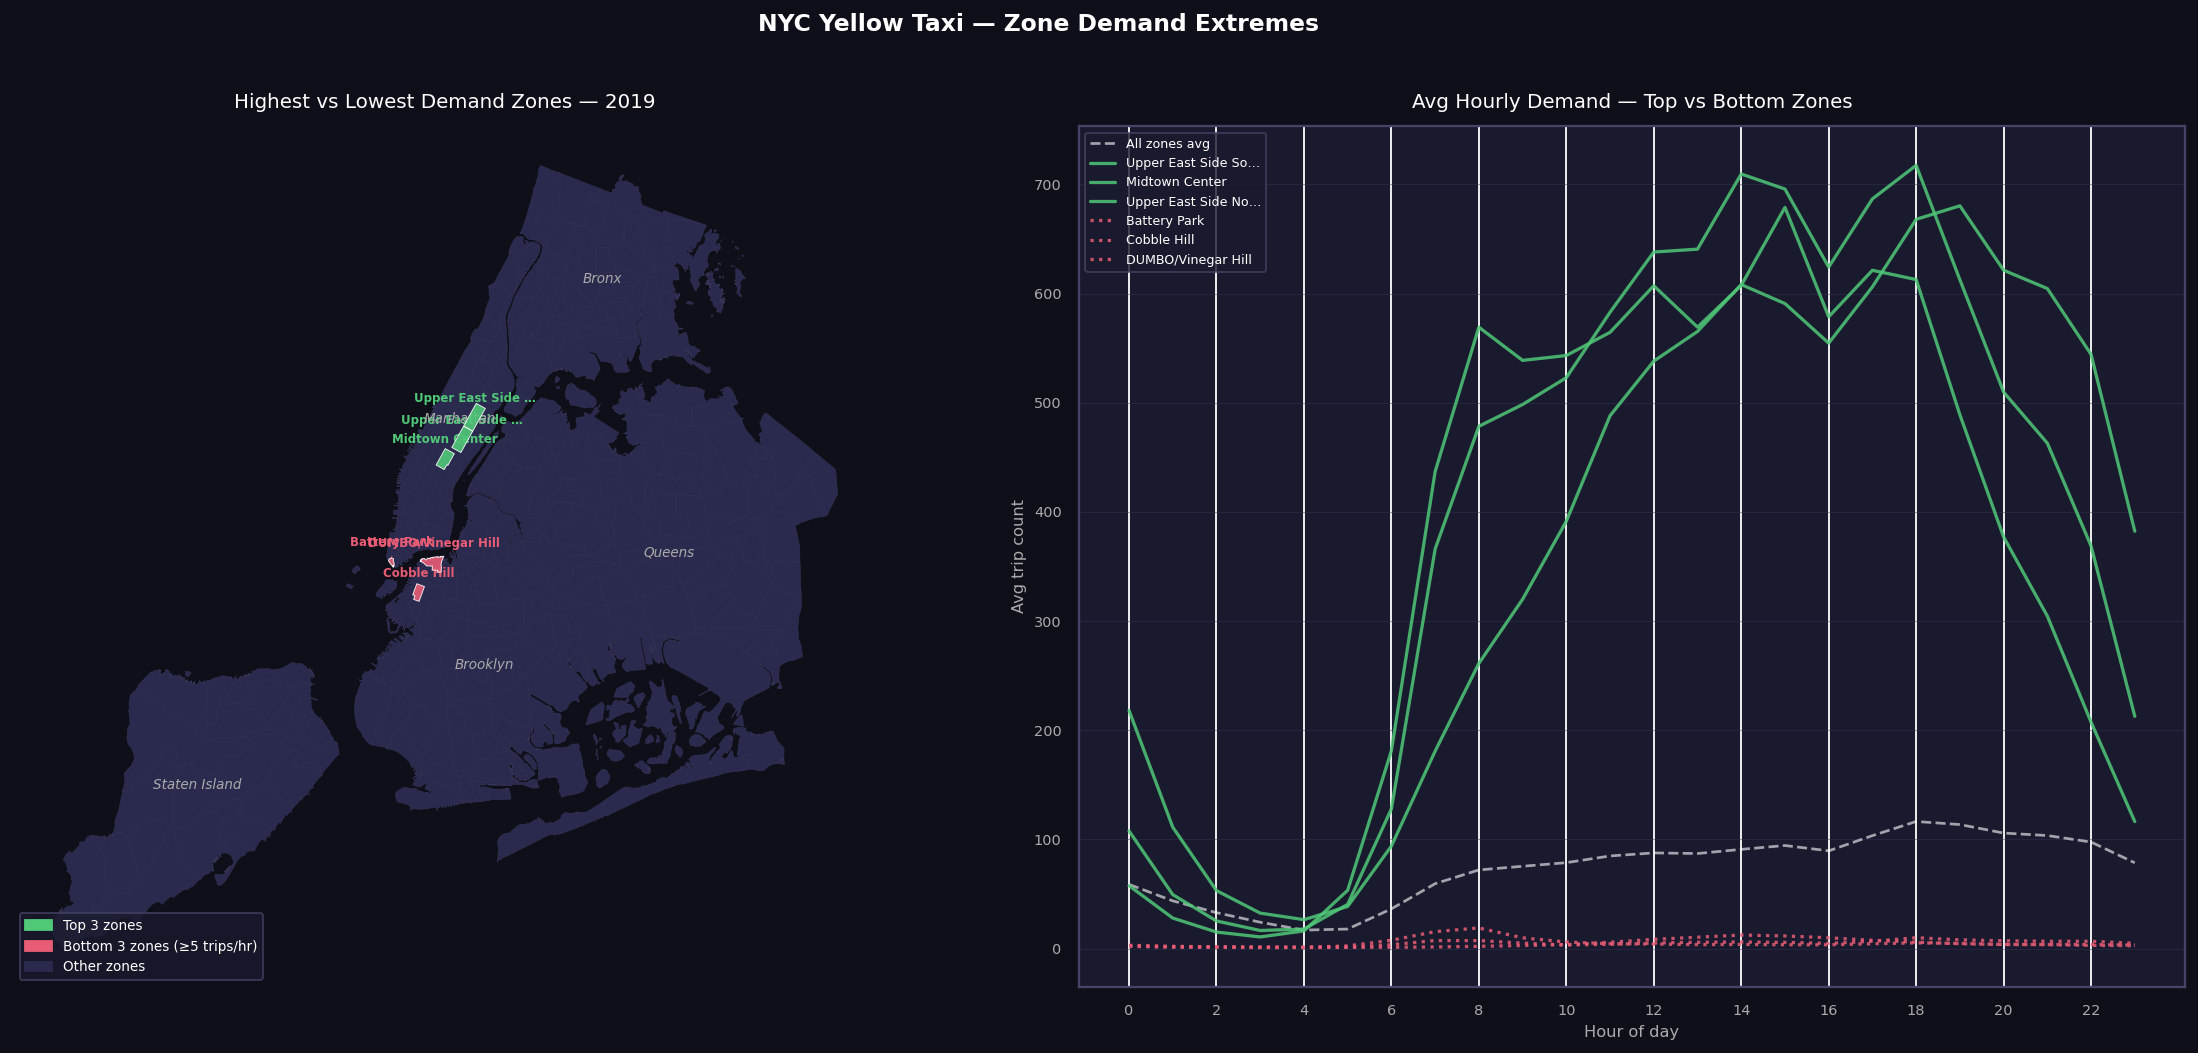

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Top 3 / Bottom 3 zones  +  hourly demand line chart
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0f0f1a')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

# ── Panel A: map highlighting top / bottom zones ─────────────────────────────
ax = axes[0]
ax.set_axis_off()

# Base layer — all zones in muted grey
gdf_plot.plot(ax=ax, color='#2a2a4e', linewidth=0.3, edgecolor='#333355')

# Top 3 — filled green
gdf_plot[gdf_plot['zone_y'].isin(top3)].plot(
    ax=ax, color='#50C878', linewidth=0.5,
    edgecolor='white', alpha=0.9, zorder=4
)

# Bottom 3 — filled red
gdf_plot[gdf_plot['zone_y'].isin(bottom3)].plot(
    ax=ax, color='#E85D75', linewidth=0.5,
    edgecolor='white', alpha=0.9, zorder=4
)

# Zone name annotations
for zone in top3 + bottom3:
    row = gdf_plot[gdf_plot['zone_y'] == zone]
    if row.empty:
        continue
    cx = row.geometry.centroid.x.values[0]
    cy = row.geometry.centroid.y.values[0]
    colour = '#50C878' if zone in top3 else '#E85D75'
    # Shorten long zone names for readability
    label = zone if len(zone) <= 18 else zone[:16] + '…'
    ax.annotate(
        label, xy=(cx, cy),
        fontsize=6.5, color=colour, fontweight='bold',
        ha='center', va='bottom',
        xytext=(0, 7), textcoords='offset points',
        arrowprops=dict(arrowstyle='-', color=colour, lw=0.8)
    )

# Borough labels
for _, row in borough_geom.iterrows():
    ax.text(row.geometry.centroid.x, row.geometry.centroid.y,
            row['borough_x'], fontsize=7.5, color='#aaaaaa',
            ha='center', style='italic')

# Legend
legend_elements = [
    mpatches.Patch(color='#50C878', label=f'Top 3 zones'),
    mpatches.Patch(color='#E85D75', label=f'Bottom 3 zones (≥5 trips/hr)'),
    mpatches.Patch(color='#2a2a4e', label='Other zones'),
]
ax.legend(handles=legend_elements, loc='lower left',
          facecolor='#1a1a2e', edgecolor='#444466',
          labelcolor='white', fontsize=7.5)

ax.set_title('Highest vs Lowest Demand Zones — 2019',
             color='white', fontsize=11, pad=10)

# ── Panel B: hourly demand line — top 3 vs bottom 3 vs overall ───────────────
ax = axes[1]

hourly_overall = (
    df_zone_2019.groupby('hour_of_day')['trip_count']
    .mean().reset_index(name='avg_trips')
)

ax.plot(hourly_overall['hour_of_day'], hourly_overall['avg_trips'],
        color='white', linewidth=1.5, linestyle='--',
        label='All zones avg', alpha=0.6)

# One line per top zone
for zone in top3:
    h = (df_zone_2019[df_zone_2019['zone'] == zone]
         .groupby('hour_of_day')['trip_count'].mean().reset_index())
    ax.plot(h['hour_of_day'], h['trip_count'],
            color='#50C878', linewidth=1.8,
            label=zone if len(zone) <= 20 else zone[:18] + '…',
            alpha=0.85)

# One line per bottom zone
for zone in bottom3:
    h = (df_zone_2019[df_zone_2019['zone'] == zone]
         .groupby('hour_of_day')['trip_count'].mean().reset_index())
    ax.plot(h['hour_of_day'], h['trip_count'],
            color='#E85D75', linewidth=1.8, linestyle=':',
            label=zone if len(zone) <= 20 else zone[:18] + '…',
            alpha=0.85)

ax.set_title('Avg Hourly Demand — Top vs Bottom Zones',
             color='white', fontsize=11, pad=10)
ax.set_xlabel('Hour of day', color='#aaaaaa', fontsize=9)
ax.set_ylabel('Avg trip count', color='#aaaaaa', fontsize=9)
ax.tick_params(colors='#aaaaaa', labelsize=8)
ax.set_xticks(range(0, 24, 2))
ax.legend(facecolor='#1a1a2e', edgecolor='#444466',
          labelcolor='white', fontsize=7, loc='upper left')
ax.grid(axis='y', color='#333355', linewidth=0.5, alpha=0.5)

plt.suptitle('NYC Yellow Taxi — Zone Demand Extremes',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'zone_extremes.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP — derived columns needed across all four charts
# ══════════════════════════════════════════════════════════════════════════════
df = df_zone_2019.copy()
df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
df['hour_of_day']    = df['pickup_hour_ts'].dt.hour
df['month_of_year']  = df['pickup_hour_ts'].dt.month
df['season']         = df['month_of_year'].map(season_map)

# Log1p applied before correlation — handles zero-inflation in both columns
df['log1p_snowfall']      = np.log1p(df['snowfall'])
df['log1p_precipitation'] = np.log1p(df['precipitation'])

# Season mapping
season_map = {
    12: 'Winter', 1: 'Winter',  2: 'Winter',
     3: 'Spring', 4: 'Spring',  5: 'Spring',
     6: 'Summer', 7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
season_colours = {
    'Winter': '#4C9BE8',
    'Spring': '#50C878',
    'Summer': '#F5A623',
    'Autumn': '#E85D75',
}
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

df['season'] = df['month_of_year'].map(season_map)

### Section 6.2: Temporal Demands and Feature Correlations

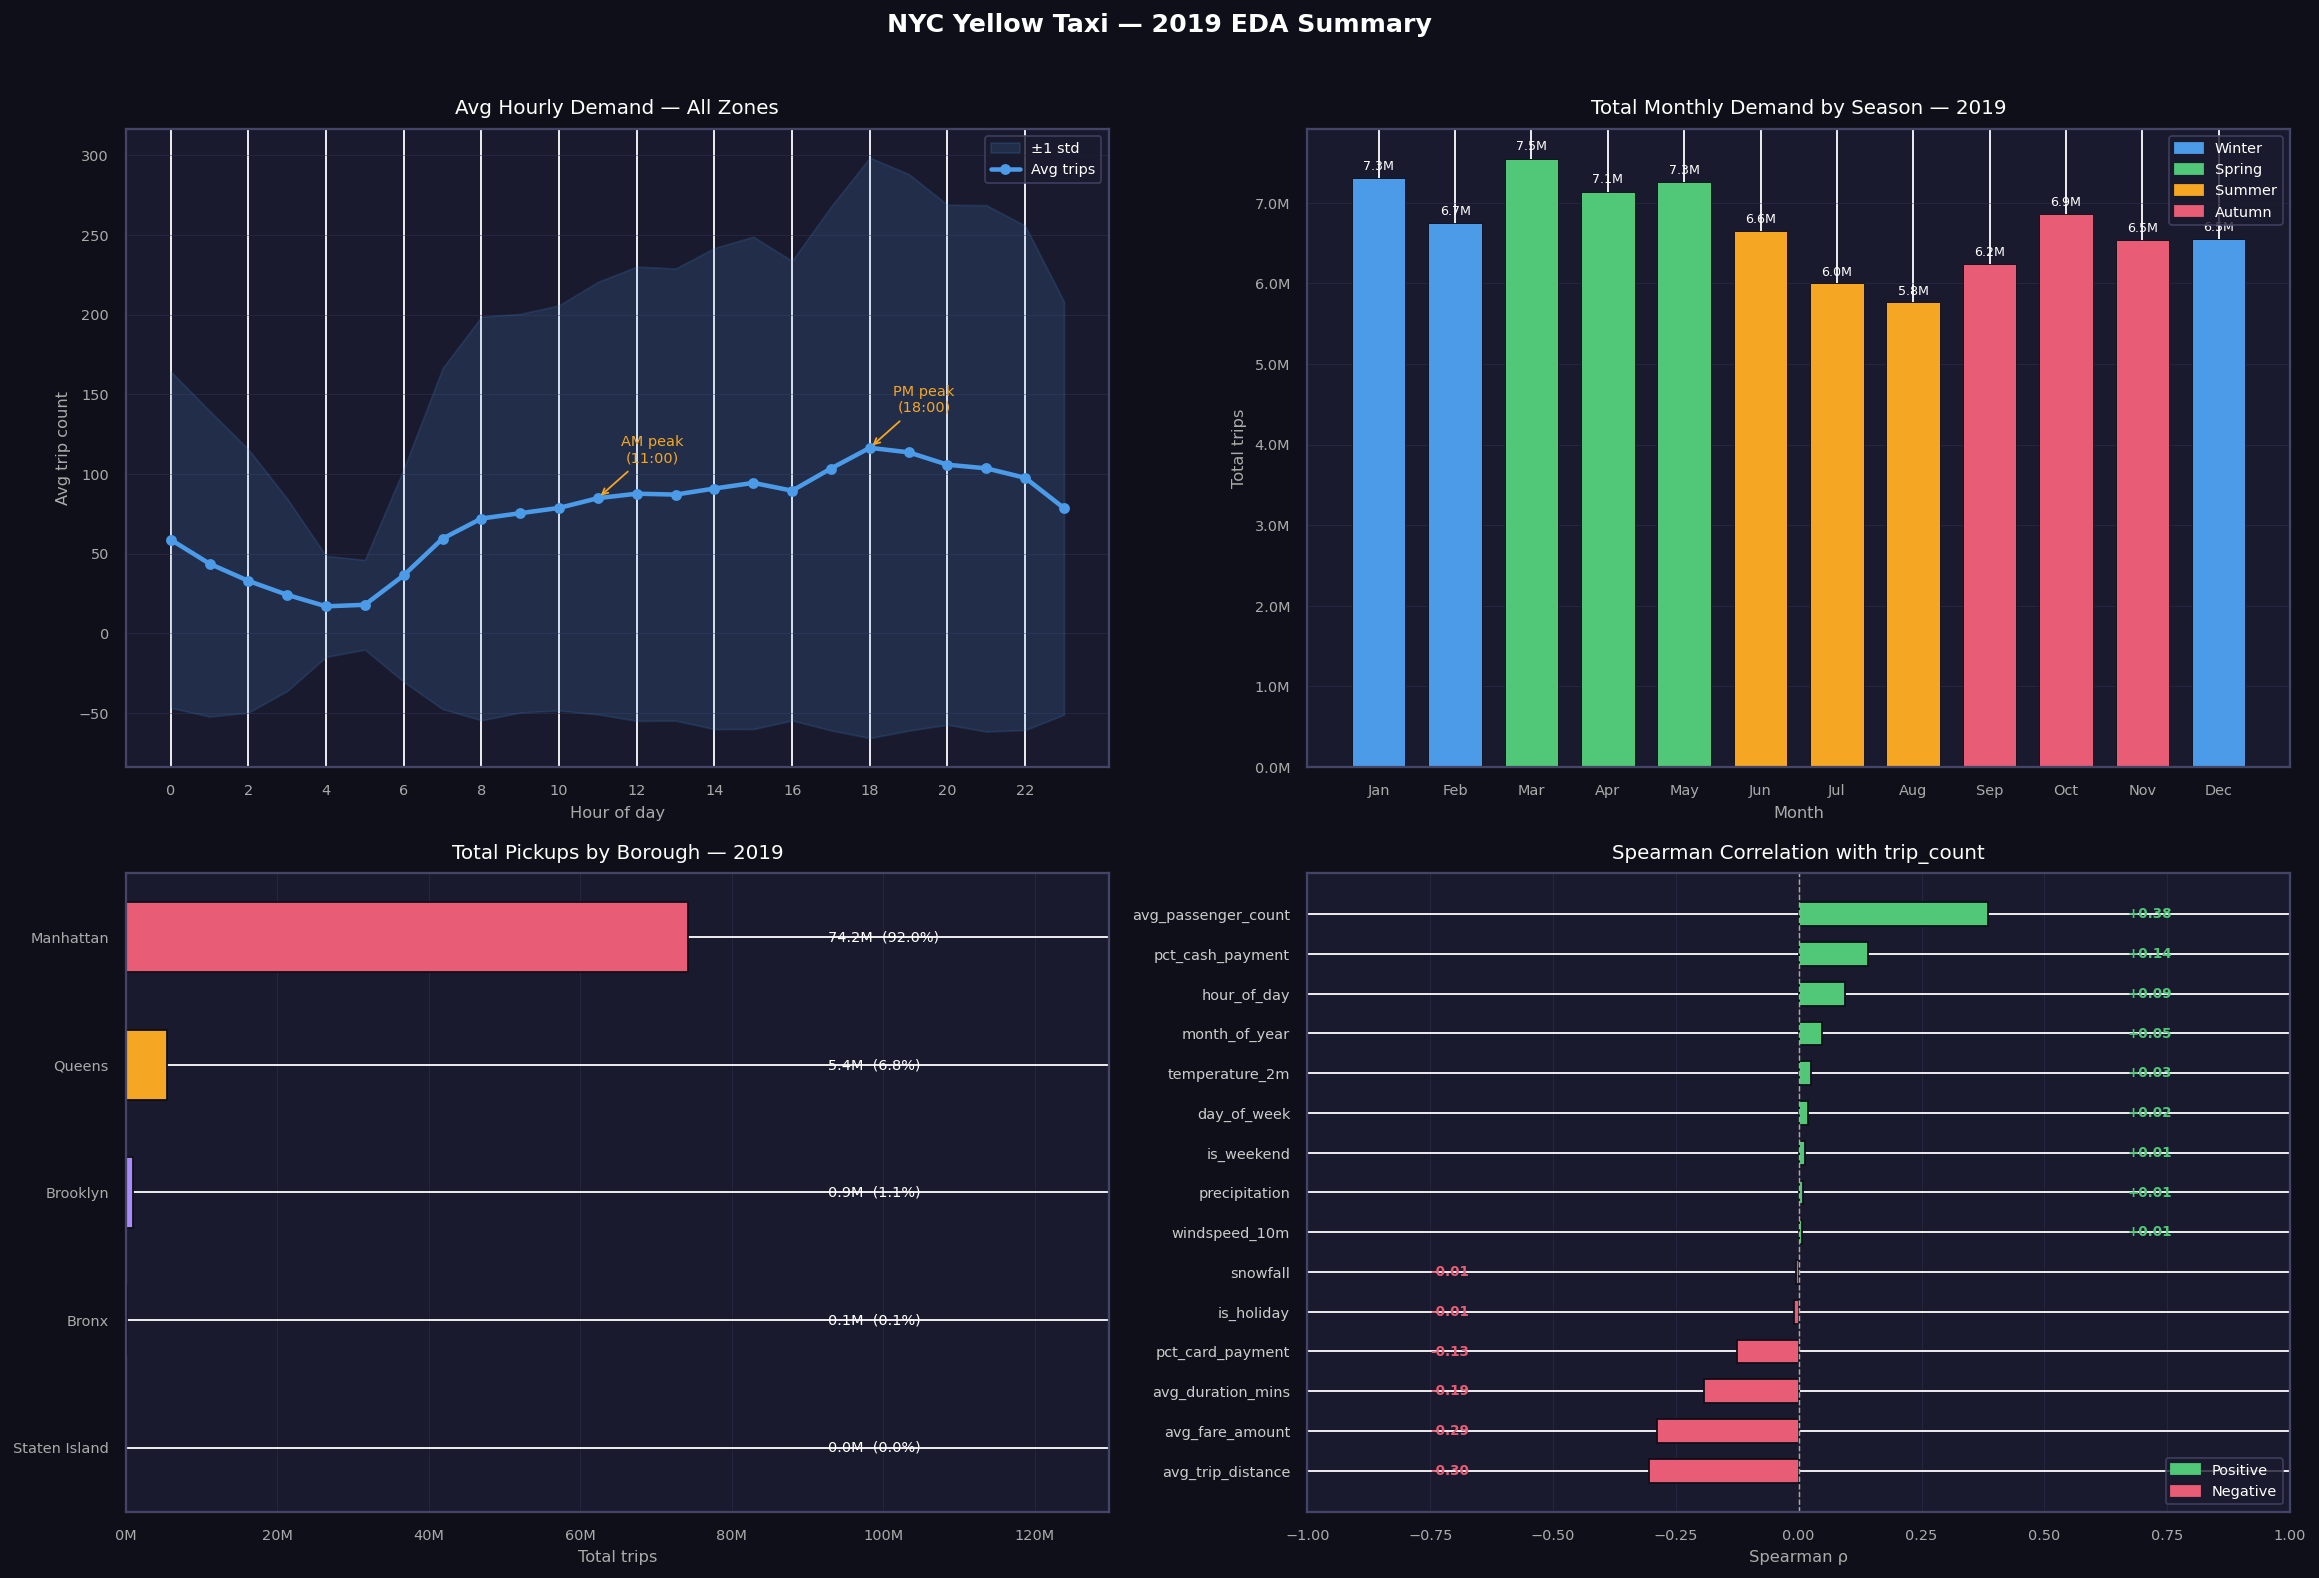

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ── 2 × 2 FIGURE ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#0f0f1a')

for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    ax.xaxis.label.set_color('#aaaaaa')
    ax.yaxis.label.set_color('#aaaaaa')

ax_hourly  = axes[0, 0]
ax_monthly = axes[0, 1]
ax_bar     = axes[1, 0]
ax_corr    = axes[1, 1]


# ── Chart 1: Hourly demand ────────────────────────────────────────────────────
hourly = (
    df.groupby('hour_of_day')['trip_count']
    .agg(['mean', 'std'])
    .reset_index()
)

ax_hourly.fill_between(
    hourly['hour_of_day'],
    hourly['mean'] - hourly['std'],
    hourly['mean'] + hourly['std'],
    alpha=0.15, color='#4C9BE8', label='±1 std'
)
ax_hourly.plot(
    hourly['hour_of_day'], hourly['mean'],
    color='#4C9BE8', linewidth=2.5, marker='o',
    markersize=5, zorder=3, label='Avg trips'
)

for peak_label, window in [('AM peak', (6, 11)), ('PM peak', (16, 20))]:
    window_data = hourly[hourly['hour_of_day'].between(*window)]
    peak_h      = window_data.loc[window_data['mean'].idxmax()]
    ax_hourly.annotate(
        f"{peak_label}\n({int(peak_h['hour_of_day'])}:00)",
        xy         = (peak_h['hour_of_day'], peak_h['mean']),
        xytext     = (30, 20),
        textcoords = 'offset points',
        color      = '#F5A623',
        fontsize   = 8,
        ha         = 'center',
        arrowprops = dict(arrowstyle='->', color='#F5A623', lw=1)
    )

ax_hourly.set_title('Avg Hourly Demand — All Zones', color='white', fontsize=11, pad=8)
ax_hourly.set_xlabel('Hour of day')
ax_hourly.set_ylabel('Avg trip count')
ax_hourly.set_xticks(range(0, 24, 2))
ax_hourly.legend(facecolor='#1a1a2e', edgecolor='#444466', labelcolor='white', fontsize=8)
ax_hourly.grid(axis='y', color='#333355', linewidth=0.5, alpha=0.5)


# ── Chart 2: Monthly demand with seasonal colouring ──────────────────────────
monthly = (
    df.groupby('month_of_year', as_index=False)['trip_count']
    .sum()
)
monthly['season'] = monthly['month_of_year'].map(season_map)
monthly['colour'] = monthly['season'].map(season_colours)

bars = ax_monthly.bar(
    monthly['month_of_year'],
    monthly['trip_count'],
    color=monthly['colour'],
    edgecolor='#0f0f1a',
    linewidth=0.5,
    width=0.7
)

for bar, val in zip(bars, monthly['trip_count']):
    ax_monthly.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val/1e6:.1f}M",
        ha='center', va='bottom',
        color='white', fontsize=7
    )

season_patches = [
    mpatches.Patch(color=c, label=s)
    for s, c in season_colours.items()
]
ax_monthly.legend(
    handles=season_patches, loc='upper right',
    facecolor='#1a1a2e', edgecolor='#444466',
    labelcolor='white', fontsize=8
)
ax_monthly.set_title('Total Monthly Demand by Season — 2019', color='white', fontsize=11, pad=8)
ax_monthly.set_xlabel('Month')
ax_monthly.set_ylabel('Total trips')
ax_monthly.set_xticks(range(1, 13))
ax_monthly.set_xticklabels(month_labels)
ax_monthly.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
ax_monthly.grid(axis='y', color='#333355', linewidth=0.5, alpha=0.5)


# ── Chart 3: Borough bar chart ────────────────────────────────────────────────
hbars = ax_bar.barh(
    borough_demand['borough'],
    borough_demand['total'],
    color     = bar_colours[:len(borough_demand)],
    edgecolor = '#0f0f1a',
    height    = 0.55
)

max_val = borough_demand['total'].max()
label_x = max_val * 1.25   # fixed column, clear of all bar ends

for bar, row in zip(hbars, borough_demand.itertuples()):
    ax_bar.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{row.total/1e6:.1f}M  ({row.pct}%)",
        va='center', ha='left',
        color='white', fontsize=8
    )

ax_bar.set_title('Total Pickups by Borough — 2019', color='white', fontsize=11, pad=8)
ax_bar.set_xlabel('Total trips')
ax_bar.set_xlim(right=max_val * 1.75)
ax_bar.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)
ax_bar.grid(axis='x', color='#333355', linewidth=0.5, alpha=0.5)


# ── Chart 4: Correlation ──────────────────────────────────────────────────────
ax_corr.barh(
    range(len(corr_vals)),
    corr_vals.values,
    color     = colours,
    edgecolor = '#0f0f1a',
    height    = 0.6
)

ax_corr.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')

ax_corr.set_yticks(range(len(corr_vals)))
ax_corr.set_yticklabels(corr_vals.index, fontsize=8, color='#cccccc')

for i, val in enumerate(corr_vals.values):
    x_pos = 0.67  if val >= 0 else -0.67
    ha    = 'left' if val >= 0 else 'right'
    ax_corr.text(
        x_pos, i,
        f'{val:+.2f}',
        va='center', ha=ha,
        color='#50C878' if val >= 0 else '#E85D75',
        fontsize=7.5, fontweight='bold'
    )

ax_corr.set_title('Spearman Correlation with trip_count', color='white', fontsize=11, pad=8)
ax_corr.set_xlabel('Spearman ρ')
ax_corr.set_xlim(-1.0, 1.0)
ax_corr.grid(axis='x', color='#333355', linewidth=0.5, alpha=0.5)

pos_patch = mpatches.Patch(color='#50C878', label='Positive')
neg_patch = mpatches.Patch(color='#E85D75', label='Negative')
ax_corr.legend(
    handles=[pos_patch, neg_patch],
    facecolor='#1a1a2e', edgecolor='#444466',
    labelcolor='white', fontsize=8, loc='lower right'
)


plt.suptitle('NYC Yellow Taxi — 2019 EDA Summary',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_summary.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [ ]:
# What percentage and trip counts are in each borough?

# Prepare statistics
# borough_counts = df_zone_2019.groupby('borough')['trip_count'].sum()
# borough_pct = (borough_counts / borough_counts.sum()) * 100,

# # COmbine results and display table
# borough_counts = pd.concat(borough_counts,borough_pct)
# borough_stats.columns = ['trip_count', 'pct_of_total']
# borough_stats.sort_values('trip_count', ascending=False, inplace=True)

# display(borough_stats)

TypeError: concat() takes 1 positional argument but 2 were given

### Section 6.3: Choice of filtering for baseline modelling

In [ ]:
# Overall model

# Filter for only boroughs Manhattan, Queens and Brooklyn
df_2019_top3_boroughs = df_zone_2019[df_zone_2019['borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

In [ ]:
# Prepare Yellow Zone and Airport Zone Data

# Yellow Zones
# df_2019_yellow_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Yellow Zone']

# # Airport Zones
# df_2019_airport_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Airports']

# # Boro Zone
# df_2019_boro_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Boro Zone']

# Prepare data
# df_2019_yz_tc_totals_by_zone = df_2019_yellow_zones.groupby("zone")["trip_count"].sum().sort_values()
# df_2019_air_tc_totals_by_zone = df_2019_airport_zones.groupby("zone")["trip_count"].sum().sort_values()
# df_2019_bz_tc_totals_by_zone = df_2019_boro_zones.groupby("zone")["trip_count"].sum().sort_values()

#### Top 3 Borough Analysis

In [ ]:
zone_totals = df_2019_top3_boroughs.groupby("zone")["trip_count"].sum().sort_values().copy()

# ── Summary stats ─────────────────────────────────────────────────────────────
stats = zone_totals.describe(percentiles=[0.25, 0.5, 0.75])
print("=== Summary Stats ===")
print(stats.round(1))

# ── Top 5 / Bottom 5 ─────────────────────────────────────────────────────────
print("\n=== Top 5 Zones ===")
print(zone_totals.tail(5).to_frame("total_trips"))

print("\n=== Bottom 5 Zones ===")
print(zone_totals.head(5).to_frame("total_trips"))

=== Summary Stats ===
count        196.0
mean      410562.6
std       801184.4
min           29.0
25%         1975.0
50%        10061.5
75%       306803.0
max      3545217.0
Name: trip_count, dtype: float64

=== Top 5 Zones ===
                              total_trips
zone                                     
Penn Station/Madison Sq West      2928411
Midtown East                      2960774
Upper East Side North             3206436
Midtown Center                    3350454
Upper East Side South             3545217

=== Bottom 5 Zones ===
                                               total_trips
zone                                                      
Broad Channel                                           29
Breezy Point/Fort Tilden/Riis Beach                     63
Jamaica Bay                                             84
Governor's Island/Ellis Island/Liberty Island          112
Green-Wood Cemetery                                    140


In [ ]:
# # ── Plots ─────────────────────────────────────────────────────────────────────
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# # Boxplot
# ax1.set_facecolor("white")
# ax1.boxplot(zone_totals, vert=True, patch_artist=True,
#             boxprops=dict(facecolor="#AEC6FF"),
#             medianprops=dict(color="red", linewidth=2),
#             whiskerprops=dict(color="navy"),
#             capprops=dict(color="navy"),
#             flierprops=dict(marker="o", markerfacecolor="steelblue",
#                             markeredgecolor="white", markersize=4, alpha=0.6))
# ax1.set_ylim(0, 150_000)
# ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
# ax1.set_ylabel("Total Annual Trips")
# ax1.set_title("Trip Count Distribution by Zone")
# ax1.set_xticks([])

# q1, q3 = zone_totals.quantile(0.25), zone_totals.quantile(0.75)
# ax1.annotate(f"Q1: {q1:,.0f}", xy=(1, q1), xytext=(1.15, q1), fontsize=9, color="navy")
# ax1.annotate(f"Q3: {q3:,.0f}", xy=(1, q3), xytext=(1.15, q3), fontsize=9, color="navy")

# q1, q3 = zone_totals.quantile(0.25), zone_totals.quantile(0.75)
# ax1.annotate(f"Q1: {q1:,.0f}", xy=(1, q1), xytext=(1.15, q1), fontsize=9, color="navy")
# ax1.annotate(f"Q3: {q3:,.0f}", xy=(1, q3), xytext=(1.15, q3), fontsize=9, color="navy")

# # Scatter: cutoff vs % zones retained
# cutoffs = np.linspace(zone_totals.min(), zone_totals.quantile(0.90), 200)
# pct_retained = [(zone_totals >= c).mean() * 100 for c in cutoffs]

# ax2.plot(cutoffs, pct_retained, color="#4C6EF5", linewidth=2)
# ax2.scatter(cutoffs, pct_retained, s=8, color="#4C6EF5", alpha=0.5)

# # Mark Q1 and median on the scatter
# for val, label, col in [(q1, "Q1", "green"), (zone_totals.median(), "Median", "red")]:
#     pct = (zone_totals >= val).mean() * 100
#     ax2.axvline(val, color=col, linestyle="--", linewidth=1.3, label=f"{label} ({val:,.0f}) → {pct:.0f}% retained")

# ax2.set_xlabel("Trip Count Cutoff")
# ax2.set_ylabel("% Zones Retained")
# ax2.set_title("Cutoff vs % Zones Retained")
# ax2.legend(fontsize=8)
# ax2.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig("boro_zones_trip_analysis.png", dpi=130, bbox_inches="tight")
# plt.show()

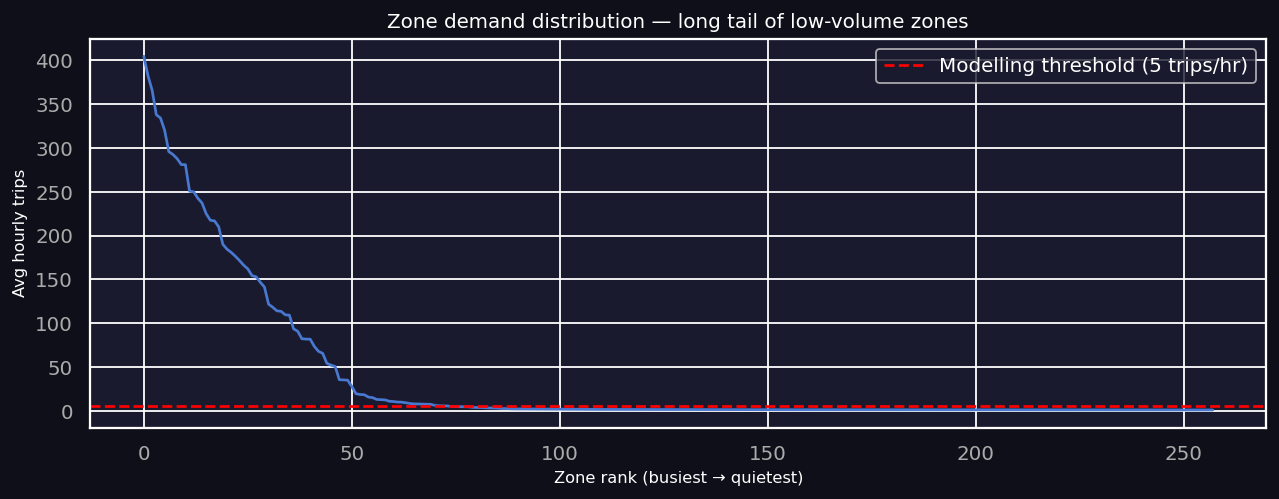

Zones above threshold : 74 / 258
These zones account for: 98.9% of all trips


In [ ]:
# Identify which zones are worth modelling
zone_avg = (
    df_zone_2019.groupby('zone')['trip_count']
    .mean()
    .reset_index()
    .rename(columns={'trip_count': 'avg_hourly_trips'})
    .sort_values('avg_hourly_trips', ascending=False)
)

# # This plot justifies zone filtering decision i
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(zone_avg)), zone_avg['avg_hourly_trips'].values)
ax.axhline(y=5, color='red', linestyle='--', label='Modelling threshold (5 trips/hr)')
ax.set_xlabel('Zone rank (busiest → quietest)')
ax.set_ylabel('Avg hourly trips')
ax.set_title('Zone demand distribution — long tail of low-volume zones')
ax.legend()
plt.tight_layout()
plt.show()

high_volume_zones = zone_avg[zone_avg['avg_hourly_trips'] >= 5]['zone'].tolist()
print(f"Zones above threshold : {len(high_volume_zones)} / {len(zone_avg)}")
print(f"These zones account for: "
      f"{df_zone[df_zone['zone'].isin(high_volume_zones)]['trip_count'].sum() / df_zone['trip_count'].sum() * 100:.1f}% of all trips")

In [ ]:
high_volume_zones = zone_avg[zone_avg['avg_hourly_trips'] >= 5]['zone'].tolist()
print(f"Zones above threshold : {len(high_volume_zones)} / {len(zone_avg)}")
print(f"These zones account for: "
      f"{df_zone_2019[df_zone_2019['zone'].isin(high_volume_zones)]['trip_count'].sum() / df_zone_2019['trip_count'].sum() * 100:.1f}% of all trips")

Zones above threshold : 74 / 258
These zones account for: 98.9% of all trips


In [ ]:
# Show service zone breakdown — one bar chart for the presentation
service_zone_summary = (
    df_zone_2019.groupby('service_zone')['trip_count']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_trips', 'mean': 'avg_hourly', 'count': 'zone_hours'})
    .sort_values('total_trips', ascending=False)
)
display(service_zone_summary)

,total_trips,avg_hourly,zone_hours
service_zone,,,
Yellow Zone,72083877,161.451094,446475
Airports,4651087,272.232192,17085
Boro Zone,3848026,6.422186,599177


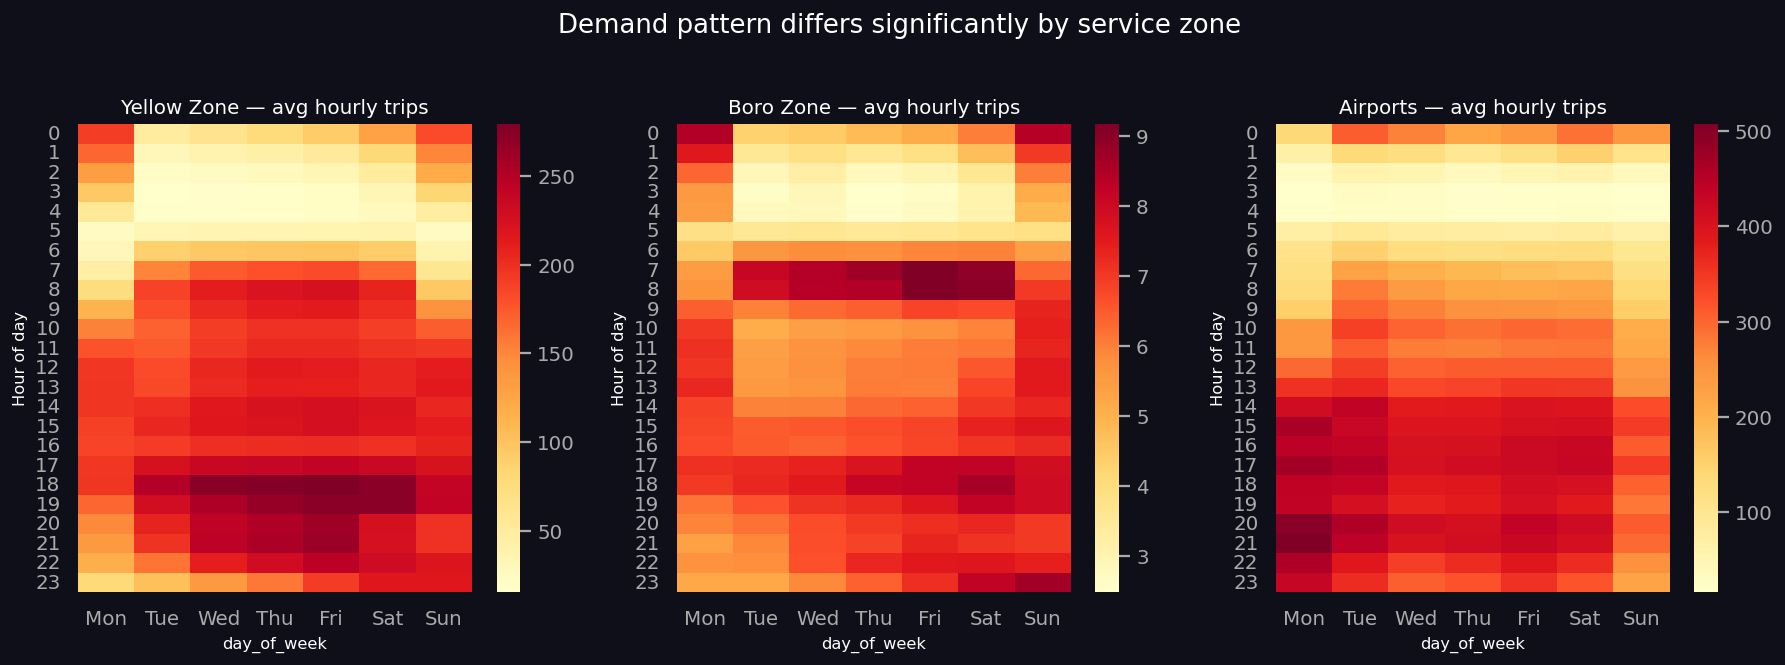

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, sz in zip(axes, ['Yellow Zone', 'Boro Zone','Airports']):
    pivot = (
        df_zone_2019[df_zone_2019['service_zone'] == sz]
        .groupby(['hour_of_day', 'day_of_week'])['trip_count']
        .mean()
        .unstack()
    )
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.0f',
                xticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    ax.set_title(f'{sz} — avg hourly trips')
    ax.set_ylabel('Hour of day')

plt.suptitle('Demand pattern differs significantly by service zone', y=1.02)
plt.tight_layout()
plt.show()


## Section 7: Inspect and Prepare Data for Baseline Modelling

### Build features for modelling

In [ ]:
def fill_weather_and_holiday_gaps(df, location_col, datetime_col):
    """
    Fills gaps introduced by the spine reindexing for weather, borough, and holidays.
    Only fills missing values to preserve original ingestion data.
    """

    # 1) Holidays: Recompute from timestamp for 100% coverage
    # This is safer and faster than ffilling booleans
    nyc_holidays = holidays.US(state='NY', years=[2019, 2020, 2021, 2022])
    df['is_holiday'] = df[datetime_col].dt.date.isin(nyc_holidays).astype(bool)

    # 2) Borough: Static mapping (Zone never changes Borough)
    # We find the mapping from non-NaN rows and apply it to the whole column
    if 'borough' in df.columns:
        zone_map = df.dropna(subset=['borough']).drop_duplicates(location_col)
        mapping = dict(zip(zone_map[location_col], zone_map['borough']))
        df['borough'] = df['borough'].fillna(df[location_col].map(mapping))

    # 2b) Service Zone: Static mapping (Zone never changes Service Zone)
    # We find the mapping from non-NaN rows and apply it to the whole column
    if 'service_zone' in df.columns:
        zone_map = df.dropna(subset=['service_zone']).drop_duplicates(location_col)
        mapping = dict(zip(zone_map[location_col], zone_map['service_zone']))
        df['service_zone'] = df['service_zone'].fillna(df[location_col].map(mapping))

    # 3) Weather Numerics: Global Fill (Weather is consistent across NYC)
    # We sort by time and fill globally so Zone B can use Zone A's weather for that hour
    # numeric_weather_cols = [c for c in ['temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m', 'weathercode']
    #                       if c in df.columns]

    # if numeric_weather_cols:
    #     # Sort temporarily by time to ensure a continuous temporal fill
    #     df = df.sort_values(datetime_col)
    #     for col in numeric_weather_cols:
    #         # Fill missing values using the last known value across the city
    #         df[col] = df[col].ffill().bfill(limit=24) # bfill limited to catch start of dataset
    #         # Last resort for absolute start of 2019
    #         df[col] = df[col].fillna(0.0)

    # 4) Rebuild weather flags from the filled numerics
    # if 'snowfall' in df.columns:
    #     df['is_snowing'] = df['snowfall'] > 7.62
    # if 'precipitation' in df.columns:
    #     df['is_raining'] = df['precipitation'] > 0
    # if 'snowfall' in df.columns and 'precipitation' in df.columns:
    #     df['is_extreme_weather'] = (df['snowfall'] > 7.62) | (df['precipitation'] > 25.4)

    return df

In [ ]:
def build_lag_features(df,
                       location_col='zone',
                       datetime_col='pickup_hour_ts',
                       demand_col='trip_count'):
    """
    Add lag and rolling-style time features to the gold DataFrame.

    Important:
    - Must be called on the FULL dataset so lag features can cross month boundaries.
    - Missing hours per zone are filled with 0 trips via a complete hourly spine.
    - Avoids backward-filling weather-like variables to reduce future leakage.
    """

    # Make a copy so the original dataframe is not modified in-place
    df = df.copy()

    # Save extra columns which are not grouping variables
    extra_cols = [c for c in df.columns if c not in [location_col, datetime_col, demand_col]]

    # Check for duplicate zone-hour rows before reindexing
    dup_mask = df.duplicated(subset=[location_col, datetime_col], keep=False)
    df_duplicates = df[dup_mask]

    if not df_duplicates.empty:
        print(
            f"  Warning: Found {len(df_duplicates)} duplicate rows for "
            f"{location_col} and {datetime_col}. Showing first 10:"
        )
        display(df_duplicates.head(10))
        print("  Aggregating duplicates by group...")

        # Aggregate duplicate rows into a single zone-hour record
        # Counts should sum; proportions and continuous values are averaged.
        agg_funcs = {
            'trip_count': 'sum',
            'pct_card_payment': 'mean',
            'pct_cash_payment': 'mean',
            'avg_trip_distance': 'mean',
            'avg_fare_amount': 'mean',
            'avg_duration_mins': 'mean',
            'avg_passenger_count': 'mean',
            # 'temperature_2m': 'mean',
            # 'precipitation': 'mean',
            # 'snowfall': 'mean',
            # 'windspeed_10m': 'mean',
            'is_weekend': 'max',
            'is_holiday': 'max',
            # 'is_snowing': 'max',
            # 'is_raining': 'max',
            # 'is_extreme_weather': 'max',
            'borough': 'first',
            'service_zone':'first',
            # 'weathercode': 'first',
            'file_month': 'first',
            'hour_of_day': 'first',
            'day_of_week': 'first'
        }

        # Keep only the columns that actually exist in the dataframe
        agg_funcs = {k: v for k, v in agg_funcs.items() if k in df.columns}

        df = df.groupby([location_col, datetime_col], as_index=False).agg(agg_funcs)
        print(f"  Aggregated to {len(df):,} unique rows.")

    # Build a complete hourly spine across all zones and hours
    all_hours = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='h')
    all_zones = df[location_col].unique()

    spine = pd.MultiIndex.from_product(
        [all_zones, all_hours],
        names=[location_col, datetime_col]
    )

    # Reindex onto the full zone-hour grid
    df = (
        df.set_index([location_col, datetime_col])
          .reindex(spine)
          .reset_index()
    )

    # Fill Gaps for weather and holiday fields
    # We call this BEFORE creating lags so the lags have clean data to pull from
    df = fill_weather_and_holiday_gaps(df, location_col, datetime_col)

    # Restore year if it was in the original df
    if "year" in df.columns:
        # If it was filled with NaNs by reindex, forward-fill by zone–ts
        df["year"] = df.groupby(location_col)["year"].transform("first")  # or .ffill()
    else:
        df["year"] = df[datetime_col].dt.year  # or derive from timestamp

    # Hours with no trips are true zero-demand hours
    df[demand_col] = df[demand_col].fillna(0)

    # Recreate deterministic time features from timestamp
    df['hour_of_day'] = df[datetime_col].dt.hour
    df['day_of_week'] = df[datetime_col].dt.dayofweek
    df['month_of_year'] = df[datetime_col].dt.month
    df['is_weekend'] = df[datetime_col].dt.dayofweek.isin([5, 6])

    # Sort before group-based fills and lags
    df = df.sort_values([location_col, datetime_col]).reset_index(drop=True)

    # Fill weather / holiday fields within each zone using only past values
    # Avoid bfill because it can leak future information backward in time.
    # weather_cols = [
    #     'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m',
    #     'weathercode', 'is_snowing', 'is_raining', 'is_extreme_weather',
    #     'is_holiday', 'borough','service_zone'
    # ]
    # weather_cols = [c for c in weather_cols if c in df.columns]

    # if weather_cols:
    #     df[weather_cols] = (
    #         df.groupby(location_col)[weather_cols]
    #           .transform(lambda x: x.ffill())
    #     )

    # Set zero explicitly for undefined values
    transform_cols = ['pct_card_payment', 'pct_cash_payment',
                  'avg_passenger_count', 'avg_duration_mins',
                  'avg_fare_amount', 'avg_trip_distance']

    for col in transform_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)  # Fill NaNs first
            df[col + '_lag_1h'] = df.groupby(location_col)[col].shift(1)  # Create 1h lag


    # Re-derive file_month from the timestamp so it stays consistent
    df['file_month'] = df[datetime_col].dt.to_period('M').astype(str)

    # Create lag features within each zone so values do not bleed across zones
    grp = df.groupby(location_col)[demand_col]
    df['lag_1h'] = grp.shift(1)
    df['lag_24h'] = grp.shift(24)
    df['lag_168h'] = grp.shift(168)

    print(f"  Lag features built — {len(df):,} rows (includes spine fill)")
    return df



## Section 8: Baseline Modelling

#### Train Model based on 2019 data

In [ ]:
TARGET = 'trip_count'

FEATURES = [
    'zone','borough','hour_of_day','day_of_week','month_of_year',
    'pct_cash_payment_lag_1h','avg_duration_mins_lag_1h','avg_passenger_count_lag_1h',
    'lag_1h_log','lag_24h_log','lag_168h_log',
    'is_holiday','is_weekend','is_airport'
]

categorical_cols = [
    'zone','hour_of_day','day_of_week','month_of_year',
    'is_holiday','is_weekend','is_airport','borough'
]

# Parameters for yellow zone
params = {
    'objective':'poisson',
    'metric':'mae',
    'n_estimators':1800,
    'learning_rate':0.03,
    'num_leaves':31,
    'min_child_samples':50,
    'subsample':0.8,
    'subsample_freq':1,
    'colsample_bytree':0.8,
    'reg_alpha':0.1,
    'reg_lambda':1.0,
    'random_state':42,
    'verbose':-1
}

In [ ]:
def prepare_features(df):

  """
  Prepare features prior to baseline modelling and prediction to ensure
  consistency across datasets.
  """

  df = df.copy().sort_values("pickup_hour_ts").reset_index(drop=True)

  if "month_of_year" not in df.columns:
      df["month_of_year"] = df["pickup_hour_ts"].dt.month

  # Apply astype("category") to all specified categorical_cols first.
  # This makes sure the .cat accessor is available for further processing.
  for c in categorical_cols:
      if c in df.columns:
          df[c] = df[c].astype("category")

  # Removing explicit conversion of 'borough' and 'service_zone' to .cat.codes
  # if they are not in the 'categorical_cols' list. They are not part of FEATURES for this model.

  # Debugging: Print dtypes after conversion
  print(f"DEBUG: Dtypes for specified categorical_cols after conversion:")
  for c in categorical_cols:
      if c in df.columns: print(f"  {c}: {df[c].dtype}")


  for col in ["lag_1h", "lag_24h", "lag_168h"]:
      df[f"{col}_log"] = np.log1p(df[col])

    # enforce exact feature order and presence
  missing = [c for c in FEATURES if c not in df.columns]
  if missing:
      raise ValueError(f"Missing features: {missing}")

  return df

In [ ]:
def align_for_prediction(df, training_features, categorical_cols):
  """
  Ensure the features using for testing are aligned with the training features.
  """

  X = df.copy()
  X = X.reindex(columns=training_features)

  for c in categorical_cols:
      if c in X.columns:
          X[c] = X[c].astype("category")

  return X

#### Prepare training data

In [ ]:
#### PREPARE TRAINING DATA ######

## 1. Load Gold data

# Yellow Zones
# df_2019_yellow_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Yellow Zone']
# Airport Zones
# df_2019_airport_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Airports']
# Overall model

# Filter for only boroughs Manhattan, Queens and Brooklyn
baseline_model_data = df_zone_2019[df_zone_2019['borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

# Create is_airport flag
airport_zones = [
    "JFK Airport",
    "LaGuardia Airport"
]

baseline_model_data["is_airport"] = baseline_model_data["zone"].isin(airport_zones).astype(int)


##  2. Build lag features
# df_yz_with_lag = build_lag_features(df_2019_yellow_zones).copy()
# df_az_with_lag = build_lag_features(df_2019_airport_zones).copy()
baseline_model_data_with_lag = build_lag_features(baseline_model_data).copy()

# 3. Drop first 168h per zone — these have unavoidably NaN lags
# df_yz_with_lag = df_yz_with_lag.dropna(subset=["lag_168h"]).copy()
# df_az_with_lag = df_az_with_lag.dropna(subset=["lag_168h"]).copy()
baseline_model_data_with_lag = baseline_model_data_with_lag.dropna(subset=["lag_168h"]).copy()

# 4. Prepare model data and split by year
# df_yz_model = prepare_features(df_yz_with_lag)
# df_az_model = prepare_features(df_az_with_lag)
baseline_model_data_with_prepared_feats = prepare_features(baseline_model_data_with_lag)

  Lag features built — 1,716,960 rows (includes spine fill)
DEBUG: Dtypes for specified categorical_cols after conversion:
  zone: category
  hour_of_day: category
  day_of_week: category
  month_of_year: category
  is_holiday: category
  is_weekend: category
  is_airport: category
  borough: category


In [ ]:
# df_yz_model.head()
baseline_model_data_with_prepared_feats.head()

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_passenger_count_lag_1h,avg_duration_mins_lag_1h,avg_fare_amount_lag_1h,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log
0,Alphabet City,2019-01-08,2019-01,Manhattan,Yellow Zone,7.0,3.2757,12.7857,12.5714,1.1429,...,1.4118,12.2353,12.4412,3.1647,17.0,10.0,49.0,2.890372,2.397895,3.912023
1,Kensington,2019-01-08,2019-01,Brooklyn,Boro Zone,0.0,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0,2.0,0.000000,0.000000,1.098612
2,Clinton Hill,2019-01-08,2019-01,Brooklyn,Boro Zone,1.0,3.3000,12.5000,12.0000,1.0000,...,2.6000,13.0000,12.0000,2.9580,5.0,1.0,14.0,1.791759,0.693147,2.708050
3,Jamaica,2019-01-08,2019-01,Queens,Boro Zone,0.0,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0,4.0,0.000000,0.000000,1.609438
4,Woodhaven,2019-01-08,2019-01,Queens,Boro Zone,0.0,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
# Save results
baseline_model_data_with_prepared_feats.to_parquet(PREDICT_DIR / "2019_data_with_top_3_boroughs_only.parquet", index=False)

In [ ]:
# ### 1. Basic Checks ###

# df_lagged = df_2019.copy()

# # 1) No duplicate zone-hour rows
# assert df_lagged.duplicated(subset=["zone", "pickup_hour_ts"]).sum() == 0

# # 2) Timestamps are sorted within each zone
# check_order = (
#     df_lagged.sort_values(["zone", "pickup_hour_ts"])
#              .groupby("zone")["pickup_hour_ts"]
#              .apply(lambda s: s.is_monotonic_increasing)
# )
# assert check_order.all()

# # 3) No missing lag columns
# lag_cols = ["lag_1h", "lag_24h", "lag_168h"]
# assert all(c in df_lagged.columns for c in lag_cols)

# # 4) Lag values are non-null where enough history exists
# assert df_lagged["lag_1h"].notna().sum() > 0
# assert df_lagged["lag_24h"].notna().sum() > 0
# assert df_lagged["lag_168h"].notna().sum() > 0

# ### 2. Lag alignment check ###
# zone = df_lagged["zone"].iloc[0]
# z = df_lagged[df_lagged["zone"] == zone].sort_values("pickup_hour_ts").reset_index(drop=True)

# # 1-hour lag should equal previous trip_count
# if len(z) >= 2: # Added check for sufficient data
#     actual_lag_1h = z.loc[1:, "lag_1h"].values
#     expected_trip_count_1h = z.loc[:-1, "trip_count"].values
#     assert len(actual_lag_1h) > 0, f"Expected non-empty array for lag_1h check, got empty for zone {zone}"

#     # Check if a lag exists
#     i = 10
#     assert z.loc[i, "lag_1h"] == z.loc[i-1, "trip_count"]

#     # And for daily lag
#     i = 30
#     assert z.loc[i, "lag_24h"] == z.loc[i-24, "trip_count"]
# else:
#     print(f"Skipping 1-hour lag alignment check for zone {zone} due to insufficient data ({len(z)} rows).")

# # 24-hour lag should equal trip_count 24 rows earlier
# if len(z) >= 25:
#     actual_lag_24h = z.loc[24:, "lag_24h"].values
#     expected_trip_count_24h = z.loc[:-24, "trip_count"].values
#     if len(actual_lag_24h) > 0 and len(expected_trip_count_24h) > 0: # Added conditional check
#         assert (actual_lag_24h == expected_trip_count_24h).all(), f"24-hour lag alignment failed for zone {zone}"
#     else:
#         print(f"Skipping 24-hour lag alignment check for zone {zone} due to empty sliced arrays after extraction.")

# # 168-hour lag should equal trip_count 168 rows earlier
# if len(z) >= 169:
#     actual_lag_168h = z.loc[168:, "lag_168h"].values
#     expected_trip_count_168h = z.loc[:-168, "trip_count"].values
#     if len(actual_lag_168h) > 0 and len(expected_trip_count_168h) > 0: # Added conditional check
#         assert (actual_lag_168h == expected_trip_count_168h).all(), f"168-hour lag alignment failed for zone {zone}"
#     else:
#         print(f"Skipping 168-hour lag alignment check for zone {zone} due to empty sliced arrays after extraction.")

# ### 3. Spine and zero-demand checks ###
# expected_hours = pd.date_range(
#     df_lagged["pickup_hour_ts"].min(),
#     df_lagged["pickup_hour_ts"].max(),
#     freq="h"
# )

# for zone, g in df_lagged.groupby("zone"):
#     assert len(g) == len(expected_hours)
#     assert g["pickup_hour_ts"].is_unique
#     assert g["trip_count"].ge(0).all()

# ### 4. Leakage checks ###
# # Future lag leakage should not exist
# assert (df_lagged["lag_1h"] <= df_lagged["trip_count"].max()).all()

# # No lag column should equal current trip_count for all rows
# assert not df_lagged["lag_1h"].equals(df_lagged["trip_count"])

# # and the same for weather
# weather_cols = ["temperature_2m", "precipitation", "snowfall", "windspeed_10m"]
# for c in weather_cols:
#     if c in df_lagged.columns:
#         assert df_lagged[c].notna().all()

Skipping 24-hour lag alignment check for zone Alphabet City due to empty sliced arrays after extraction.
Skipping 168-hour lag alignment check for zone Alphabet City due to empty sliced arrays after extraction.


#### Run ablation study

In [ ]:
# TARGET = 'trip_count'

# BASE_FEATURES = [
#     'zone','hour_of_day','day_of_week','month_of_year',
#     'temperature_2m','windspeed_10m','pct_cash_payment_lag_1h',
#     'avg_duration_mins_lag_1h','avg_passenger_count_lag_1h',
#     'lag_1h_log','lag_24h_log','lag_168h_log',
#     'is_holiday','is_weekend'
# ]

# BASE_CATEGORICAL = [
#     'zone','hour_of_day','day_of_week','month_of_year',
#     'is_holiday','is_weekend','borough','service_zone'
# ]

# params = {
#     'objective': 'poisson',
#     'metric': 'mae',
#     'n_estimators': 1800,
#     'learning_rate': 0.03,
#     'num_leaves': 31,
#     'min_child_samples': 50,
#     'subsample': 0.8,
#     'subsample_freq': 1,
#     'colsample_bytree': 0.8,
#     'reg_alpha': 0.1,
#     'reg_lambda': 1.0,
#     'random_state': 42,
#     'verbose': -1
# }

# folds = [
#     ('2019-01-01', '2019-07-31 23:59:59', '2019-08-01', '2019-08-31 23:59:59'),
#     ('2019-02-01', '2019-08-31 23:59:59', '2019-09-01', '2019-09-30 23:59:59'),
#     ('2019-03-01', '2019-09-30 23:59:59', '2019-10-01', '2019-10-31 23:59:59'),
#     ('2019-04-01', '2019-10-31 23:59:59', '2019-11-01', '2019-11-30 23:59:59'),
#     ('2019-05-01', '2019-11-30 23:59:59', '2019-12-01', '2019-12-31 23:59:59'),
# ]

# ablation_specs = {
#     'full': BASE_FEATURES,
#     'time_only': ['hour_of_day', 'day_of_week', 'month_of_year', 'is_holiday', 'is_weekend'],
#     'time_plus_lags': ['hour_of_day', 'day_of_week', 'month_of_year', 'is_holiday', 'is_weekend',
#                        'lag_1h_log', 'lag_24h_log', 'lag_168h_log'],
#     'no_zone': [c for c in BASE_FEATURES if c != 'zone'],
#     'no_service_zone': [c for c in BASE_FEATURES if c != 'service_zone'],
#     'no_borough': [c for c in BASE_FEATURES if c != 'borough'],
#     'no_weather': [c for c in BASE_FEATURES if c not in ['temperature_2m', 'windspeed_10m']],
#     'no_extra_lagged_features': [c for c in BASE_FEATURES if c not in [
#         'pct_cash_payment_lag_1h', 'avg_duration_mins_lag_1h', 'avg_passenger_count_lag_1h'
#     ]],
# }

# run_fold = 5
# tr_start, tr_end, va_start, va_end = folds[run_fold - 1]

# train = df_2019[(df_2019['pickup_hour_ts'] >= tr_start) & (df_2019['pickup_hour_ts'] <= tr_end)].copy()
# val = df_2019[(df_2019['pickup_hour_ts'] >= va_start) & (df_2019['pickup_hour_ts'] <= va_end)].copy()

# fold_results = []
# all_fold_preds = []
# feature_importance_frames = []

# start_time = datetime.now()

# for exp_name, feats in ablation_specs.items():
#     feats = [f for f in feats if f in df_2019.columns]
#     cat_cols = [c for c in BASE_CATEGORICAL if c in feats]

#     X_train = train[feats].copy()
#     y_train = train[TARGET].copy()
#     X_val = val[feats].copy()
#     y_val = val[TARGET].copy()

#     for col in cat_cols:
#         X_train[col] = X_train[col].astype('category')
#         X_val[col] = X_val[col].astype('category')

#     model = lgb.LGBMRegressor(**params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric='mae',
#         categorical_feature=cat_cols,
#         callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
#     )

#     preds = model.predict(X_val, num_iteration=model.best_iteration_)
#     actuals = y_val.values
#     residuals = actuals - preds
#     abs_errors = np.abs(residuals)

#     mae = mean_absolute_error(actuals, preds)
#     rmse = np.sqrt(mean_squared_error(actuals, preds))
#     total_actual = actuals.sum()
#     mean_demand = actuals.mean()
#     wmape = (np.abs(preds - actuals).sum() / total_actual) * 100 if total_actual > 0 else 0
#     nmae = (mae / mean_demand) * 100 if mean_demand > 0 else 0

#     fold_results.append({
#         'experiment': exp_name,
#         'fold': run_fold,
#         'train_start': tr_start,
#         'train_end': tr_end,
#         'val_start': va_start,
#         'val_end': va_end,
#         'n_features': len(feats),
#         'best_iteration': model.best_iteration_,
#         'mae': mae,
#         'rmse': rmse,
#         'wmape': wmape,
#         'nmae': nmae,
#         'mean_demand': mean_demand
#     })

#     feature_importance_frames.append(pd.DataFrame({
#         'feature': feats,
#         'importance': model.booster_.feature_importance(importance_type='split'),
#         'experiment': exp_name,
#         'fold': run_fold
#     }))

#     fold_preds = val[['zone', 'pickup_hour_ts', TARGET]].copy()
#     fold_preds['experiment'] = exp_name
#     fold_preds['fold'] = run_fold
#     fold_preds['y_pred'] = preds
#     fold_preds['residual'] = residuals
#     fold_preds['abs_error'] = abs_errors
#     fold_preds['wmape_row'] = abs_errors / fold_preds[TARGET].replace(0, np.nan)
#     all_fold_preds.append(fold_preds)

# end_time = datetime.now()
# elapsed_time = end_time - start_time
# print(f"Training time: {elapsed_time}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 34.2131
[200]	valid_0's l1: 19.7797
[300]	valid_0's l1: 17.3179
[400]	valid_0's l1: 16.5889
[500]	valid_0's l1: 16.2452
[600]	valid_0's l1: 15.9587
[700]	valid_0's l1: 15.7445
[800]	valid_0's l1: 15.5657
[900]	valid_0's l1: 15.432
[1000]	valid_0's l1: 15.3116
[1100]	valid_0's l1: 15.2268
[1200]	valid_0's l1: 15.1419
[1300]	valid_0's l1: 15.0575
[1400]	valid_0's l1: 14.9924
[1500]	valid_0's l1: 14.9239
[1600]	valid_0's l1: 14.8742
[1700]	valid_0's l1: 14.8363
[1800]	valid_0's l1: 14.7971
Did not meet early stopping. Best iteration is:
[1800]	valid_0's l1: 14.7971
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 103.773
[200]	valid_0's l1: 100.934
[300]	valid_0's l1: 100.197
[400]	valid_0's l1: 99.9141
[500]	valid_0's l1: 99.7433
[600]	valid_0's l1: 99.6246
[700]	valid_0's l1: 99.524
[800]	valid_0's l1: 99.4078
[900]	valid_0's l1: 99.322
[1000]	valid_0's l1: 99.2393
[1100]	v

In [ ]:
# # Save results
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import plotly.express as px

# results_df = pd.DataFrame(fold_results)
# results_df = results_df.sort_values("wmape").reset_index(drop=True)

# results_df.to_csv(PREDICT_DIR / "ablation_fold5_summary.csv", index=False)

# summary_cols = [
#     "experiment", "n_features", "mae", "rmse",
#     "wmape", "nmae", "best_iteration", "mean_demand"
# ]
# results_df[summary_cols].to_csv(
#     PREDICT_DIR / "ablation_fold5_metrics_summary.csv",
#     index=False
# )

#### Train model on prepared data

In [ ]:
TARGET = 'trip_count'

FEATURES = [
    'zone','borough','hour_of_day','day_of_week','month_of_year',
    'pct_cash_payment_lag_1h','avg_duration_mins_lag_1h','avg_passenger_count_lag_1h',
    'lag_1h_log','lag_24h_log','lag_168h_log',
    'is_holiday','is_weekend','is_airport'
]

categorical_cols = [
    'zone','hour_of_day','day_of_week','month_of_year',
    'is_holiday','is_weekend','is_airport','borough'
]

# Parameters for yellow zone
params = {
    'objective':'poisson',
    'metric':'mae',
    'n_estimators':1800,
    'learning_rate':0.03,
    'num_leaves':31,
    'min_child_samples':50,
    'subsample':0.8,
    'subsample_freq':1,
    'colsample_bytree':0.8,
    'reg_alpha':0.1,
    'reg_lambda':1.0,
    'random_state':42,
    'verbose':-1
}
# Define variables
df = baseline_model_data_with_prepared_feats.copy()
features = FEATURES.copy()
target = TARGET
categorical_cols = categorical_cols.copy()

# Start training model
folds = [
    ('2019-01-01', '2019-07-31 23:59:59', '2019-08-01', '2019-08-31 23:59:59'),
    ('2019-02-01', '2019-08-31 23:59:59', '2019-09-01', '2019-09-30 23:59:59'),
    ('2019-03-01', '2019-09-30 23:59:59', '2019-10-01', '2019-10-31 23:59:59'),
    ('2019-04-01', '2019-10-31 23:59:59', '2019-11-01', '2019-11-30 23:59:59'),
    ('2019-05-01', '2019-11-30 23:59:59', '2019-12-01', '2019-12-31 23:59:59'),
]

fold_results          = []
all_fold_preds        = []
feature_importance_frames = []

start_time = datetime.now()

for i, (tr_start, tr_end, va_start, va_end) in enumerate(folds, 1):
  # ── Split ──────────────────────────────────────────────────────────
  train = df[(df['pickup_hour_ts'] >= tr_start) &
              (df['pickup_hour_ts'] <= tr_end)].copy()
  val   = df[(df['pickup_hour_ts'] >= va_start) &
              (df['pickup_hour_ts'] <= va_end)].copy()

  X_train = train[features].copy()
  y_train = train[target].copy()
  X_val   = val[features].copy()
  y_val   = val[target].copy()

  for col in categorical_cols:
      if col in X_train.columns:
          X_train[col] = X_train[col].astype('category')
          X_val[col]   = X_val[col].astype('category')

  # ── Train ──────────────────────────────────────────────────────────
  model = lgb.LGBMRegressor(**params)
  model.fit(
      X_train, y_train,
      eval_set   = [(X_val, y_val)],
      eval_metric= 'mae',
      categorical_feature = [c for c in categorical_cols if c in X_train.columns],
      callbacks  = [
          lgb.early_stopping(stopping_rounds=100),
          lgb.log_evaluation(period=100)
      ]
  )

  # ── Metrics ────────────────────────────────────────────────────────
  preds      = model.predict(X_val, num_iteration=model.best_iteration_)
  actuals    = y_val.values
  residuals  = actuals - preds
  abs_errors = np.abs(residuals)

  mae         = mean_absolute_error(actuals, preds)
  rmse        = np.sqrt(mean_squared_error(actuals, preds))
  total_actual= actuals.sum()
  mean_demand = actuals.mean()
  wmape       = (abs_errors.sum() / total_actual * 100) if total_actual > 0 else 0
  nmae        = (mae / mean_demand * 100)               if mean_demand  > 0 else 0

  print(f"  Fold {i} | train {tr_start[:7]}→{tr_end[:7]} "
        f"| val {va_start[:7]} "
        f"| MAE {mae:.2f} | WMAPE {wmape:.1f}% "
        f"| iters {model.best_iteration_}")

  fold_results.append({
      'fold': i, 'train_start': tr_start, 'train_end': tr_end,
      'val_start': va_start, 'val_end': va_end,
      'best_iteration': model.best_iteration_,
      'mae': mae, 'rmse': rmse,
      'wmape': wmape, 'nmae': nmae,
      'mean_demand': mean_demand,
  })

  feature_importance_frames.append(pd.DataFrame({
      'feature'   : features,
      'importance': model.booster_.feature_importance(importance_type='split'),
      'fold'      : i
  }))

  fold_preds = val[['zone', 'pickup_hour_ts', target]].copy()
  fold_preds['y_pred']   = preds
  fold_preds['residual'] = residuals
  fold_preds['abs_error']= abs_errors
  fold_preds['wmape_row']= abs_errors / fold_preds[target].replace(0, np.nan)
  fold_preds['fold']     = i
  all_fold_preds.append(fold_preds)

elapsed = datetime.now() - start_time
print(f"\nTraining time: {int(elapsed.total_seconds()//60)}m "
    f"{int(elapsed.total_seconds()%60)}s")

# Save
with open(MODEL_DIR / "baseline_model_top_3_boroughs.pkl", "wb") as f:
    pickle.dump(model, f)
print(f"Saved to {MODEL_DIR / 'baseline_model_top_3_boroughs.pkl'}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 14.78
[200]	valid_0's l1: 6.21351
[300]	valid_0's l1: 4.9324
[400]	valid_0's l1: 4.67008
[500]	valid_0's l1: 4.58495
[600]	valid_0's l1: 4.54243
[700]	valid_0's l1: 4.51598
[800]	valid_0's l1: 4.49887
[900]	valid_0's l1: 4.4861
[1000]	valid_0's l1: 4.47478
[1100]	valid_0's l1: 4.46485
[1200]	valid_0's l1: 4.4581
[1300]	valid_0's l1: 4.45182
[1400]	valid_0's l1: 4.44676
[1500]	valid_0's l1: 4.44206
[1600]	valid_0's l1: 4.43868
[1700]	valid_0's l1: 4.4342
[1800]	valid_0's l1: 4.43
Did not meet early stopping. Best iteration is:
[1800]	valid_0's l1: 4.43
  Fold 1 | train 2019-01→2019-07 | val 2019-08 | MAE 4.43 | WMAPE 11.2% | iters 1800
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 16.9026
[200]	valid_0's l1: 7.55944
[300]	valid_0's l1: 6.01344
[400]	valid_0's l1: 5.6689
[500]	valid_0's l1: 5.53224
[600]	valid_0's l1: 5.44094
[700]	valid_0's l1: 5.36907
[800]	valid_0's l1

#### Overall model results

In [ ]:
def run_model_analysis(model_name, old_results, all_fold_preds, feature_importance_frames):

  # Combine results
  combined_model_preds = pd.concat(all_fold_preds, ignore_index=True)


  # Aggregate to daily level for readability — hourly is too noisy to present
  daily = (
      combined_model_preds.groupby(combined_model_preds['pickup_hour_ts'].dt.date)
      .agg(actual=('trip_count', 'sum'), predicted=('y_pred', 'sum'))
      .reset_index()
  )

  # Plot Actuals vs predicted results
  fig, ax = plt.subplots(figsize=(14, 4))
  ax.plot(daily['pickup_hour_ts'], daily['actual'],    label='Actual',    alpha=0.8)
  ax.plot(daily['pickup_hour_ts'], daily['predicted'], label='Predicted', alpha=0.8, linestyle='--')
  ax.set_title(f"{model_name}: Actuals vs Predicted — Aug to Dec 2019 (all folds combined)")
  ax.legend()
  plt.tight_layout()

  # Feature Importance Results
  fi_df = (
    pd.concat(feature_importance_frames)
    .groupby('feature')['importance']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
  )

  # Plot feature importance results
  fig, ax = plt.subplots(figsize=(8, 6))
  ax.barh(fi_df['feature'], fi_df['importance'])
  ax.set_title('Mean feature importance across CV folds')
  plt.tight_layout()

  # Save Results
  combined_model_preds.to_parquet(PREDICT_DIR / f"{model_name}_combined_folds_baseline_model_results.parquet")
  results_df = pd.DataFrame(old_results)
  results_df.to_csv(PREDICT_DIR / f"{model_name}_walk_forward_2019_results.csv", index=False)
  fi_df.to_csv(PREDICT_DIR / f"{model_name}_walk_forward_feature_importance_all_folds.csv", index=False)
  print(f"Saved prediction and feature importance results for {model_name}")

Saved prediction and feature importance results for baseline_model_with_top_3_boroughs


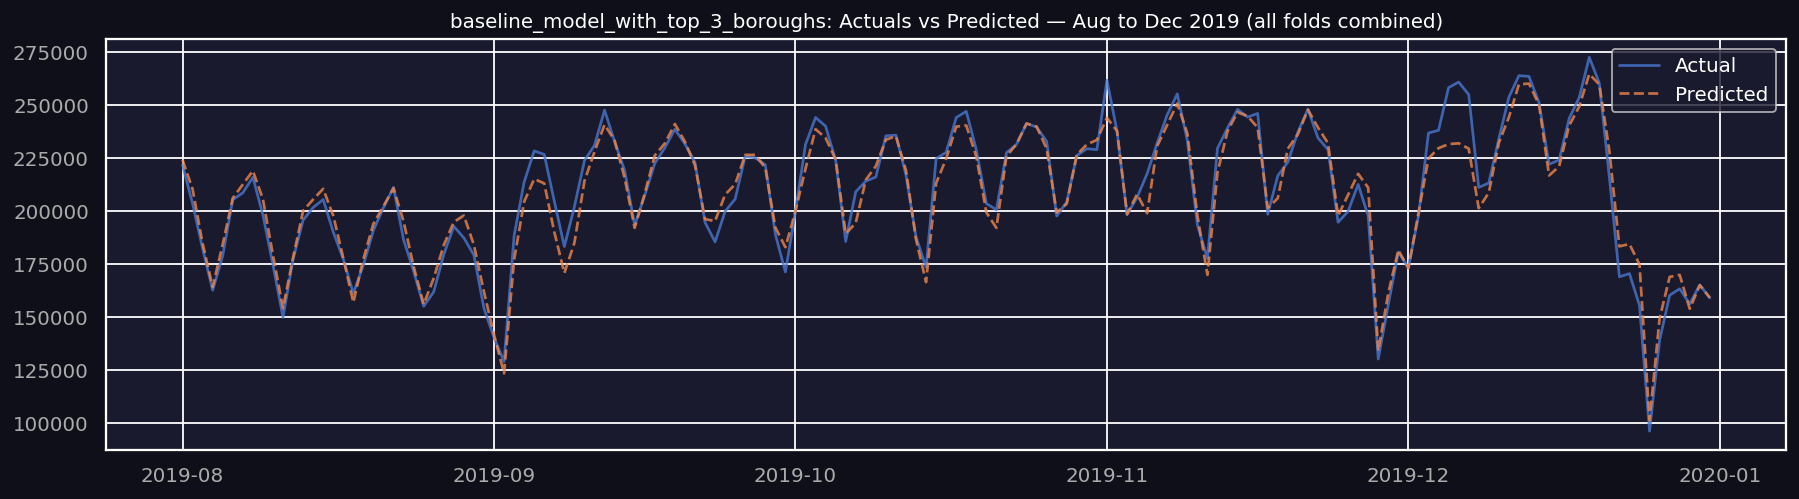

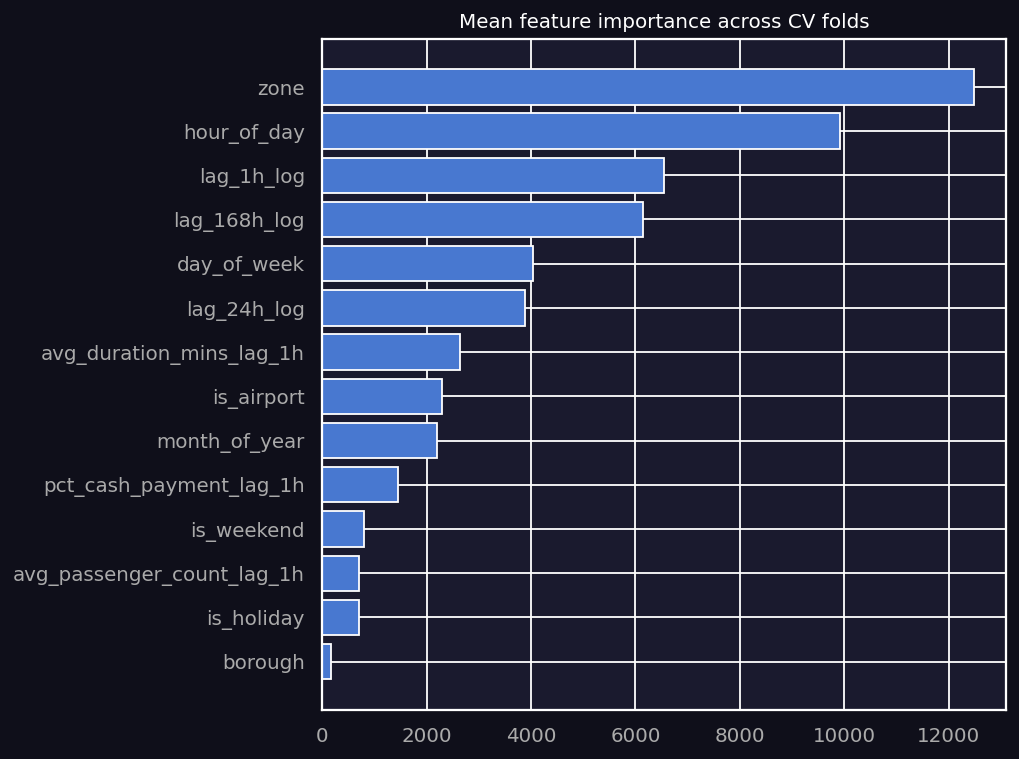

In [ ]:
# Run Analysis

run_model_analysis("baseline_model_with_top_3_boroughs", fold_results, all_fold_preds, feature_importance_frames)

#### Test model on 2020 data and save it

In [ ]:
# Load saved model
with open(MODEL_DIR / "baseline_model_top_3_boroughs.pkl", "rb") as f:
    baseline_model = pickle.load(f)
print(f"  Model loaded — best iteration: {baseline_model.best_iteration_}")

  Model loaded — best iteration: 1800


In [ ]:
# Prepare 2020 data

# filter 2020 zone data to top three boroughs
df_zone_2020 = df_zone_2020[df_zone_2020['borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

# Create is_airport flag
airport_zones = [
    "JFK Airport",
    "LaGuardia Airport"
]

df_zone_2020["is_airport"] = df_zone_2020["zone"].isin(airport_zones).astype(int)

# Build lag features
df_zone_2020_with_lag = build_lag_features(df_zone_2020).copy()

# #Drop first 168h per zone — these have unavoidably NaN lags
df_zone_2020_with_lag = df_zone_2020_with_lag.dropna(subset=["lag_168h"]).copy()

# Prepare model data and split by year
df_2020_data_with_prepared_feats = prepare_features(df_zone_2020_with_lag).copy()


  Lag features built — 1,721,664 rows (includes spine fill)
DEBUG: Dtypes for specified categorical_cols after conversion:
  zone: category
  hour_of_day: category
  day_of_week: category
  month_of_year: category
  is_holiday: category
  is_weekend: category
  is_airport: category
  borough: category


In [ ]:
# Predict 2020 results based on trained 2019 model

# Subset features only by features we are interested in
df_2020_dat_with_trained_feats_only = df_2020_data_with_prepared_feats.dropna(subset=FEATURES).copy()

# Align results for prediction
X_2020 = align_for_prediction(df_2020_dat_with_trained_feats_only[FEATURES], FEATURES, categorical_cols)

for col in categorical_cols:
    if col in X_2020.columns:
        X_2020[col] = X_2020[col].astype("category")

missing_train_cols = baseline_model.booster_.feature_name()
X_2020 = X_2020.reindex(columns=missing_train_cols)

# Predict on 2020 data and calculate residuals
df_2020_dat_with_trained_feats_only["y_pred"] = np.clip(baseline_model.predict(X_2020), 0, None)
df_2020_dat_with_trained_feats_only["residual"] = df_2020_dat_with_trained_feats_only[TARGET] - df_2020_dat_with_trained_feats_only["y_pred"]
df_2020_dat_with_trained_feats_only["abs_error"] = df_2020_dat_with_trained_feats_only["residual"].abs()

In [ ]:
# Function for evaluating our forecasts
def evaluate_forecast(y_true, y_pred, name="2020 Holdout"):
    actuals = np.asarray(y_true)
    preds = np.asarray(y_pred)

    if len(actuals) == 0:
        return {"error": "No data"}

    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    total_actual = actuals.sum()
    mean_demand = actuals.mean()

    wmape = (np.sum(np.abs(preds - actuals)) / total_actual) * 100 if total_actual > 0 else 0
    nmae = (mae / mean_demand) * 100 if mean_demand > 0 else np.nan

    bias_pct = ((preds - actuals).sum() / total_actual) * 100 if total_actual > 0 else np.nan

    return {
        "Period": name,
        "MAE": f"{mae:.2f}",
        "RMSE": f"{rmse:.2f}",
        "Total Actual": f"{total_actual:.0f}",
        "Mean Demand": f"{mean_demand:.1f}",
        "WMAPE": f"{wmape:.1f}%",
        "NMAE": f"{nmae:.1f}%",
        "Bias %": f"{bias_pct:.1f}%",
    }

In [ ]:
metrics_2020 = evaluate_forecast(
    df_2020_dat_with_trained_feats_only["trip_count"],
    df_2020_dat_with_trained_feats_only["y_pred"]
)

metrics_2020_df = pd.DataFrame([metrics_2020])
print(metrics_2020_df)

         Period   MAE   RMSE Total Actual Mean Demand  WMAPE   NMAE Bias %
0  2020 Holdout  5.99  13.33     21478682        35.8  16.7%  16.7%   4.7%


In [ ]:
df_2020_dat_with_trained_feats_only.head()

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log,y_pred,residual,abs_error
0,Alphabet City,2020-01-08,2020-01,Manhattan,Yellow Zone,7.0,3.0029,10.8571,7.7143,1.0000,...,7.0975,4.0,4.0,53.0,1.609438,1.609438,3.988984,13.208157,-6.208157,6.208157
2,SoHo,2020-01-08,2020-01,Manhattan,Yellow Zone,28.0,3.0793,11.9286,11.8214,1.5714,...,2.5800,45.0,18.0,115.0,3.828641,2.944439,4.753590,38.624472,-10.624472,10.624472
3,Clinton West,2020-01-08,2020-01,Manhattan,Yellow Zone,26.0,2.5169,9.9038,9.0385,1.4615,...,2.6278,46.0,16.0,180.0,3.850148,2.833213,5.198497,37.984827,-11.984827,11.984827
7,Clinton East,2020-01-08,2020-01,Manhattan,Yellow Zone,134.0,2.5845,11.0224,9.1493,1.6716,...,3.1139,265.0,125.0,440.0,5.583496,4.836282,6.089045,221.122452,-87.122452,87.122452
9,Chinatown,2020-01-08,2020-01,Manhattan,Yellow Zone,10.0,3.6640,13.2000,11.7000,1.2000,...,2.8922,18.0,10.0,40.0,2.944439,2.397895,3.713572,20.575011,-10.575011,10.575011


In [ ]:
df_2020_dat_with_trained_feats_only.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600371 entries, 0 to 1688735
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   zone                        600371 non-null  category      
 1   pickup_hour_ts              600371 non-null  datetime64[ns]
 2   file_month                  600371 non-null  object        
 3   borough                     600371 non-null  category      
 4   service_zone                600371 non-null  object        
 5   trip_count                  600371 non-null  float64       
 6   avg_trip_distance           600371 non-null  float64       
 7   avg_fare_amount             600371 non-null  float64       
 8   avg_duration_mins           600371 non-null  float64       
 9   avg_passenger_count         600371 non-null  float64       
 10  pct_card_payment            600371 non-null  float64       
 11  pct_cash_payment            600371 non-null

### Plot results

#### Plot of actuals vs predictions (overall and borough)

In [ ]:
# ── Colorblind-friendly palette ───────────────────────────────────
CB = {
    'actual'    : '#0072B2',   # deep blue
    'predicted' : '#E69F00',   # orange
    'wmape'     : '#D55E00',   # vermillion
    'residual'  : '#009E73',   # teal
    'covid'     : '#000000',   # black — COVID marker line
    'borough'   : ['#0072B2', '#E69F00', '#009E73'],  # blue, orange, teal
}

# ── Shared prep ───────────────────────────────────────────────────────────────
df = df_2020_dat_with_trained_feats_only.copy()
df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
df['date']  = df['pickup_hour_ts'].dt.date
df['month'] = df['pickup_hour_ts'].dt.to_period('M').astype(str)
COVID_DATE  = '2020-03-01'

boroughs = sorted(df['borough'].astype(str).unique().tolist())
print("Boroughs:", boroughs)  # confirm which three

# ── Daily aggregation ─────────────────────────────────────────────────────────
daily = (
    df.groupby('date')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
daily['date']  = pd.to_datetime(daily['date'])
daily['wmape'] = daily['abs_error'] / daily['actual'].replace(0, np.nan) * 100

# ── Monthly aggregation ───────────────────────────────────────────────────────
monthly = (
    df.groupby('month')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
monthly['wmape']      = monthly['abs_error'] / monthly['actual'].replace(0, np.nan) * 100
monthly['month_dt']   = pd.to_datetime(monthly['month'])

Boroughs: ['Brooklyn', 'Manhattan', 'Queens']


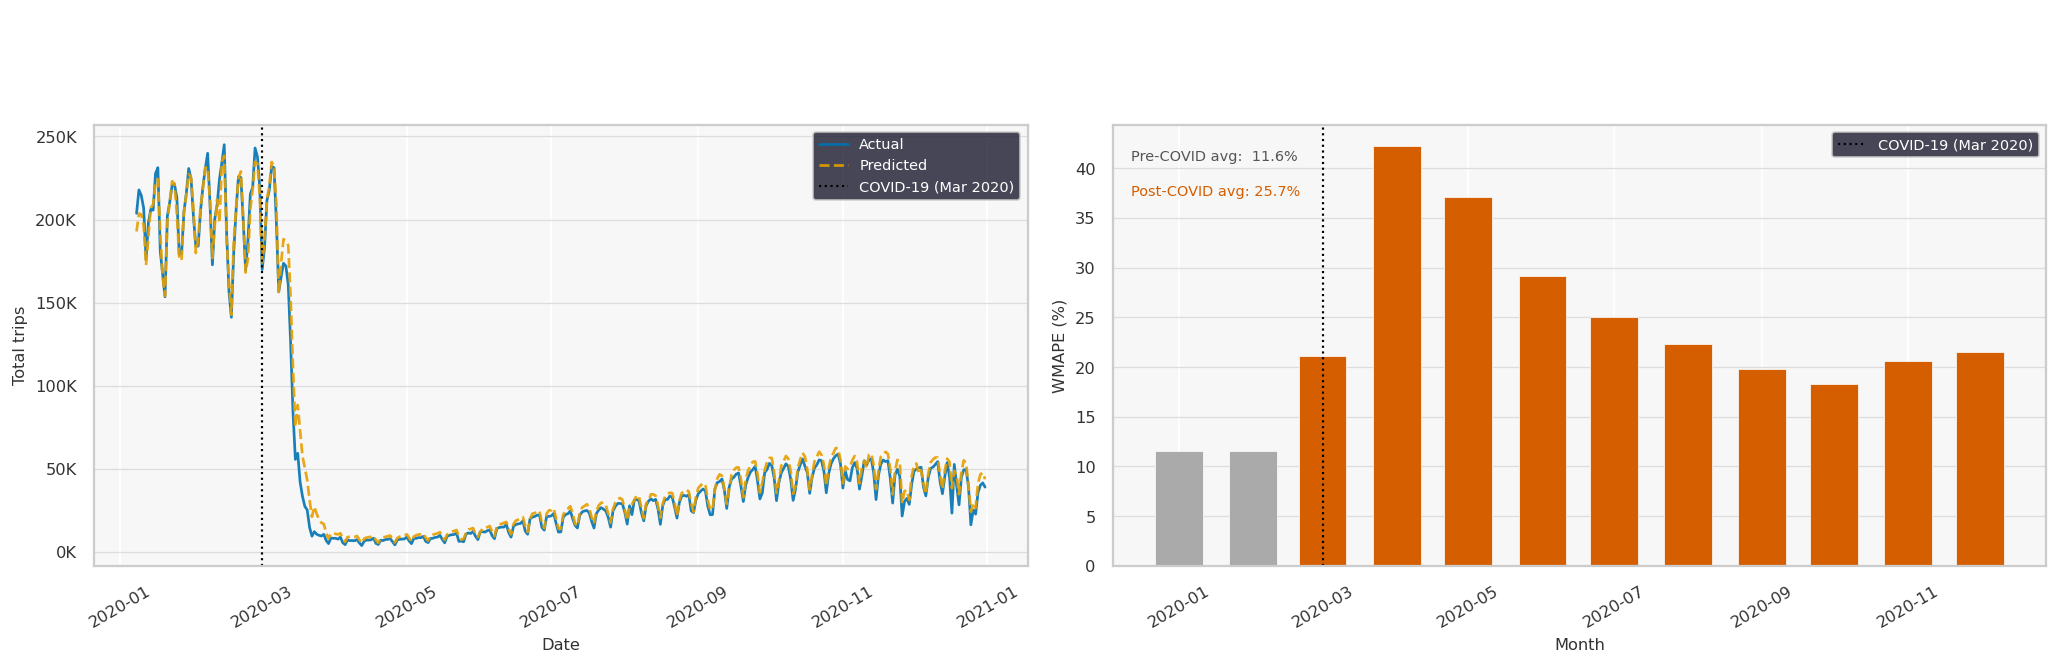

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Overall: actuals vs predicted  +  WMAPE
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')

# ── Panel A: daily actuals vs predicted ──────────────────────────────────────
ax = axes[0]

ax.plot(daily['date'], daily['actual'],
        color=CB['actual'], linewidth=1.5, label='Actual', alpha=0.9)
ax.plot(daily['date'], daily['predicted'],
        color=CB['predicted'], linewidth=1.5, label='Predicted',
        linestyle='--', alpha=0.9)

ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
           linewidth=1.2, linestyle=':', label='COVID-19 (Mar 2020)')

ax.set_title('Daily Trip Count — Actual vs Predicted', fontsize=11, pad=8)
ax.set_xlabel('Date')
ax.set_ylabel('Total trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# ── Panel B: monthly WMAPE ───────────────────────────────────────────────────
ax = axes[1]

bar_colours = [
    CB['wmape'] if str(m) >= '2020-03' else '#aaaaaa'
    for m in monthly['month']
]
ax.bar(monthly['month_dt'], monthly['wmape'],
       color=bar_colours, width=20, edgecolor='white', linewidth=0.4)

ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
           linewidth=1.2, linestyle=':', label='COVID-19 (Mar 2020)')

ax.set_title('Monthly WMAPE — Prediction Error Over Time', fontsize=11, pad=8)
ax.set_xlabel('Month')
ax.set_ylabel('WMAPE (%)')
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# Pre/post annotation
pre  = monthly[monthly['month'] <  '2020-03']['wmape'].mean()
post = monthly[monthly['month'] >= '2020-03']['wmape'].mean()
ax.text(0.02, 0.92, f'Pre-COVID avg:  {pre:.1f}%',
        transform=ax.transAxes, fontsize=8, color='#555555')
ax.text(0.02, 0.84, f'Post-COVID avg: {post:.1f}%',
        transform=ax.transAxes, fontsize=8, color=CB['wmape'])

plt.suptitle('Model Performance Degradation — 2020 (Yellow Zones)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'covid_overall.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


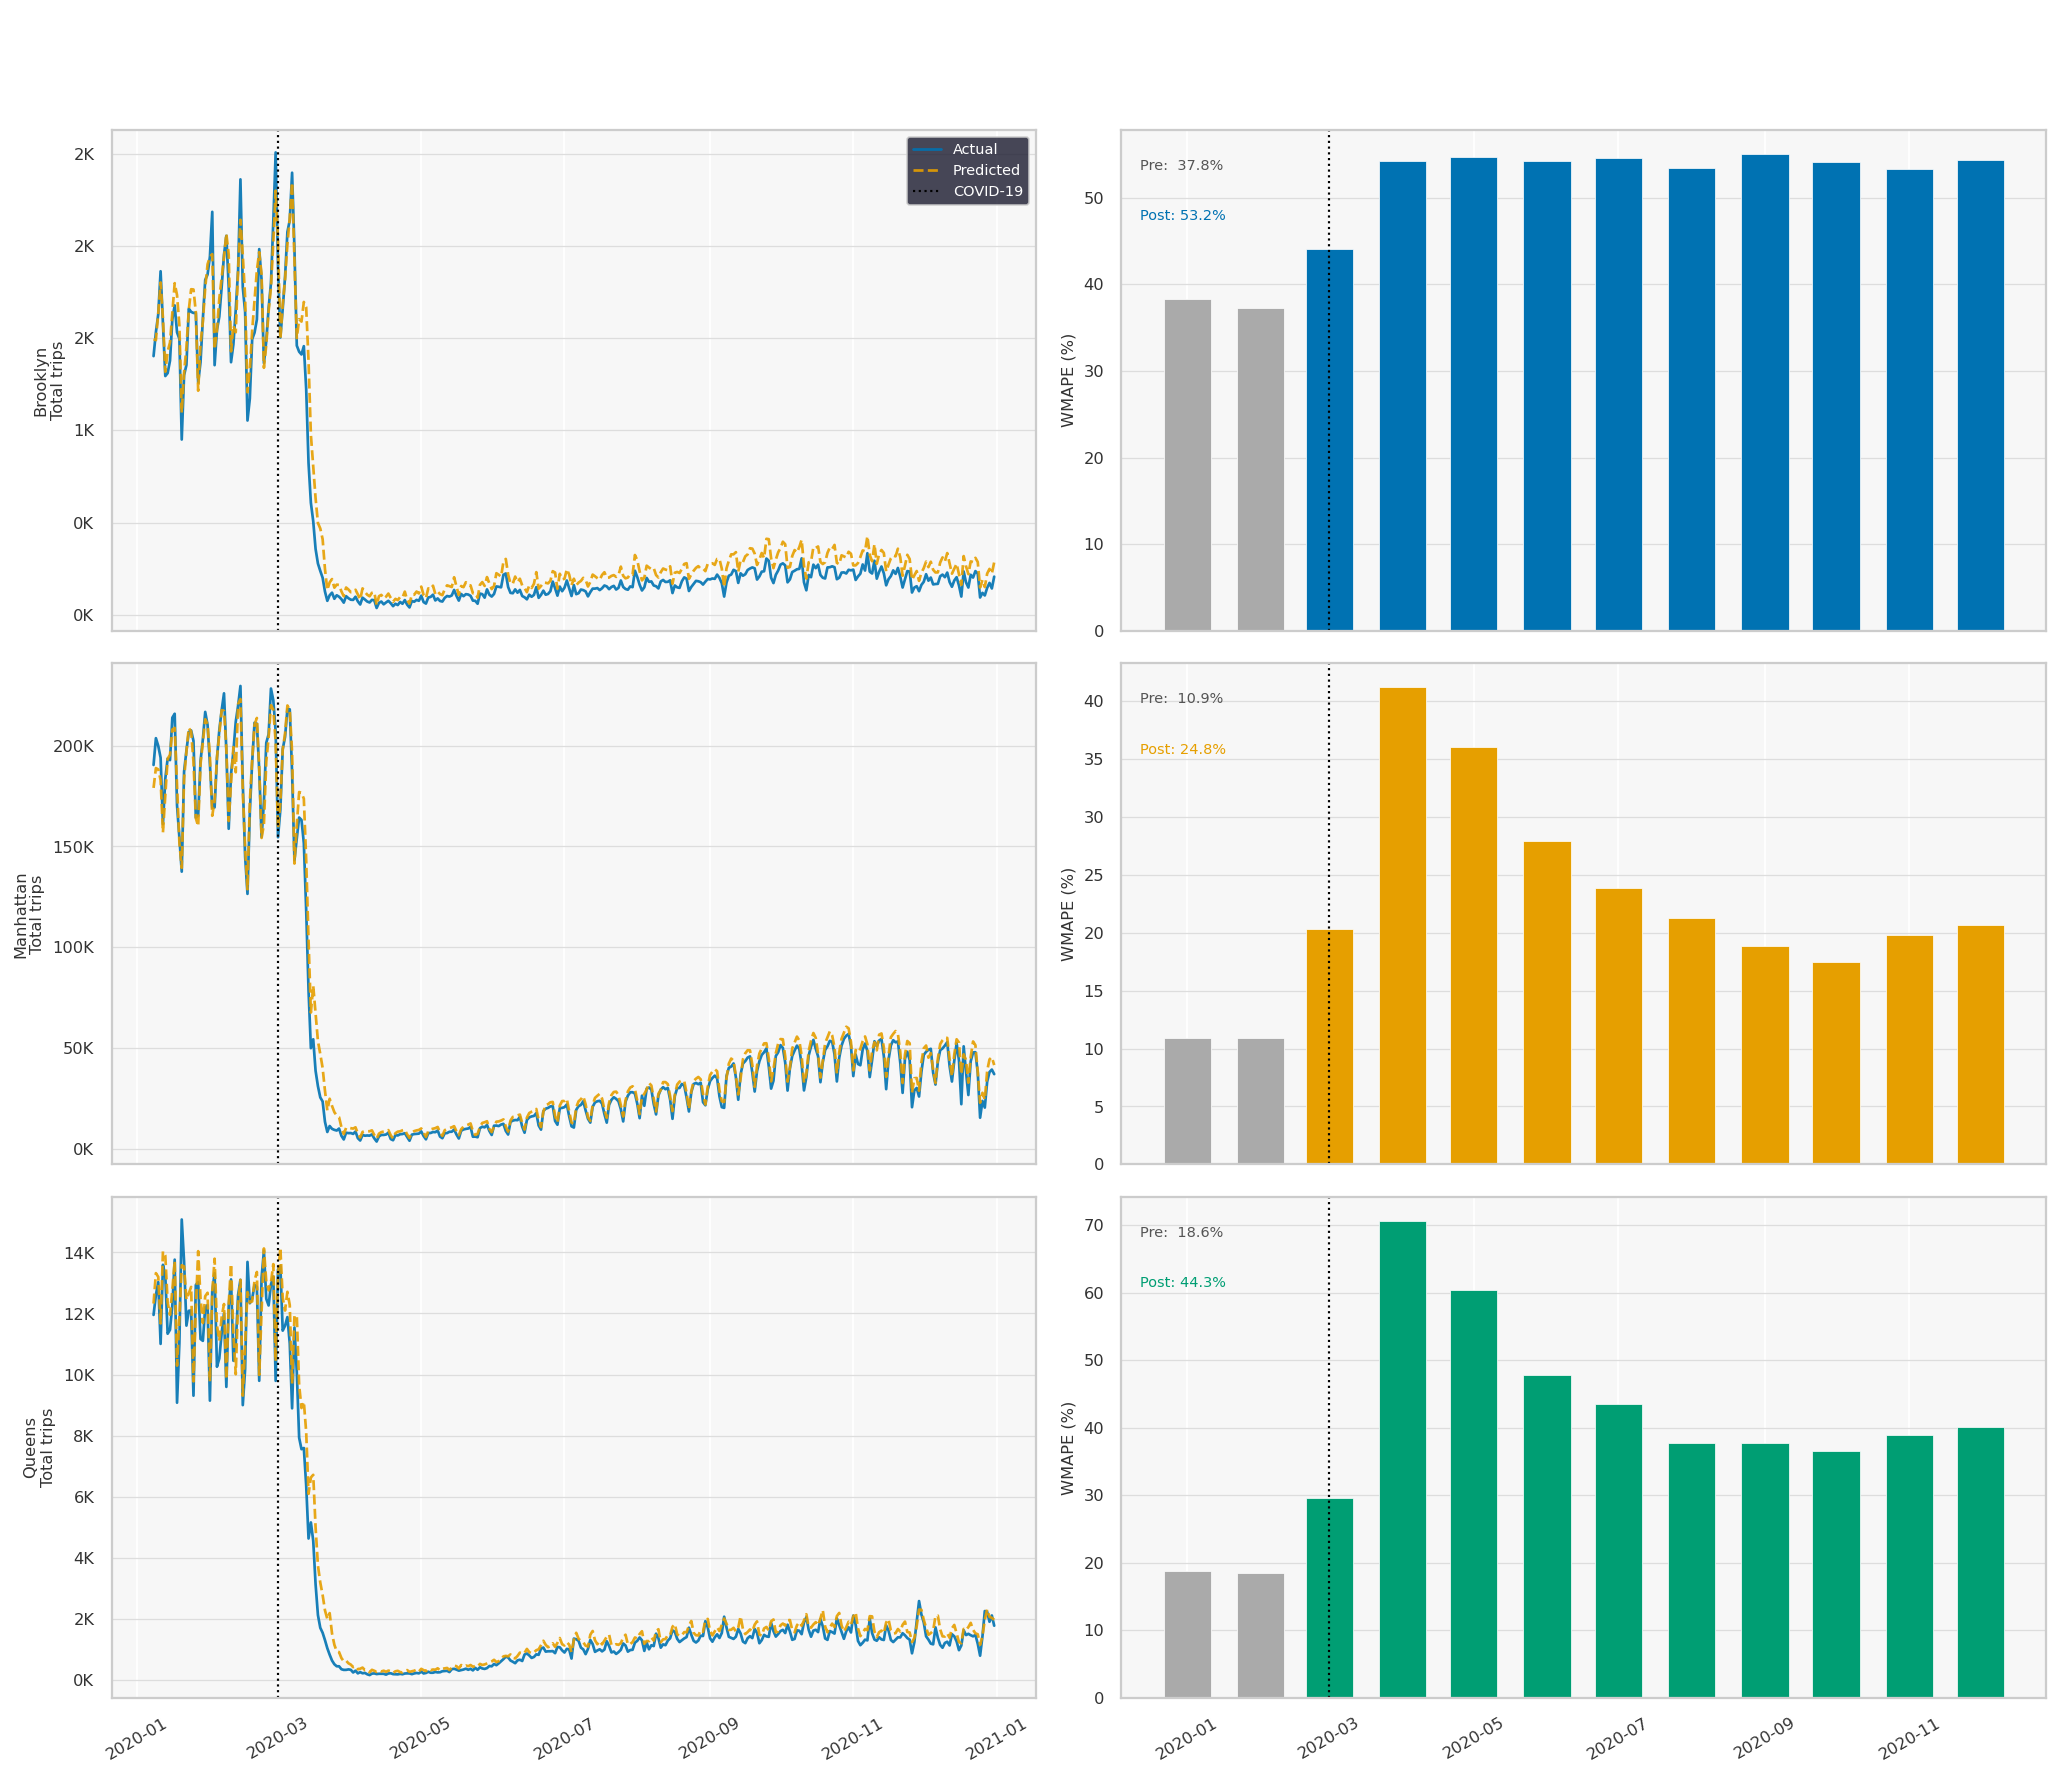

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — By borough: actuals vs predicted  +  WMAPE
# ══════════════════════════════════════════════════════════════════════════════
daily_b = (
    df.groupby(['date', 'borough'])
    .agg(actual=('trip_count','sum'), predicted=('y_pred','sum'),
         abs_error=('abs_error','sum'))
    .reset_index()
)
daily_b['date']  = pd.to_datetime(daily_b['date'])
daily_b['wmape'] = daily_b['abs_error'] / daily_b['actual'].replace(0, np.nan) * 100

monthly_b = (
    df.groupby(['month', 'borough'])
    .agg(actual=('trip_count','sum'), predicted=('y_pred','sum'),
         abs_error=('abs_error','sum'))
    .reset_index()
)
monthly_b['wmape']    = monthly_b['abs_error'] / monthly_b['actual'].replace(0, np.nan) * 100
monthly_b['month_dt'] = pd.to_datetime(monthly_b['month'])

fig, axes = plt.subplots(len(boroughs), 2,
                          figsize=(16, 4.5 * len(boroughs)),
                          sharex='col')
fig.patch.set_facecolor('white')

for ax in axes.flat:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')

for row, (borough, colour) in enumerate(zip(boroughs, CB['borough'])):

    b_daily   = daily_b[daily_b['borough']   == borough]
    b_monthly = monthly_b[monthly_b['borough'] == borough]

    # ── Left: actuals vs predicted ───────────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(b_daily['date'], b_daily['actual'],
            color=CB['actual'], linewidth=1.5, label='Actual', alpha=0.9)
    ax.plot(b_daily['date'], b_daily['predicted'],
            color=CB['predicted'], linewidth=1.5, label='Predicted',
            linestyle='--', alpha=0.9)
    ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
               linewidth=1.2, linestyle=':', label='COVID-19')

    ax.set_ylabel(f'{borough}\nTotal trips', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.grid(axis='y', color='#dddddd', linewidth=0.7)
    ax.tick_params(axis='x', rotation=30)
    if row == 0:
        ax.set_title('Daily Actual vs Predicted', fontsize=11, pad=8)
        ax.legend(fontsize=8, framealpha=0.8)

    # ── Right: WMAPE ─────────────────────────────────────────────────────────
    ax = axes[row, 1]
    bar_colours = [
        colour if str(m) >= '2020-03' else '#aaaaaa'
        for m in b_monthly['month']
    ]
    ax.bar(b_monthly['month_dt'], b_monthly['wmape'],
           color=bar_colours, width=20,
           edgecolor='white', linewidth=0.4)
    ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
               linewidth=1.2, linestyle=':')

    pre  = b_monthly[b_monthly['month'] <  '2020-03']['wmape'].mean()
    post = b_monthly[b_monthly['month'] >= '2020-03']['wmape'].mean()
    ax.text(0.02, 0.92, f'Pre:  {pre:.1f}%',
            transform=ax.transAxes, fontsize=8, color='#555555')
    ax.text(0.02, 0.82, f'Post: {post:.1f}%',
            transform=ax.transAxes, fontsize=8, color=colour)

    ax.set_ylabel('WMAPE (%)', fontsize=9)
    ax.grid(axis='y', color='#dddddd', linewidth=0.7)
    ax.tick_params(axis='x', rotation=30)
    if row == 0:
        ax.set_title('Monthly WMAPE', fontsize=11, pad=8)

plt.suptitle('Model Performance by Borough — 2020',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'covid_by_borough.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


### Save results

In [ ]:
# Save results
df_2020_dat_with_trained_feats_only.to_parquet(PREDICT_DIR / "2020_predictions_with_top_3_boroughs_only.parquet", index=False)


# Section 9: Drift Detection

## Prepare reference and monitoring datasets

In [ ]:
# TODO: Update dataframe name to df_2020_dat_with_trained_feats_only or assign it as monitoring data

In [ ]:
# Check if any NAs exist (returns True/False)
df_2020_data_with_prepared_feats['is_airport'].isna().any()

# Count how many NAs are in the column
df_2020_data_with_prepared_feats['is_airport'].isna().sum()

df_2020_data_with_prepared_feats['is_airport'].unique()

[0.0, NaN, 1.0]
Categories (2, float64): [0.0, 1.0]

In [ ]:
# Display only the rows where this column has an NA
df_2020_data_with_prepared_feats[df_2020_data_with_prepared_feats['is_airport'].isna()]

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_passenger_count_lag_1h,avg_duration_mins_lag_1h,avg_fare_amount_lag_1h,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log
1,Cobble Hill,2020-01-08 00:00:00,2020-01,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,2.0,0.000000,0.000000,1.098612
4,South Jamaica,2020-01-08 00:00:00,2020-01,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,1.0,0.0,0.000000,0.693147,0.000000
5,Clinton Hill,2020-01-08 00:00:00,2020-01,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,1.5,5.5,5.75,0.95,2.0,1.0,9.0,1.098612,0.693147,2.302585
6,South Ozone Park,2020-01-08 00:00:00,2020-01,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,1.0,0.000000,0.000000,0.693147
8,South Williamsburg,2020-01-08 00:00:00,2020-01,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,1.0,0.0,0.000000,0.693147,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688723,North Corona,2020-12-31 23:00:00,2020-12,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,1.0,26.0,13.50,3.82,1.0,0.0,0.0,0.693147,0.000000,0.000000
1688724,Murray Hill-Queens,2020-12-31 23:00:00,2020-12,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
1688727,Midwood,2020-12-31 23:00:00,2020-12,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
1688732,Middle Village,2020-12-31 23:00:00,2020-12,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
df_2020_data_with_prepared_feats[df_2020_data_with_prepared_feats['is_airport']== 0.0]

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_passenger_count_lag_1h,avg_duration_mins_lag_1h,avg_fare_amount_lag_1h,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log
0,Alphabet City,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,7.0,3.0029,10.8571,7.7143,1.0000,...,1.5000,29.7500,22.3750,7.0975,4.0,4.0,53.0,1.609438,1.609438,3.988984
2,SoHo,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,28.0,3.0793,11.9286,11.8214,1.5714,...,1.1556,10.6222,11.0444,2.5800,45.0,18.0,115.0,3.828641,2.944439,4.753590
3,Clinton West,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,26.0,2.5169,9.9038,9.0385,1.4615,...,1.4783,9.1957,10.3152,2.6278,46.0,16.0,180.0,3.850148,2.833213,5.198497
7,Clinton East,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,134.0,2.5845,11.0224,9.1493,1.6716,...,1.6679,12.1547,12.1038,3.1139,265.0,125.0,440.0,5.583496,4.836282,6.089045
9,Chinatown,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,10.0,3.6640,13.2000,11.7000,1.2000,...,1.3889,12.2778,11.6944,2.8922,18.0,10.0,40.0,2.944439,2.397895,3.713572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688729,Midtown North,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,13.0,2.4692,10.1923,10.3846,1.4615,...,1.7857,11.4286,13.5000,3.4336,14.0,7.0,10.0,2.708050,2.079442,2.397895
1688730,Midtown East,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,13.0,2.6515,10.9231,10.4615,1.3846,...,1.1154,9.3462,10.1731,2.5896,26.0,17.0,21.0,3.295837,2.890372,3.091042
1688731,Midtown Center,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,19.0,2.6237,11.8947,13.4737,2.0000,...,1.4231,9.5000,9.0769,2.0735,26.0,20.0,11.0,3.295837,3.044522,2.484907
1688733,Meatpacking/West Village West,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,2.0,1.1000,6.0000,4.5000,2.0000,...,1.7500,13.2500,12.7500,3.3850,8.0,0.0,2.0,2.197225,0.000000,1.098612


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

# Fix is_airport nulls before anything else
ref_data = baseline_model_data_with_prepared_feats.copy()
mon_data = df_2020_data_with_prepared_feats.copy()

ref_data['is_airport'] = ref_data['is_airport'].fillna(0)
mon_data['is_airport'] = mon_data['is_airport'].fillna(0)

# Feature groups
exogenous_features = [
    'hour_of_day', 'day_of_week', 'month_of_year',
    'is_weekend',  'is_holiday',  'is_airport',
]
demand_derived_features = [
    'pct_cash_payment_lag_1h',
    'avg_duration_mins_lag_1h',
    'avg_passenger_count_lag_1h',
    'lag_1h_log',
    'lag_24h_log',
    'lag_168h_log',
]
features_to_monitor = exogenous_features + demand_derived_features

# Thresholds
THRESHOLDS = {
    'psi':        {'moderate': 0.10, 'significant': 0.20},
    'js':         {'moderate': 0.05, 'significant': 0.10},
    'wass_norm':  {'moderate': 0.05, 'significant': 0.10},
}

MONTHS_2020 = [f'2020-{m:02d}' for m in range(1, 13)]

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIC FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def compute_psi(ref, cur, bins=10):
    """PSI — magnitude of population shift."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    breakpoints = np.linspace(ref.min(), ref.max(), bins + 1)
    breakpoints[0]  -= 1e-6
    breakpoints[-1] += 1e-6

    ref_counts, _ = np.histogram(ref, bins=breakpoints)
    cur_counts, _ = np.histogram(cur, bins=breakpoints)

    ref_pct = ref_counts / len(ref)
    cur_pct = cur_counts / len(cur)

    # Avoid log(0) — replace zeros with small value
    ref_pct = np.where(ref_pct == 0, 1e-6, ref_pct)
    cur_pct = np.where(cur_pct == 0, 1e-6, cur_pct)

    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


def compute_js(ref, cur, bins=10):
    """JS divergence — bounded [0,1], symmetric."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    breakpoints = np.linspace(
        min(ref.min(), cur.min()),
        max(ref.max(), cur.max()),
        bins + 1
    )
    ref_counts, _ = np.histogram(ref, bins=breakpoints)
    cur_counts, _ = np.histogram(cur, bins=breakpoints)

    ref_pct = ref_counts / ref_counts.sum()
    cur_pct = cur_counts / cur_counts.sum()

    return float(jensenshannon(ref_pct, cur_pct))


def compute_wasserstein_norm(ref, cur):
    """Wasserstein distance normalised by reference std — comparable across features."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    ref_std = ref.std()
    if ref_std == 0:
        return 0.0

    return float(wasserstein_distance(ref, cur) / ref_std)


def compute_ks(ref, cur):
    """KS test — returns (statistic, p_value). Shown but not in vote."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan, np.nan

    stat, pval = ks_2samp(ref, cur)
    return round(float(stat), 4), round(float(pval), 4)


def classify_drift(psi, js, wass_norm):
    """
    Voting logic — 2/3 metrics must agree to flag drift.
    Level is determined by how many flag significant vs moderate.
    """
    def level(val, metric):
        if pd.isna(val):
            return 0
        t = THRESHOLDS[metric]
        if val >= t['significant']:
            return 2
        elif val >= t['moderate']:
            return 1
        return 0

    levels = [level(psi, 'psi'), level(js, 'js'), level(wass_norm, 'wass_norm')]
    votes_drifted    = sum(l >= 1 for l in levels)
    votes_significant = sum(l >= 2 for l in levels)

    if votes_drifted    >= 2 and votes_significant >= 2:
        return 'SIGNIFICANT DRIFT'
    elif votes_drifted  >= 2:
        return 'MODERATE DRIFT'
    else:
        return 'STABLE'

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MAIN DRIFT LOOP
# ══════════════════════════════════════════════════════════════════════════════

def run_drift_analysis(ref_df, mon_df, features, group_label='Overall'):
    """
    Runs drift analysis for each feature × month.
    Returns a detailed DataFrame with all metric scores + drift label.
    """
    records = []

    for month in MONTHS_2020:
        cur = mon_df[mon_df['file_month'] == month]
        if cur.empty:
            continue

        for feat in features:
            if feat not in ref_df.columns or feat not in cur.columns:
                continue

            ref_vals = ref_df[feat]
            cur_vals = cur[feat]

            psi       = compute_psi(ref_vals, cur_vals)
            js        = compute_js(ref_vals, cur_vals)
            wass_norm = compute_wasserstein_norm(ref_vals, cur_vals)
            ks_stat, ks_pval = compute_ks(ref_vals, cur_vals)
            label     = classify_drift(psi, js, wass_norm)

            records.append({
                'group'         : group_label,
                'feature'       : feat,
                'month'         : month,
                'psi'           : round(psi,       4) if not np.isnan(psi)       else np.nan,
                'js'            : round(js,        4) if not np.isnan(js)        else np.nan,
                'wass_norm'     : round(wass_norm, 4) if not np.isnan(wass_norm) else np.nan,
                'ks_stat'       : ks_stat,
                'ks_pval'       : ks_pval,
                'drift_label'   : label,
            })

    return pd.DataFrame(records)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY PIVOT
# ══════════════════════════════════════════════════════════════════════════════

def make_summary_pivot(detail_df):
    """
    Pivot detailed results into a feature × month summary table.
    Each cell shows the drift label — easy to scan for patterns.
    """
    pivot = detail_df.pivot_table(
        index   = ['group', 'feature'],
        columns = 'month',
        values  = 'drift_label',
        aggfunc = 'first'
    )
    # Shorten month labels for readability
    pivot.columns = [m[5:] for m in pivot.columns]  # '2020-03' → '03'
    return pivot

## Covariate Drift Results

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RUN — Overall, Service Zone, Borough
# ══════════════════════════════════════════════════════════════════════════════

all_results = []

# ── Overall ───────────────────────────────────────────────────────────────────
print("Running overall drift...")
overall = run_drift_analysis(ref_data, mon_data, features_to_monitor, 'Overall')
all_results.append(overall)

# ── By service zone ───────────────────────────────────────────────────────────
for sz in ref_data['service_zone'].dropna().unique():
    print(f"Running drift — service zone: {sz}...")
    ref_sz = ref_data[ref_data['service_zone'] == sz]
    mon_sz = mon_data[mon_data['service_zone'] == sz]
    result = run_drift_analysis(ref_sz, mon_sz, features_to_monitor, f'SZ: {sz}')
    all_results.append(result)

# ── By borough ────────────────────────────────────────────────────────────────
for b in ref_data['borough'].astype(str).unique():
    if b in ['EWR', 'Unknown']:
        continue
    print(f"Running drift — borough: {b}...")
    ref_b = ref_data[ref_data['borough'].astype(str) == b]
    mon_b = mon_data[mon_data['borough'].astype(str) == b]
    result = run_drift_analysis(ref_b, mon_b, features_to_monitor, f'Borough: {b}')
    all_results.append(result)

# ── Combine ───────────────────────────────────────────────────────────────────
drift_detailed = pd.concat(all_results, ignore_index=True)
drift_summary  = make_summary_pivot(drift_detailed)

print(f"\nDone — {len(drift_detailed):,} feature-month-group combinations")

Running overall drift...
Running drift — service zone: Yellow Zone...
Running drift — service zone: Boro Zone...
Running drift — service zone: Airports...
Running drift — borough: Manhattan...
Running drift — borough: Brooklyn...
Running drift — borough: Queens...

Done — 1,008 feature-month-group combinations


In [ ]:
# Save results

# ── Save detailed table ───────────────────────────────────────────────────────
drift_detailed.to_csv(DRIFT_DIR / 'drift_detailed.csv', index=False)
print(f"Saved detailed: {len(drift_detailed):,} rows")

# ── Save summary pivot ────────────────────────────────────────────────────────
# Reset index so group and feature become regular columns
drift_summary.reset_index().to_csv(DRIFT_DIR / 'drift_summary.csv', index=False)
print("Saved summary")

# ── Reload ────────────────────────────────────────────────────────────────────
# drift_detailed = pd.read_csv(DRIFT_DIR / 'drift_detailed.csv')
# drift_summary  = pd.read_csv(DRIFT_DIR / 'drift_summary.csv').set_index(['group', 'feature'])

Saved detailed: 1,008 rows
Saved summary


In [ ]:
# ── View detailed table for a specific group ──────────────────────────────────
def view_detailed(group_label):
    df = drift_detailed[drift_detailed['group'] == group_label].copy()
    df = df.drop(columns='group').sort_values(['feature', 'month'])

    # Changed applymap to map to keep up with modern Pandas syntax
    display(df.style.map(
        lambda v: 'background-color: #ffcccc; color: black;' if v == 'SIGNIFICANT DRIFT'
             else 'background-color: #fff3cc; color: black;' if v == 'MODERATE DRIFT'
             else '',
        subset=['drift_label']
    ))

# ── View summary pivot for a specific group ───────────────────────────────────
def view_summary(group_label):
    df = drift_summary.loc[[group_label]] if group_label in drift_summary.index.get_level_values(0) else drift_summary

    # Appended color: black; to all styled states
    display(df.style.map(
        lambda v: 'background-color: #ffcccc; font-weight: bold; color: black;' if v == 'SIGNIFICANT DRIFT'
             else 'background-color: #fff3cc; color: black;'                    if v == 'MODERATE DRIFT'
             else 'background-color: #e8f5e9; color: black;'                    if v == 'STABLE'
             else ''
    ))

# ── Usage ─────────────────────────────────────────────────────────────────────
view_detailed('Overall')
view_summary('Overall')

view_detailed('SZ: Yellow Zone')
view_summary('SZ: Yellow Zone')

view_detailed('Borough: Manhattan')
view_summary('Borough: Manhattan')

,feature,month,psi,js,wass_norm,ks_stat,ks_pval,drift_label
7,avg_duration_mins_lag_1h,2020-01,0.043400,0.073300,0.179000,0.089200,0.000000,MODERATE DRIFT
19,avg_duration_mins_lag_1h,2020-02,0.035300,0.066200,0.166200,0.075600,0.000000,MODERATE DRIFT
31,avg_duration_mins_lag_1h,2020-03,0.128400,0.124900,0.358900,0.213400,0.000000,SIGNIFICANT DRIFT
43,avg_duration_mins_lag_1h,2020-04,0.399200,0.210300,0.603000,0.388000,0.000000,SIGNIFICANT DRIFT
55,avg_duration_mins_lag_1h,2020-05,0.325400,0.192500,0.561600,0.352100,0.000000,SIGNIFICANT DRIFT
67,avg_duration_mins_lag_1h,2020-06,0.228800,0.164400,0.493300,0.294200,0.000000,SIGNIFICANT DRIFT
79,avg_duration_mins_lag_1h,2020-07,0.213000,0.158900,0.465400,0.271300,0.000000,SIGNIFICANT DRIFT
91,avg_duration_mins_lag_1h,2020-08,0.194600,0.152400,0.441800,0.252200,0.000000,SIGNIFICANT DRIFT
103,avg_duration_mins_lag_1h,2020-09,0.172100,0.143900,0.414500,0.230000,0.000000,SIGNIFICANT DRIFT
115,avg_duration_mins_lag_1h,2020-10,0.166100,0.141300,0.404100,0.217300,0.000000,SIGNIFICANT DRIFT


,feature,month,psi,js,wass_norm,ks_stat,ks_pval,drift_label
151,avg_duration_mins_lag_1h,2020-01,0.038400,0.068500,0.227800,0.121200,0.000000,MODERATE DRIFT
163,avg_duration_mins_lag_1h,2020-02,0.022400,0.052400,0.169200,0.084600,0.000000,MODERATE DRIFT
175,avg_duration_mins_lag_1h,2020-03,0.392600,0.197600,0.706200,0.317900,0.000000,SIGNIFICANT DRIFT
187,avg_duration_mins_lag_1h,2020-04,1.401700,0.403600,1.481600,0.624200,0.000000,SIGNIFICANT DRIFT
199,avg_duration_mins_lag_1h,2020-05,1.082100,0.193600,1.276200,0.538900,0.000000,SIGNIFICANT DRIFT
211,avg_duration_mins_lag_1h,2020-06,0.655100,0.282100,0.977900,0.410800,0.000000,SIGNIFICANT DRIFT
223,avg_duration_mins_lag_1h,2020-07,0.540400,0.256800,0.833300,0.363900,0.000000,SIGNIFICANT DRIFT
235,avg_duration_mins_lag_1h,2020-08,0.425200,0.228400,0.726400,0.323400,0.000000,SIGNIFICANT DRIFT
247,avg_duration_mins_lag_1h,2020-09,0.296500,0.192300,0.641000,0.273200,0.000000,SIGNIFICANT DRIFT
259,avg_duration_mins_lag_1h,2020-10,0.218200,0.164300,0.566500,0.233400,0.000000,SIGNIFICANT DRIFT


,feature,month,psi,js,wass_norm,ks_stat,ks_pval,drift_label
583,avg_duration_mins_lag_1h,2020-01,0.061800,0.087500,0.181400,0.108100,0.000000,MODERATE DRIFT
595,avg_duration_mins_lag_1h,2020-02,0.035900,0.066800,0.143700,0.078200,0.000000,MODERATE DRIFT
607,avg_duration_mins_lag_1h,2020-03,0.127800,0.125100,0.541500,0.290000,0.000000,SIGNIFICANT DRIFT
619,avg_duration_mins_lag_1h,2020-04,0.327400,0.194600,1.104900,0.564200,0.000000,SIGNIFICANT DRIFT
631,avg_duration_mins_lag_1h,2020-05,0.239900,0.168800,0.946400,0.484000,0.000000,SIGNIFICANT DRIFT
643,avg_duration_mins_lag_1h,2020-06,0.145600,0.133200,0.723200,0.364500,0.000000,SIGNIFICANT DRIFT
655,avg_duration_mins_lag_1h,2020-07,0.138700,0.130100,0.621300,0.317200,0.000000,SIGNIFICANT DRIFT
667,avg_duration_mins_lag_1h,2020-08,0.123300,0.122900,0.546600,0.282900,0.000000,SIGNIFICANT DRIFT
679,avg_duration_mins_lag_1h,2020-09,0.116900,0.119700,0.492700,0.240300,0.000000,SIGNIFICANT DRIFT
691,avg_duration_mins_lag_1h,2020-10,0.099600,0.110700,0.439500,0.206100,0.000000,SIGNIFICANT DRIFT


## Change-Point Detection: When exactly does our data changes?

**TODO:** Test to see if ADWIN appears more apparent for daily data rather than for weekly aggregated data.

In [ ]:
# Install river package
# If not installed - need to downgrade numpy before installing
!pip install "numpy<2.1,>=1.22"
!pip install river --break-system-packages -q

# If prompted to restart do not restart if you intend to proceed with the analysis below.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 849.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 14.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
river 0.24.2 requires numpy<3,>=2.3.4, but you have numpy 2.0.2 which is incompatible.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [ ]:
from river.drift import ADWIN, PageHinkley

# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

mon_data = df_2020_dat_with_trained_feats_only.copy()

# NYC COVID policy dates for validation
COVID_DATES = {
    '2020-01-21': 'First US COVID case',
    '2020-03-01': 'First NYC COVID case',
    '2020-03-07': 'NY State of Emergency',
    '2020-03-22': 'NY PAUSE (lockdown)',
    '2020-06-08': 'NYC Phase 1 reopening',
    '2020-07-06': 'NYC Phase 3 reopening',
    '2020-09-30': 'Indoor dining resumed',
    '2020-10-06': 'Zoned shutdown (micro-cluster)',
    '2020-12-11': 'Indoor dining banned'
    #'2020-12-15': 'First Winter Storm'
}


In [ ]:
# ── Weekly aggregation ────────────────────────────────────────────────────────
def make_weekly_stream(df, value_col, borough=None):
    """
    Aggregate to weekly level for a given column.
    borough=None returns overall stream.
    """
    d = df.copy()
    if borough:
        d = d[d['borough'].astype(str) == borough]

    d['week'] = pd.to_datetime(d['pickup_hour_ts']).dt.to_period('W').dt.start_time

    weekly = (
        d.groupby('week')[value_col]
        .mean()
        .reset_index()
        .sort_values('week')
        .rename(columns={value_col: 'value'})
    )
    weekly['borough'] = borough if borough else 'Overall'
    return weekly

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DETECTOR
# ══════════════════════════════════════════════════════════════════════════════

def run_detectors(weekly_df, stream_name):
    """
    Run ADWIN and Page-Hinkley (downward) on a weekly stream.
    Returns a DataFrame of detected change points.
    """

    # Previous parameters
    adwin  = ADWIN(delta=0.01,
                   min_window_length = 5)        # lower delta = more sensitive
    ph  = PageHinkley(               # downward shift detection
        min_instances=5,
        delta=0.005,
        threshold=25,                  # higher = less sensitive to noise
        alpha=0.9999
    )

    # ph = drift.PageHinkley(
    # min_instances=4,
    # delta=0.001,
    # threshold=0.05,
    # alpha=0.99
    # )

    change_points = []
    values        = weekly_df['value'].tolist()
    weeks         = weekly_df['week'].tolist()
    borough       = weekly_df['borough'].iloc[0]

    for i, (week, val) in enumerate(zip(weeks, values)):

        # ADWIN — feed negative value to detect downward shift
        adwin.update(-val)
        if adwin.drift_detected:
            change_points.append({
                'week'    : week,
                'borough' : borough,
                'stream'  : stream_name,
                'detector': 'ADWIN',
                'value'   : round(val, 3),
            })

        # Page-Hinkley — negate stream for downward detection
        ph.update(-val)
        if ph.drift_detected:
            change_points.append({
                'week'    : week,
                'borough' : borough,
                'stream'  : stream_name,
                'detector': 'PageHinkley',
                'value'   : round(val, 3),
            })

    return pd.DataFrame(change_points)



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RUN — both streams, both detectors, all boroughs
# ══════════════════════════════════════════════════════════════════════════════
boroughs     = [b for b in mon_data['borough'].astype(str).unique()
                if b not in ['EWR', 'Unknown']]
all_cp       = []

for stream_col, stream_name in [('trip_count', 'Trip Count'),
                                  ('residual',   'Residual')]:
    print(f"\n── Stream: {stream_name} ──")

    # Overall
    weekly = make_weekly_stream(mon_data, stream_col)
    cp     = run_detectors(weekly, stream_name)
    all_cp.append(cp)
    print(f"  Overall      — {len(cp)} change points")

    # Per borough
    for b in boroughs:
        weekly = make_weekly_stream(mon_data, stream_col, borough=b)
        cp     = run_detectors(weekly, stream_name)
        all_cp.append(cp)
        print(f"  {b:<15} — {len(cp)} change points")

cp_df = pd.concat(all_cp, ignore_index=True)
cp_df['week'] = pd.to_datetime(cp_df['week'])
print(f"\nTotal change points detected: {len(cp_df)}")


── Stream: Trip Count ──
  Overall      — 4 change points
  Manhattan       — 5 change points
  Brooklyn        — 1 change points
  Queens          — 3 change points

── Stream: Residual ──
  Overall      — 1 change points
  Manhattan       — 2 change points
  Brooklyn        — 0 change points
  Queens          — 0 change points

Total change points detected: 16


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BOROUGH CONSISTENCY CHECK
# ══════════════════════════════════════════════════════════════════════════════
def check_borough_consistency(cp_df, boroughs, stream_name, detector):
    """
    For each detected week, count how many boroughs fired.
    Flags weeks where 2+ boroughs agree — stronger signal.
    """
    subset = cp_df[
        (cp_df['stream']   == stream_name) &
        (cp_df['detector'] == detector)    &
        (cp_df['borough'].isin(boroughs))
    ]
    if subset.empty:
        return pd.DataFrame()

    summary = (
        subset.groupby('week')
        .agg(
            boroughs_fired = ('borough', lambda x: ', '.join(sorted(x))),
            n_boroughs     = ('borough', 'count'),
        )
        .reset_index()
        .sort_values('week')
    )
    summary['consensus'] = summary['n_boroughs'] >= 2
    return summary


print("\n── Borough consistency ──")
for stream_name in ['Trip Count', 'Residual']:
    for detector in ['ADWIN', 'PageHinkley']:
        cons = check_borough_consistency(cp_df, boroughs, stream_name, detector)
        if cons.empty:
            continue
        agreed = cons[cons['consensus']]
        print(f"\n  {stream_name} | {detector} — "
              f"{len(agreed)} weeks with 2+ borough agreement:")
        if not agreed.empty:
            for _, row in agreed.iterrows():
                nearest = min(
                    COVID_DATES.keys(),
                    key=lambda d: abs(pd.to_datetime(d) - row['week'])
                )
                days_diff = (row['week'] - pd.to_datetime(nearest)).days
                print(f"    {str(row['week'])[:10]}  |  "
                      f"boroughs: {row['boroughs_fired']}  |  "
                      f"nearest policy date: {nearest} "
                      f"({COVID_DATES[nearest]}, {days_diff:+d} days)")



── Borough consistency ──

  Trip Count | ADWIN — 1 weeks with 2+ borough agreement:
    2020-08-10  |  boroughs: Manhattan, Queens  |  nearest policy date: 2020-07-06 (NYC Phase 3 reopening, +35 days)

  Trip Count | PageHinkley — 0 weeks with 2+ borough agreement:

  Residual | PageHinkley — 0 weeks with 2+ borough agreement:


In [ ]:
# Print all change points with their dates — do this before tuning anything
print(cp_df.sort_values(['stream', 'borough', 'week'])
      [['stream', 'detector', 'borough', 'week', 'value']]
      .to_string(index=False))


    stream    detector   borough       week   value
  Residual PageHinkley Manhattan 2020-03-09 -12.246
  Residual PageHinkley Manhattan 2020-04-27  -1.509
  Residual PageHinkley   Overall 2020-03-16 -12.845
Trip Count PageHinkley  Brooklyn 2020-07-13   1.235
Trip Count PageHinkley Manhattan 2020-03-09  87.926
Trip Count PageHinkley Manhattan 2020-05-04   7.323
Trip Count PageHinkley Manhattan 2020-07-20  17.963
Trip Count       ADWIN Manhattan 2020-08-10  21.196
Trip Count PageHinkley Manhattan 2020-09-21  32.965
Trip Count PageHinkley   Overall 2020-03-09  58.175
Trip Count PageHinkley   Overall 2020-07-20  15.005
Trip Count       ADWIN   Overall 2020-08-10  17.587
Trip Count PageHinkley   Overall 2020-09-28  26.470
Trip Count PageHinkley    Queens 2020-03-23   3.181
Trip Count       ADWIN    Queens 2020-08-10   6.156
Trip Count PageHinkley    Queens 2020-08-17   6.534


In [ ]:
def check_borough_consistency_window(cp_df, boroughs, stream_name,
                                     detector, window_weeks=2):
    """
    Flags weeks where 2+ boroughs fire within a rolling window.
    More realistic than exact-week matching for weekly data.
    """
    subset = cp_df[
        (cp_df['stream']   == stream_name) &
        (cp_df['detector'] == detector)    &
        (cp_df['borough'].isin(boroughs))
    ].copy()

    if subset.empty:
        return pd.DataFrame()

    subset = subset.sort_values('week')
    records = []

    # For each change point, check if another borough fires within window
    for _, row in subset.iterrows():
        window_start = row['week'] - pd.Timedelta(weeks=window_weeks)
        window_end   = row['week'] + pd.Timedelta(weeks=window_weeks)

        nearby = subset[
            (subset['week']    >= window_start) &
            (subset['week']    <= window_end)   &
            (subset['borough'] != row['borough'])
        ]

        if not nearby.empty:
            records.append({
                'anchor_borough' : row['borough'],
                'anchor_week'    : row['week'],
                'nearby_boroughs': ', '.join(sorted(nearby['borough'].unique())),
                'nearby_weeks'   : ', '.join(
                    nearby['week'].dt.strftime('%Y-%m-%d').unique()
                ),
                'n_boroughs'     : len(nearby['borough'].unique()) + 1,
                'stream'         : stream_name,
                'detector'       : detector,
            })

    if not records:
        return pd.DataFrame()

    result = (
        pd.DataFrame(records)
        .drop_duplicates(subset=['anchor_week', 'stream', 'detector'])
        .sort_values('anchor_week')
    )

    # Add nearest COVID policy date
    result['nearest_policy'] = result['anchor_week'].apply(
        lambda w: min(COVID_DATES.keys(),
                      key=lambda d: abs(pd.to_datetime(d) - w))
    )
    result['policy_label'] = result['nearest_policy'].map(COVID_DATES)
    result['days_from_policy'] = result.apply(
        lambda r: (r['anchor_week'] -
                   pd.to_datetime(r['nearest_policy'])).days, axis=1
    )
    return result

# ── Run with 2-week window ────────────────────────────────────────────────────
print("── Borough consistency (±2 week window) ──\n")
for stream_name in ['Trip Count', 'Residual']:
    for detector in ['ADWIN', 'PageHinkley']:
        cons = check_borough_consistency_window(
            cp_df, boroughs, stream_name, detector, window_weeks=2
        )
        if cons.empty:
            print(f"  {stream_name} | {detector} — no agreement within window")
            continue
        print(f"  {stream_name} | {detector} — "
              f"{len(cons)} cluster(s) with 2+ borough agreement:")
        display(cons[[
            'anchor_week', 'anchor_borough', 'nearby_boroughs',
            'nearby_weeks', 'n_boroughs',
            'nearest_policy', 'policy_label', 'days_from_policy'
        ]])

── Borough consistency (±2 week window) ──

  Trip Count | ADWIN — no agreement within window
  Trip Count | PageHinkley — 4 cluster(s) with 2+ borough agreement:


,anchor_week,anchor_borough,nearby_boroughs,nearby_weeks,n_boroughs,nearest_policy,policy_label,days_from_policy
0,2020-03-09,Manhattan,Queens,2020-03-23,2,2020-03-07,NY State of Emergency,2
1,2020-03-23,Queens,Manhattan,2020-03-09,2,2020-03-22,NY PAUSE (lockdown),1
2,2020-07-13,Brooklyn,Manhattan,2020-07-20,2,2020-07-06,NYC Phase 3 reopening,7
3,2020-07-20,Manhattan,Brooklyn,2020-07-13,2,2020-07-06,NYC Phase 3 reopening,14


  Residual | ADWIN — no agreement within window
  Residual | PageHinkley — no agreement within window


# Section 10: Old Drift Detection

In [ ]:
# Load optimal model and df_gold data

# with open(MODEL_DIR / "model.pkl", "rb") as f:
#     model = pickle.load(f)
# print(f"  Model loaded — best iteration: {model.best_iteration_}")

with open(MODEL_DIR / "model_with_more_features.pkl", "rb") as f:
    baseline_model = pickle.load(f)
print(f"  Model loaded — best iteration: {baseline_model.best_iteration_}")

### Prepare 2019 and 2020 datasets for drift detection

In [ ]:
# 1. Load and prepare 2019 and 2020 data into gold

# Define months to load
MONTHS_TO_INGEST = [
    '2019-01', '2019-02', '2019-03',
    '2019-04', '2019-05', '2019-06',
    '2019-07', '2019-08', '2019-09',
    '2019-10', '2019-11', '2019-12',
    '2020-01', '2020-02', '2020-03',
    '2020-04', '2020-05', '2020-06',
    '2020-07', '2020-08', '2020-09',
    '2020-10', '2020-11', '2020-12',
]

# The load gold data for 2019 and 2020
df_2019 = load_gold(MONTHS_TO_INGEST[:12])
df_2020 = load_gold(MONTHS_TO_INGEST[12:])

In [ ]:
# Check for missing counts per year
for df, y in [(df_2019, 2019), (df_2020, 2020)]:
    print(f"\n=== {y} overall missing counts ===")
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(missing)
    else:
        print("(no missing values in any column)")

In [ ]:
df_2020.info()

In [ ]:
# Attach year, then build lags on the concatenated full dataset
df_2019["year"] = 2019
df_2020["year"] = 2020

df_full = pd.concat([df_2019, df_2020], ignore_index=True)
df_lagged = build_lag_features(df_full)  # your existing function

for col in ['lag_1h', 'lag_24h', 'lag_168h','precipitation','snowfall']:
    df_lagged[f'{col}_log'] = np.log1p(df_lagged[col])


In [ ]:
# columns in df_lagged
print(df_lagged.columns)

In [ ]:
# Now identify if there is any missingness in the weather columns and lag features.
cols_of_interest = [
    "temperature_2m", "windspeed_10m",
    "lag_1h_log", "lag_24h_log", "lag_168h_log",
    "pct_card_payment_lag_1h",
    "pct_cash_payment_lag_1h",
    "avg_duration_mins_lag_1h",
    "avg_passenger_count_lag_1h"
]

for col in cols_of_interest:
    if col in df_lagged.columns:
        by_year = df_lagged.groupby("year")[col].apply(
            lambda x: x.isna().mean()
        ).round(4)
        print(f"{col:30} missing fraction: {by_year.to_dict()}")


In [ ]:
# We will need to drop boundary rows (i.e. starting rows for each zone as they can distort distributions)

lag_cols = ["lag_1h_log", "lag_24h_log", "lag_168h_log","pct_card_payment_lag_1h","pct_cash_payment_lag_1h",
            "avg_duration_mins_lag_1h","avg_passenger_count_lag_1h"]

# Function to drop the first N rows per zone so all lags are defined
def drop_lag_boundary_rows(df, location_col, lag_specs):
    """
    lag_specs: list of tuples like [("lag_1h", 1), ("lag_24h", 24), ("lag_168h", 168)]
    """
    df = df.copy()

    # Sort so boundary is at the start
    df = df.sort_values([location_col, "pickup_hour_ts"]).reset_index(drop=True)

    # For each lag, record how many rows we must drop per group
    lag_n_per_group = {}
    for col, n in lag_specs:
        if col in df.columns:
            lag_n_per_group[col] = n

    if not lag_n_per_group:
        return df

    # Drop the *most* rows required per zone (168 in your case)
    max_n = max(lag_n_per_group.values())

    df_clean = df.groupby(location_col, group_keys=False).apply(
        lambda g: g.iloc[max_n:]   # drop first max_n rows per zone
    )
    return df_clean

# Use for your drift‑analysis slice
drift_specs = [
    ("lag_1h_log", 1),
    ("lag_24h_log", 24),
    ("lag_168h_log", 168),
    ("pct_card_payment_lag_1h", 1),
    ("pct_cash_payment_lag_1h", 1),
    ("avg_duration_mins_lag_1h", 1),
    ("avg_passenger_count_lag_1h", 1)
]

df_drift = drop_lag_boundary_rows(df_lagged, location_col="zone", lag_specs=drift_specs)

# Now you can safely compare 2019 vs 2020 without boundary artifacts
summary_missing = {}
for col in lag_cols:
    if col in df_drift.columns:
        by_year = df_drift.groupby("year")[col].apply(
            lambda x: x.isna().mean()
        ).round(6)
        summary_missing[col] = by_year.to_dict()

print(summary_missing)

In [ ]:
# Join service zones information from taxi zones parquet and save into different parquet
df_taxi_zones = pd.read_csv(ZONE_LOOKUP_PATH)
df_taxi_zones

In [ ]:
# Display duplicates grouped by 'pickup_hour_ts' and 'zone', ordered by those variables
duplicates = df_taxi_zones[df_taxi_zones.duplicated(subset=['Zone'], keep=False)]
duplicates = duplicates.sort_values(by=['Zone'])

display(duplicates)

In [ ]:
# There are duplicates in df_taxi_zones when grouping by Zone
# There are no duplicate rows by LocationID
df_taxi_zones[df_taxi_zones['Zone'].isin(["Governor's Island/Ellis Island/Liberty Island","Corona"])]

In [ ]:
# Select only Zone and Service Zone and only get distinct combinations
df_taxi_zones = df_taxi_zones[['Zone', 'service_zone']].drop_duplicates()
df_taxi_zones

# Rename Zone to zone
df_taxi_zones.rename(columns={'Zone': 'zone'}, inplace=True)
df_taxi_zones

In [ ]:
# Temporary fix
df_drift_with_service_zones = df_drift.copy()
df_drift_with_service_zones = df_drift_with_service_zones.merge(df_taxi_zones,
                                                                on='zone',
                                                                how='left')
# Print out test
if (len(df_drift) != len(df_drift_with_service_zones)):
    print(f"Joining did not work\n df_drift has {len(df_drift)} rows whereas df_drift_with_service_zones has {len(df_drift_with_service_zones)}")

# df_drift_with_service_zones.drop(columns=['LocationID','borough'], inplace=True)
# df_drift.rename(columns={'zone': 'LocationID'}, inplace=True)
# df_drift

In [ ]:
df_drift_with_service_zones.info()

In [ ]:
# Save drift data
DRIFT_DATA = BASE / 'drift_data'
DRIFT_DATA.mkdir(parents=True, exist_ok=True)

drift_data_parquet_directory = DRIFT_DATA / "drift_data_with_more_feat_no_boundary_rows_and_service_zones.parquet"
df_drift_with_service_zones.to_parquet(drift_data_parquet_directory, index=False)

### Create reference, monitoring and sub-window datasets

In [ ]:
# Read saved drift detection data
DRIFT_DATA = BASE / 'drift_data'
# drift_data_parquet_directory = DRIFT_DATA / "full_drift_data_no_boundary_rows.parquet"
drift_data_parquet_directory = DRIFT_DATA / "drift_data_with_more_feat_no_boundary_rows.parquet"
df_drift = pd.read_parquet(drift_data_parquet_directory)

In [ ]:
display(df_drift)

In [ ]:
df_drift['trip_count']

In [ ]:
# Define features we want to observe
target_variable = ["trip_count"]

lag_features = [
    "pct_card_payment_lag_1h",
    "pct_cash_payment_lag_1h",
    "lag_1h_log",
    "lag_24h_log",
    "lag_168h_log",
    "avg_duration_mins_lag_1h",
    "avg_passenger_count_lag_1h"
]

temp_features = [
    "temperature_2m",
    "windspeed_10m",
]

boolean_features = [
    "is_holiday",
    "is_weekend"
]

In [ ]:
# all_features = avg_features + lag_features + temp_features
all_features = boolean_features + lag_features + temp_features

In [ ]:
# Full year split -

df_2019 = df_drift[df_drift["year"] == 2019].copy()
df_2020 = df_drift[df_drift["year"] == 2020].copy()

In [ ]:
df_2020.info()

### Define functions for Drift Analysis

In [ ]:
# Define paths for saving results
BASE = Path("/content/drive/MyDrive/ODATA57078")
OUT_DIR = BASE / "drift_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Define shared colour palette for plots.

In [ ]:
PALETTE = {
    "bg": "#141826",
    "panel": "#1C2233",
    "grid": "#3B4254",
    "text": "#E8EAF2",
    "muted": "#A8B0C0",
    "blue": "#4C9BE8",      # 2019 / reference
    "orange": "#F5A623",    # 2020 / comparison
    "purple": "#9B7BFF",
    "green": "#58C27D",
    "red": "#F05D5E",
    "yellow": "#E6C229",
}

plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="notebook")

Prepare timestamps and layout for plots.

In [ ]:
def prep_ts(df, ts_col="pickup_hour_ts"):
    out = df.copy()
    if ts_col in out.columns:
        out[ts_col] = pd.to_datetime(out[ts_col])
    return out

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(PALETTE["panel"])
    ax.grid(True, color=PALETTE["grid"], alpha=0.35, linewidth=0.8)
    ax.tick_params(colors=PALETTE["text"])
    for spine in ax.spines.values():
        spine.set_color(PALETTE["grid"])
    if title:
        ax.set_title(title, color=PALETTE["text"], fontsize=12, weight="bold")
    if xlabel:
        ax.set_xlabel(xlabel, color=PALETTE["text"])
    if ylabel:
        ax.set_ylabel(ylabel, color=PALETTE["text"])

Define functions for calculating drift detection metrics.

In [ ]:
# Calculates probability stability index
def compute_psi(ref, test, bins=10, eps=1e-6):
    ref = pd.Series(ref).dropna()
    test = pd.Series(test).dropna()
    if len(ref) == 0 or len(test) == 0:
        return np.nan

    qs = np.unique(ref.quantile(np.linspace(0, 1, bins + 1)).values)
    if len(qs) < 3:
        return np.nan

    r, _ = np.histogram(ref, bins=qs)
    t, _ = np.histogram(test, bins=qs)

    r = np.clip(r / max(r.sum(), 1), eps, None)
    t = np.clip(t / max(t.sum(), 1), eps, None)

    return float(np.sum((t - r) * np.log(t / r)))

# Calculates Jensen-Shannon distance
def compute_js(ref, test, bins=50, eps=1e-8):
    ref = pd.Series(ref).dropna()
    test = pd.Series(test).dropna()
    if len(ref) == 0 or len(test) == 0:
        return np.nan

    combined = np.concatenate([ref.values, test.values])
    lo, hi = np.nanpercentile(combined, [1, 99])
    if lo == hi:
        return np.nan

    r, edges = np.histogram(ref.clip(lo, hi), bins=bins, range=(lo, hi), density=True)
    t, _ = np.histogram(test.clip(lo, hi), bins=edges, density=True)

    r = np.clip(r, eps, None)
    t = np.clip(t, eps, None)
    r = r / r.sum()
    t = t / t.sum()
    m = 0.5 * (r + t)

    return float(0.5 * np.sum(r * np.log(r / m)) + 0.5 * np.sum(t * np.log(t / m)))

# Calculates Wasserstein Distance
def compute_wasserstein(ref, test):
    ref = pd.Series(ref).dropna()
    test = pd.Series(test).dropna()
    if len(ref) == 0 or len(test) == 0:
        return np.nan
    return float(wasserstein_distance(ref.values, test.values))


Prepare table for storing metrics

In [ ]:
# Prepares summary drift table
def drift_table(df, features, ref_mask, test_mask):
    rows = []
    for feat in features:
        if feat not in df.columns:
            continue
        ref = df.loc[ref_mask, feat]
        test = df.loc[test_mask, feat]

        rows.append({
            "feature": feat,
            "ref_n": int(ref.notna().sum()),
            "test_n": int(test.notna().sum()),
            "psi": compute_psi(ref, test),
            "js": compute_js(ref, test),
            "wasserstein": compute_wasserstein(ref, test),
            "ref_mean": ref.mean(),
            "test_mean": test.mean(),
            "delta_mean": test.mean() - ref.mean(),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out["drift_score"] = out[["psi", "js", "wasserstein"]].fillna(0).sum(axis=1)
        out = out.sort_values(["drift_score", "psi", "js", "wasserstein"], ascending=False).reset_index(drop=True)
    return out

# Prepares monthly drift table
def monthly_drift_table(df, features, ref_year=2019, test_year=2020, month_col="month_of_year"):
    d = prep_ts(df)
    if "year" not in d.columns:
        d["year"] = d["pickup_hour_ts"].dt.year
    if month_col not in d.columns:
        d[month_col] = d["pickup_hour_ts"].dt.month

    all_rows = []
    for m in sorted(d[month_col].dropna().unique()):
        ref_mask = (d["year"] == ref_year) & (d[month_col] == m)
        test_mask = (d["year"] == test_year) & (d[month_col] == m)

        tab = drift_table(d, features, ref_mask, test_mask)
        if tab.empty:
            continue
        tab.insert(0, "month", int(m))
        all_rows.append(tab)

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

### Define Functions for Drift Analysis Plots

KDE Comparisons

In [ ]:
def plot_kde_comparisons(df, features, year_a=2019, year_b=2020, month=None, group_col=None, top_n_groups=4):
    d = prep_ts(df).copy()
    if "year" not in d.columns:
        d["year"] = d["pickup_hour_ts"].dt.year
    if "month_of_year" not in d.columns:
        d["month_of_year"] = d["pickup_hour_ts"].dt.month

    if month is not None:
        d = d[d["month_of_year"] == month].copy()

    groups = [None]
    if group_col is not None and group_col in d.columns:
        groups = d[group_col].value_counts().head(top_n_groups).index.tolist()

    for feat in features:
        if feat not in d.columns:
            continue

        fig, axes = plt.subplots(len(groups), 1, figsize=(12, 4 * len(groups)), squeeze=False)
        fig.patch.set_facecolor(PALETTE["bg"])

        for ax, grp in zip(axes.ravel(), groups):
            if grp is None:
                ref = d.loc[d["year"] == year_a, feat].dropna()
                tst = d.loc[d["year"] == year_b, feat].dropna()
                subtitle = "Overall"
            else:
                ref = d.loc[(d["year"] == year_a) & (d[group_col] == grp), feat].dropna()
                tst = d.loc[(d["year"] == year_b) & (d[group_col] == grp), feat].dropna()
                subtitle = f"{group_col}: {grp}"

            if len(ref) == 0 or len(tst) == 0:
                ax.axis("off")
                continue

            combined = pd.concat([ref, tst], ignore_index=True)
            lo, hi = combined.quantile(0.01), combined.quantile(0.99)

            sns.kdeplot(ref.clip(lo, hi), ax=ax, color=PALETTE["blue"], fill=True, alpha=0.25, linewidth=2, label=str(year_a))
            sns.kdeplot(tst.clip(lo, hi), ax=ax, color=PALETTE["orange"], fill=True, alpha=0.25, linewidth=2, label=str(year_b))
            style_ax(ax, f"{feat} — {subtitle}", feat, "Density")
            ax.legend(frameon=True, facecolor=PALETTE["panel"], edgecolor=PALETTE["grid"])

        plt.tight_layout()
        plt.show()

Top Monthly PSI heatmap

In [ ]:
def plot_monthly_psi_heatmap(monthly_tab, top_n=12, save_name="monthly_psi_heatmap.png"):
    if monthly_tab.empty:
        return None

    top_features = (
        monthly_tab.groupby("feature")["psi"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    pivot = (
        monthly_tab[monthly_tab["feature"].isin(top_features)]
        .pivot(index="feature", columns="month", values="psi")
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor(PALETTE["bg"])
    sns.heatmap(pivot, cmap="magma", linewidths=0.4, linecolor=PALETTE["grid"], ax=ax)
    style_ax(ax, "Top monthly PSI features", "Month", "Feature")
    out_path = OUT_DIR / save_name
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    return out_path

SHAP rank change plot

In [ ]:
# ------------------------------------------------------------
# Optional: SHAP rank change plot if SHAP tables exist
# ------------------------------------------------------------
def plot_shap_rank_change(shap_df, save_name="shap_rank_change.png"):
    if shap_df.empty:
        return None
    d = shap_df.copy().sort_values("shap2020", ascending=False)
    x = np.arange(len(d))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.bar(x - width/2, d["shap2019"], width, label="2019 reference", color=PALETTE["blue"], alpha=0.85)
    ax.bar(x + width/2, d["shap2020"], width, label="2020 post-COVID", color=PALETTE["orange"], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(d["feature"], rotation=45, ha="right", fontsize=8)
    style_ax(ax, "SHAP feature importance: 2019 vs 2020", "", "Mean |SHAP|")
    ax.legend(frameon=True, facecolor=PALETTE["panel"], edgecolor=PALETTE["grid"])
    out_path = OUT_DIR / save_name
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    return out_path


### Drift Analysis

#### Current Analysis

In [ ]:
# ------------------------------------------------------------
# Define drift features
# ------------------------------------------------------------
drift_features = [
    #"trip_count",
    # "pct_card_payment",
    # "pct_cash_payment",
    # "avg_trip_distance",
    # "avg_fare_amount",
    # "avg_duration_mins",
    # "avg_passenger_count",
    "hour_of_day",
    "day_of_week",
    "month_of_year",
    "is_weekend",
    "is_holiday",
    "temperature_2m",
    # "precipitation_log",
    # "snowfall_log",
    "windspeed_10m",
    "lag_1h_log",
    "lag_24h_log",
    "lag_168h_log",
    # "pct_card_payment_lag_1h",
    "pct_cash_payment_lag_1h",
    "avg_duration_mins_lag_1h",
    "avg_passenger_count_lag_1h",
]

In [ ]:
# ------------------------------------------------------------
# Build monthly drift table
# ------------------------------------------------------------
if "df_drift" in globals():
    df_drift = prep_ts(df_drift)
    if "year" not in df_drift.columns:
        df_drift["year"] = df_drift["pickup_hour_ts"].dt.year
    if "month_of_year" not in df_drift.columns:
        df_drift["month_of_year"] = df_drift["pickup_hour_ts"].dt.month

    # Explicitly convert boolean columns to int for PSI calculation compatibility
    for col in ["is_weekend", "is_holiday"]:
        if col in df_drift.columns:
            df_drift[col] = df_drift[col].astype(int)

    monthly_drift = monthly_drift_table(df_drift, drift_features, ref_year=2019, test_year=2020)
    monthly_drift.to_csv(OUT_DIR / "monthly_drift_table.csv", index=False)
    display(monthly_drift.head(20))
else:
    monthly_drift = pd.DataFrame()

In [ ]:
# ------------------------------------------------------------
# Build overall drift table
# ------------------------------------------------------------
if "df_drift" in globals():
    ref_mask = df_drift["pickup_hour_ts"].dt.year == 2019
    test_mask = df_drift["pickup_hour_ts"].dt.year == 2020
    overall_drift = drift_table(df_drift, [f for f in drift_features if f in df_drift.columns], ref_mask, test_mask)
    overall_drift.to_csv(OUT_DIR / "overall_drift_table.csv", index=False)
    display(overall_drift.head(20))
else:
    overall_drift = pd.DataFrame()

In [ ]:
# RESET COLOUR DEFAULTS
# plt.style.use("default")
# plt.rcParams.update({
#     "figure.facecolor": PALETTE["bg"],
#     "axes.facecolor":   PALETTE["panel"],
#     "text.color":       PALETTE["text"],
#     "axes.labelcolor":  PALETTE["text"],
#     "xtick.color":      PALETTE["text"],
#     "ytick.color":      PALETTE["text"],
# })

In [ ]:
BASE_DIR = Path("drift_data")  # adjust to your paths
OUT_DIR = Path("plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COVID_START = "2020-03-01"

# Colors (replace with your PALETTE if needed)
PALETTE = {
    "bg": "white",
    "blue": "#1f77b4",
    "purple": "#9467bd",
    "yellow":"#f0e442",
    "orange": "#ff7f0e",
    "red": "#d62728",
    "muted": "#7f7f7f",
    "text": "black",
    "grid": "#dddddd",
    "panel": "white"
}

def _prep_df_for_overview_plot(df):
    """Minimal data prep - adjust column names as needed"""
    df = df.copy()

    # Standardize column names
    if "abs_error" in df.columns:
        df["abserror"] = df["abs_error"]
    elif "abserror" not in df.columns and "residual" in df.columns:
        df["abserror"] = df["residual"].abs()

    if "trip_count" not in df.columns:
        df["trip_count"] = df.get("target", df.get("y", np.nan))

    return df.dropna(subset=["pickup_hour_ts", "trip_count", "abserror"])

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor(PALETTE["panel"])
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15, color=PALETTE["text"])
    ax.set_xlabel(xlabel, fontsize=12, color=PALETTE["text"])
    ax.set_ylabel(ylabel, fontsize=12, color=PALETTE["text"])
    ax.grid(True, alpha=0.3, color=PALETTE["grid"])
    ax.tick_params(axis="both", which="major", labelsize=10, colors=PALETTE["text"])
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["grid"])

# Switching from MAE to WAPE, because WAPE normalizes absolute error by actual volume,
# so low-demand months won’t falsely look “better” just because trip counts collapsed.
# WAPE is defined as total absolute error divided by total actuals
def _wape(num_abs_error, denom_actual):
    return np.where(denom_actual > 0, (num_abs_error / denom_actual) * 100, np.nan)


In [ ]:
# Score 2020 and make overview plot

# if "df_2020_model" in globals():
#     d = _prep_df_for_overview_plot(df_2020_model).copy()

# def prepare_overview_data(df_scored, monthly_drift):
#     d = _prep_df_for_overview_plot(df_scored)

#     # Process Daily WAPE
#     daily = d.groupby(d["pickup_hour_ts"].dt.date).agg(
#         abs_error=("abserror", "sum"),
#         actual=("trip_count", "sum")
#     )
#     daily["date"] = pd.to_datetime(daily.index)
#     daily["wape"] = _wape(daily["abs_error"], daily["actual"])
#     daily["wape7"] = daily["wape"].rolling(7, min_periods=1).mean()

#     # Process Monthly WAPE
#     monthly = d.groupby(d["pickup_hour_ts"].dt.to_period("M")).agg(
#         abs_error=("abserror", "sum"),
#         mean_actual=("trip_count", "mean"),
#         total_actual=("trip_count", "sum")
#     )
#     monthly["month"] = monthly.index.to_timestamp()
#     monthly["wape"] = _wape(monthly["abs_error"], monthly["total_actual"])

#     # Process Drift
#     if not monthly_drift.empty:
#         drift = monthly_drift.copy()
#         drift["month_dt"] = drift["month"].apply(lambda m: pd.Timestamp(2020, int(m), 1))
#         drift = drift.groupby("month_dt")["psi"].mean().reset_index()
#     else:
#         drift = pd.DataFrame(columns=["month_dt", "psi"])

#     return {"daily": daily, "monthly": monthly, "drift": drift}


# def plot_wape_vs_demand(ax, monthly_data):
#     """Plots Monthly WAPE vs Demand using dual axes."""
#     x = monthly_data["month"].dt.strftime("%b %Y")

#     ax.bar(
#         x, monthly_data["wape"],
#         color=PALETTE["purple"], alpha=0.8,
#         label="Monthly WAPE", width=0.6
#     )

#     ax2 = ax.twinx()
#     ax2.plot(
#         x, monthly_data["mean_actual"],
#         color=PALETTE["orange"], marker="o", linewidth=3, markersize=8,
#         label="Mean actual demand"
#     )

#     style_ax(ax, "Monthly WAPE vs Demand Collapse", "Month", "WAPE (%)")
#     ax2.set_ylabel("Mean actual trips", color=PALETTE["orange"], fontsize=12)
#     ax2.tick_params(axis="y", labelcolor=PALETTE["orange"])

#     ax.legend(loc="upper left")
#     ax2.legend(loc="upper right")


In [ ]:
# 1. Prepare data for plots
def prepare_overview_data(df_scored, monthly_drift):
    d = _prep_df_for_overview_plot(df_scored)

    # Process Daily WAPE (unchanged)
    daily = d.groupby(d["pickup_hour_ts"].dt.date).agg(
        abs_error=("abserror", "sum"),
        actual=("trip_count", "sum")
    )
    daily["date"] = pd.to_datetime(daily.index)
    daily["wape"] = _wape(daily["abs_error"], daily["actual"])
    daily["wape7"] = daily["wape"].rolling(7, min_periods=1).mean()

    # Process Monthly — added mean_predicted
    monthly = d.groupby(d["pickup_hour_ts"].dt.to_period("M")).agg(
        abs_error=("abserror", "sum"),
        mean_actual=("trip_count", "mean"),
        mean_predicted=("y_pred", "mean"),
        total_actual=("trip_count", "sum")
    )
    monthly["month"] = monthly.index.to_timestamp()
    monthly["wape"] = _wape(monthly["abs_error"], monthly["total_actual"])

    # Process Drift
    if not monthly_drift.empty:
        drift = monthly_drift.copy()
        drift["month_dt"] = drift["month"].apply(lambda m: pd.Timestamp(2020, int(m), 1))
        drift = drift.groupby("month_dt")["psi"].mean().reset_index()
    else:
        drift = pd.DataFrame(columns=["month_dt", "psi"])

    return {"daily": daily, "monthly": monthly, "drift": drift}


In [ ]:
# Prepare data for plotting
data = prepare_overview_data(df_2020_model, monthly_drift)

In [ ]:
# Function for plotting model degradation (both daily WAPE and rolling average)
def plot_wape_time(ax_main, daily_data, covid_start="2020-03-01"):
    ax_main.set_facecolor("white")  # <-- add this

    ax_main.plot(
        daily_data["date"], daily_data["wape"],
        color=PALETTE["blue"], alpha=0.4, linewidth=1, label="Daily WAPE"
    )
    ax_main.plot(
        daily_data["date"], daily_data["wape7"],
        color=PALETTE["blue"], linewidth=3, label="7-day rolling WAPE"
    )
    ax_main.axvline(
        pd.Timestamp(covid_start),
        color=PALETTE["red"], linestyle="--", linewidth=2,
        label="COVID onset (Mar 2020)"
    )

    style_ax(ax_main, "Model Error Over Time", "Date", "WAPE (%)")
    lines1, labels1 = ax_main.get_legend_handles_labels()
    ax_main.legend(lines1, labels1, frameon=True, facecolor="white", edgecolor=PALETTE["grid"])



In [ ]:
# Now plot this chart
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor("white")

plot_wape_time(ax, data["daily"])

plt.show()

In [ ]:
# --- 2. Plotting Helpers ---
def plot_wape_time(ax_main, daily_data, covid_start="2020-03-01"):
    """Plots daily WAPE and rolling average."""

    # Plot WAPE on the main axis (ax_main)
    ax_main.plot(
        daily_data["date"], daily_data["wape"],
        color=PALETTE["blue"], alpha=0.4, linewidth=1, label="Daily WAPE"
    )

    ax_main.plot(
        daily_data["date"], daily_data["wape7"],
        color=PALETTE["blue"], linewidth=3, label="7-day rolling WAPE"
    )

    ax_main.axvline(
        pd.Timestamp(covid_start),
        color=PALETTE["red"], linestyle="--", linewidth=2,
        label="COVID onset (Mar 2020)"
    )

    style_ax(ax_main, "Model Error Over Time", "Date", "WAPE (%)")

    # Combine legends from both axes
    lines1, labels1 = ax_main.get_legend_handles_labels()
    ax_main.legend(lines1, labels1, frameon=True, facecolor="white", edgecolor=PALETTE["grid"])


def plot_wape_vs_demand(ax, monthly_data):
    """Connected dot plot: mean actual vs mean predicted per month."""
    months = monthly_data["month"].dt.strftime("%b %Y").tolist()
    x = list(range(len(months)))
    actuals   = monthly_data["mean_actual"].values
    predicted = monthly_data["mean_predicted"].values

    # Connecting lines first (drawn behind dots)
    for i, (a, p) in enumerate(zip(actuals, predicted)):
        ax.plot(
            [i, i], [a, p],
            color=PALETTE["grid"], linewidth=2.5, zorder=1
        )

    # Dots
    ax.scatter(x, actuals,   color=PALETTE["blue"],   s=110, zorder=3,
               label="Mean actual trips")
    ax.scatter(x, predicted, color=PALETTE["orange"], s=110, zorder=3,
               marker="D", label="Mean predicted trips")

    ax.set_xticks(x)
    ax.set_xticklabels(months, rotation=45, ha="right", fontsize=10)
    ax.set_facecolor("white")  # explicit white subplot background

    style_ax(ax, "Monthly Actual vs Predicted Demand", "Month", "Mean trips")
    ax.legend(frameon=True, facecolor="white", edgecolor=PALETTE["grid"])


def plot_psi_drift(ax, drift_data):
    """Plots mean monthly PSI with drift thresholds."""
    if not drift_data.empty:
        x = drift_data["month_dt"].dt.strftime("%b")
        ax.bar(x, drift_data["psi"], color=PALETTE["orange"], alpha=0.9)
    else:
        ax.text(0.5, 0.5, "No drift data", ha="center", va="center")

    style_ax(ax, "Mean PSI Drift (2020 vs 2019)", "Month", "Mean PSI")
    ax.axhline(0.10, color=PALETTE["muted"], linestyle="--", label="Moderate drift (0.10)")
    ax.axhline(0.25, color=PALETTE["red"], linestyle="--", label="Significant drift (0.25)")
    ax.legend(frameon=True)


# --- 3. Controller ---
def plot_overview(df_scored, monthly_drift):
    data = prepare_overview_data(df_scored, monthly_drift)

    fig, axes = plt.subplots(
        3, 1,
        figsize=(15, 16),
        gridspec_kw={"hspace": 0.35},
        constrained_layout=False
    )
    fig.patch.set_facecolor(PALETTE["bg"])
    fig.subplots_adjust(top=0.95, bottom=0.06, left=0.07, right=0.95, hspace=0.45)

    plot_wape_time(axes[0], data["daily"])
    # plot_wape_vs_demand(axes[1], data["monthly"])
    # plot_psi_drift(axes[2], data["drift"])

    plt.show()
    return data

#### Overview of Model Performance Degradation in 2020

In [ ]:
# Prepare data
data = plot_overview(df_2020_model, monthly_drift)
plot_wape_time(df_2020_model, monthly_drift)

In [ ]:
df_2020_model.head()

#### Investigation into features driving drifting behaviour

In [ ]:
def plot_dumbbell_drift(df, feature_col, val_a, val_b, title="Feature Drift: 2019 vs 2020"):
    """
    df: DataFrame containing the columns
    feature_col: name of the column with feature names
    val_a, val_b: names of the columns to compare (e.g., '2019', '2020')
    """
    df = df.sort_values(val_b, ascending=True) # Sort by most drifted

    fig, ax = plt.subplots(figsize=(10, len(df)*0.5))

    # Draw the horizontal lines
    ax.hlines(y=df[feature_col], xmin=df[val_a], xmax=df[val_b],
              color='gray', alpha=0.4, linewidth=2)

    # Draw the points
    ax.scatter(df[val_a], df[feature_col], color=PALETTE["blue"], label="2019 (Ref)", s=80)
    ax.scatter(df[val_b], df[feature_col], color=PALETTE["orange"], label="2020 (Test)", s=80)

    style_ax(ax, title, "Metric Value", "Feature")
    ax.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()


In [ ]:
top_features_list = overall_drift.sort_values("drift_score", ascending=False).head(8)["feature"].tolist()

# Ensure 'trip_count' is explicitly removed if it made it into the top list
if 'trip_count' in top_features_list:
    top_features_list.remove('trip_count')

# Sort the DataFrame by 'drift_score' in descending order before plotting
df_to_plot = overall_drift[overall_drift['feature'].isin(top_features_list)].sort_values("drift_score", ascending=False)

# Create plot
plot_dumbbell_drift(df_to_plot, 'feature', 'ref_mean', 'test_mean')

In [ ]:
def plot_enhanced_kde(df, feat, year_a=2019, year_b=2020):
    fig, ax = plt.subplots(figsize=(10, 4))

    ref = df[df["year"] == year_a][feat]
    tst = df[df["year"] == year_b][feat]

    sns.kdeplot(ref, color=PALETTE["blue"], fill=True, alpha=0.3, label=f"{year_a}")
    sns.kdeplot(tst, color=PALETTE["orange"], fill=True, alpha=0.3, label=f"{year_b}")

    # Add mean lines to show the shift magnitude
    ax.axvline(ref.mean(), color=PALETTE["blue"], linestyle="--", linewidth=1.5)
    ax.axvline(tst.mean(), color=PALETTE["orange"], linestyle="--", linewidth=1.5)

    style_ax(ax, f"Distribution Shift: {feat}", feat, "Density")
    ax.legend()
    plt.show()

### Concept Drift Detectors - Page-Hinkley and ADWIN

In [ ]:
!pip install river
import river
from river import drift

We will implement the Page Hinkley algorithm. It is a commonly used drift detector for detecting gradual shifts. It monitors cumulative deviation from a running mean and flags sustained shifts rather than one-off spikes.

#### Weekly Zone Results

In [ ]:
df_2020_model.info()

In [ ]:
weekly_2019.info()

In [ ]:
weekly_2019_ph_all_zones.info()

Then aggregate results to a weekly level to understand short-term trends.

In [ ]:
weekly_zone = (
    df_2020_model
    .assign(pickup_hour_ts=pd.to_datetime(df_2020_model["pickup_hour_ts"]))
    .set_index("pickup_hour_ts")
    .groupby("zone")
    .resample("W")
    .agg(
        abs_error_sum=("abs_error", "sum"),
        trip_count_sum=("trip_count", "sum"),
        residual_mean=("residual", "mean"),
        n_obs=("abs_error", "size")
    )
    .reset_index()
    .rename(columns={"pickup_hour_ts": "week"})
)

In [ ]:
# Calculate weighted mean average percentage error (WMAPE) on weekly dataset
weekly_zone["wmape"] = weekly_zone["abs_error_sum"] / weekly_zone["trip_count_sum"].replace(0, np.nan)

# Adding a rolling smoother on the error line. This will help highlight slow movement more clearly in plots
# 2) Smooth inside each zone
weekly_zone["wmape_4w_ma"] = (
    weekly_zone
    .sort_values(["zone", "week"])
    .groupby("zone")["wmape"]
    .transform(lambda s: s.rolling(4, min_periods=1).mean())
)

In [ ]:
# After computing wape scores, add standardised columns:
weekly_zone["wmape_zscore"] = (
    weekly_zone
    .sort_values(["zone", "week"])
    .groupby("zone")["wmape"]
    .transform(lambda s: (s - s.mean()) / s.std())
)

weekly_zone["wmape_zscore_4w_ma"] = (
    weekly_zone
    .sort_values(["zone", "week"])
    .groupby("zone")["wmape_zscore"]
    .transform(lambda s: s.rolling(4, min_periods=1).mean())
)

In [ ]:
# Preview data
weekly_zone.head()

In [ ]:
results = []

for zone, g in weekly_zone.sort_values("week").groupby("zone"):
    ph = drift.PageHinkley(
        min_instances=4,
        delta=0.001,
        threshold=0.05,
        alpha=0.99
    )

    # Note replaced wmape_4w_ma with wmape_zscore_4w_ma
    for _, row in g.iterrows():
        x = 0.0 if pd.isna(row["wmape_zscore_4w_ma"]) else float(row["wmape_zscore_4w_ma"])
        ph.update(x)

        results.append({
            "zone": zone,
            "week": row["week"],
            "wmape": row["wmape"],
            "wmape_4w_ma": row["wmape_4w_ma"],
            "wmape_zscore": row["wmape_zscore"],
            "wmape_zscore_4w_ma": row["wmape_zscore_4w_ma"],
            "drift_detected": ph.drift_detected,
            "warning_detected": getattr(ph, "warning_detected", False)
        })

        if ph.drift_detected:
            # Re-initialize the PageHinkley detector to reset it
            ph = drift.PageHinkley(
                min_instances=4,
                delta=0.001,
                threshold=0.05,
                alpha=0.99
            )

weekly_ph = pd.DataFrame(results)

In [ ]:
weekly_ph

In [ ]:
def plot_weekly_ph_zone(weekly_ph, zone_name):
    # Corrected logic for filtering/selecting data
    if zone_name is None: # If no specific zone name is provided, assume overall data
        d = weekly_ph.sort_values("week").copy()
    else: # If a specific zone name is provided, filter by it
        d = weekly_ph[weekly_ph["zone"] == zone_name].sort_values("week").copy()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=d["week"],
        y=d["wmape_zscore"],
        mode="lines",
        name="Weekly WMAPE Z-score",
        line=dict(width=2, color="#1f77b4")
    ))

    fig.add_trace(go.Scatter(
        x=d["week"],
        y=d["wmape_zscore_4w_ma"],
        mode="lines",
        name="4w smoothed WMAPE Z-Score",
        line=dict(width=3, color="#ff7f0e")
    ))

    drift_pts = d[d["drift_detected"]]
    if not drift_pts.empty:
        fig.add_trace(go.Scatter(
            x=drift_pts["week"],
            y=drift_pts["wmape_zscore_4w_ma"],
            mode="markers",
            name="PH drift",
            marker=dict(size=10, color="red", symbol="x")
        ))

        for wk in drift_pts["week"]:
            fig.add_vline(x=wk, line_dash="dash", line_color="red", opacity=0.5)

    # Corrected logic for title based on zone_name
    if zone_name is not None:
      fig.update_layout(
          title=f"{zone_name}: Weekly WMAPE Z-Score with Page-Hinkley drift",
          legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
      )
    else:
      fig.update_layout(
          title="Weeklt WMAPE Z-Score with Page-Hinkley drift",
          legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
      )
    fig.update_xaxes(title_text="Week")
    fig.update_yaxes(title_text="WMAPE Z-score")
    return fig

In [ ]:
fig = plot_weekly_ph_zone(weekly_ph, "Allerton/Pelham Gardens")
fig.show()

In [ ]:
fig = plot_weekly_ph_zone(weekly_ph, "JFK Airport")
fig.show()

In [ ]:
fig = plot_weekly_ph_zone(weekly_ph, "Penn Station/Madison Sq West")
fig.show()

In [ ]:
# Overall weekly results across all zones in 2020 (Without Z-score)
weekly_all_zones = (
    df_2020_model
    .assign(pickup_hour_ts=pd.to_datetime(df_2020_model["pickup_hour_ts"]))
    .set_index("pickup_hour_ts")
    .resample("W")
    .agg(
        abs_error_sum=("abs_error", "sum"),
        trip_count_sum=("trip_count", "sum"),
        residual_mean=("residual", "mean"),
        n_obs=("abs_error", "size")
    )
    .reset_index()
    .rename(columns={"pickup_hour_ts": "week"})
)

# Calculate weighted mean average percentage error (WMAPE) on weekly dataset for all zones
weekly_all_zones["wmape"] = weekly_all_zones["abs_error_sum"] / weekly_all_zones["trip_count_sum"].replace(0, np.nan)

# Adding a rolling smoother on the error line. This will help highlight slow movement more clearly in plots
# For overall results, no grouping by zone is needed here, as the aggregation already happened
weekly_all_zones["wmape_4w_ma"] = weekly_all_zones["wmape"].rolling(4, min_periods=1).mean()


all_zones_results = []

# Initialize PageHinkley detector outside the loop for cumulative detection over time
ph = drift.PageHinkley(
    min_instances=4,
    delta=0.001,
    threshold=0.05,
    alpha=0.99
)

# Iterate over the rows of weekly_all_zones to apply Page-Hinkley detector sequentially
for _, row in weekly_all_zones.sort_values("week").iterrows():
    # Make sure to handle potential NaN values in 'wmape_4w_ma'
    x = 0.0 if pd.isna(row["wmape_4w_ma"]) else float(row["wmape_4w_ma"])
    ph.update(x)

    all_zones_results.append({
        "week": row["week"],
        "wmape": row["wmape"],
        "wmape_4w_ma": row["wmape_4w_ma"],
        "drift_detected": ph.drift_detected,
        "warning_detected": getattr(ph, "warning_detected", False)
    })

    if ph.drift_detected:
        # Re-initialize the PageHinkley detector to reset it
        ph = drift.PageHinkley(
            min_instances=4,
            delta=0.001,
            threshold=0.05,
            alpha=0.99
        )

weekly_ph_all_zones = pd.DataFrame(all_zones_results)

In [ ]:
# Plot results
plot_weekly_ph_zone(weekly_ph_all_zones, None)

In [ ]:
# weekly_ph_all_zones

#### Weekly Borough Results (Standardised)

In [ ]:
borough_weekly = (
    df_2020_model
    .assign(pickup_hour_ts=pd.to_datetime(df_2020_model["pickup_hour_ts"]))
    .set_index("pickup_hour_ts")
    .groupby("borough")
    .resample("W")
    .agg(
        abs_error_sum=("abs_error", "sum"),
        trip_count_sum=("trip_count", "sum"),
        residual_mean=("residual", "mean"),
        n_obs=("abs_error", "size")
    )
    .reset_index()
    .rename(columns={"pickup_hour_ts": "week"})
)

# borough_weekly["wmape"] = (
#     borough_weekly["abs_error_sum"] /
#     borough_weekly["trip_count_sum"].replace(0, np.nan)
# )

# borough_weekly["wmape_4w_ma"] = (
#     borough_weekly
#     .sort_values(["borough", "week"])
#     .groupby("borough")["wmape"]
#     .transform(lambda s: s.rolling(4, min_periods=1).mean())
# )

In [ ]:
# ── 1. Compute WMAPE as before ─────────────────────────────────────────────
borough_weekly["wmape"] = (
    borough_weekly["abs_error_sum"]
    / borough_weekly["trip_count_sum"].replace(0, np.nan)
)

# ── 2. Standardise WMAPE *within each borough* ─────────────────────────────
#    Uses the full-period mean/std per borough.
#    This puts every borough on the same z-score scale so PH sensitivity
#    is not inflated for low-frequency boroughs.
borough_weekly["wmape_zscore"] = (
    borough_weekly
    .sort_values(["borough", "week"])
    .groupby("borough")["wmape"]
    .transform(lambda s: (s - s.mean()) / s.std())
)

# ── 3. 4-week smoothed z-score ─────────────────────────────────────────────
borough_weekly["wmape_zscore_4w_ma"] = (
    borough_weekly
    .sort_values(["borough", "week"])
    .groupby("borough")["wmape_zscore"]
    .transform(lambda s: s.rolling(4, min_periods=1).mean())
)

# ── 4. Page-Hinkley on standardised residuals ──────────────────────────────
#    Threshold is now in z-score units — 1.0 is a reasonable starting point.
#    Previously 0.05 was tuned to raw WMAPE scale; adjust as needed.
results = []

for borough, g in borough_weekly.sort_values("week").groupby("borough"):
    ph = drift.PageHinkley(
        min_instances=4,
        delta=0.005,      # sensitivity to gradual upward shift (z-score units)
        threshold=1.0,    # cumulative sum threshold (z-score units)
        alpha=0.99
    )

    for _, row in g.iterrows():
        x = 0.0 if pd.isna(row["wmape_zscore_4w_ma"]) else float(row["wmape_zscore_4w_ma"])
        ph.update(x)

        results.append({
            "borough": borough,
            "week": row["week"],
            "wmape": row["wmape"],
            "wmape_zscore": row["wmape_zscore"],
            "wmape_zscore_4w_ma": row["wmape_zscore_4w_ma"],
            "drift_detected": ph.drift_detected
        })

        if ph.drift_detected:
            ph = drift.PageHinkley(
                min_instances=4,
                delta=0.005,
                threshold=1.0,
                alpha=0.99
            )

borough_ph = pd.DataFrame(results)

In [ ]:
# results = []

# for borough, g in borough_weekly.sort_values("week").groupby("borough"):
#     ph = drift.PageHinkley(
#         min_instances=4,
#         delta=0.001,
#         threshold=0.05,
#         alpha=0.99
#     )

#     for _, row in g.iterrows():
#         x = 0.0 if pd.isna(row["wmape_zscore_4w_ma"]) else float(row["wmape_zscore_4w_ma"])
#         ph.update(x)

#         results.append({
#             "borough": borough,
#             "week": row["week"],
#             "wmape": row["wmape"],
#             # "wmape_4w_ma": row["wmape_4w_ma"],
#             "wmape_zscore": row["wmape_zscore"],
#             "wmape_zscore_4w_ma": row["wmape_zscore_4w_ma"],
#             "drift_detected": ph.drift_detected
#         })

#         if ph.drift_detected:
#           # Re-initialize the PageHinkley detector to reset it
#           ph = drift.PageHinkley(
#               min_instances=4,
#               delta=0.001,
#               threshold=0.05,
#               alpha=0.99
#           )

# borough_ph = pd.DataFrame(results)

In [ ]:
borough_ph

In [ ]:
# Not standardised
# def plot_borough_page_hinkley(borough_ph, borough_order=None):
#     d = borough_ph.copy()
#     d["week"] = pd.to_datetime(d["week"])

#     if borough_order is None:
#         borough_order = sorted(d["borough"].dropna().unique().tolist())

#     fig = make_subplots(
#         rows=len(borough_order),
#         cols=1,
#         shared_xaxes=True,
#         vertical_spacing=0.03,
#         subplot_titles=borough_order
#     )

#     for i, borough in enumerate(borough_order, start=1):
#         b = d[d["borough"] == borough].sort_values("week")

#         fig.add_trace(
#             go.Scatter(
#                 x=b["week"],
#                 y=b["wmape_4w_ma"],
#                 mode="lines",
#                 name="Smoothed WMAPE",
#                 line=dict(width=2),
#                 showlegend=(i == 1)
#             ),
#             row=i, col=1
#         )

#         drift_pts = b[b["drift_detected"]]
#         if not drift_pts.empty:
#             fig.add_trace(
#                 go.Scatter(
#                     x=drift_pts["week"],
#                     y=drift_pts["wmape_4w_ma"],
#                     mode="markers",
#                     name="Drift detected",
#                     marker=dict(size=9, color="red", symbol="x"),
#                     showlegend=(i == 1)
#                 ),
#                 row=i, col=1
#             )

#             for wk in drift_pts["week"]:
#                 fig.add_vline(
#                     x=wk,
#                     line_dash="dash",
#                     line_color="red",
#                     opacity=0.25
#                 )

#         fig.update_yaxes(title_text="WMAPE", row=i, col=1)

#     fig.update_layout(
#         title={
#             "text": "Borough weekly WMAPE with Page-Hinkley drift<br><span style='font-size: 16px; font-weight: normal;'>One panel per borough</span>"
#         },
#         legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
#     )
#     fig.update_xaxes(title_text="Week", row=len(borough_order), col=1)
#     return fig

In [ ]:
def plot_borough_page_hinkley(borough_ph, borough_order=None):
    d = borough_ph.copy()
    d["week"] = pd.to_datetime(d["week"])

    if borough_order is None:
        borough_order = sorted(d["borough"].dropna().unique().tolist())

    fig = make_subplots(
        rows=len(borough_order),
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        subplot_titles=borough_order
    )

    for i, borough in enumerate(borough_order, start=1):
        b = d[d["borough"] == borough].sort_values("week")

        # Plot raw WMAPE for readability, drift markers come from z-score signal
        fig.add_trace(
            go.Scatter(
                x=b["week"],
                y=b["wmape"],
                mode="lines",
                name="Raw WMAPE",
                line=dict(width=2),
                showlegend=(i == 1)
            ),
            row=i, col=1
        )

        drift_pts = b[b["drift_detected"]]
        if not drift_pts.empty:
            fig.add_trace(
                go.Scatter(
                    x=drift_pts["week"],
                    y=drift_pts["wmape"],        # plot on raw WMAPE axis
                    mode="markers",
                    name="Drift detected (z-score PH)",
                    marker=dict(size=9, color="red", symbol="x"),
                    showlegend=(i == 1)
                ),
                row=i, col=1
            )

            for wk in drift_pts["week"]:
                fig.add_vline(
                    x=wk,
                    line_dash="dash",
                    line_color="red",
                    opacity=0.25
                )

        fig.update_yaxes(title_text="WMAPE", row=i, col=1)

    fig.update_layout(
        title={
            "text": (
                "Borough weekly WMAPE with Page-Hinkley drift"
                "<br><span style='font-size:14px;font-weight:normal;'>"
                "Drift detected on standardised residuals (z-score per borough)</span>"
            )
        },
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
    )
    fig.update_xaxes(title_text="Week", row=len(borough_order), col=1)
    return fig

In [ ]:
fig = plot_borough_page_hinkley(
    borough_ph,
    borough_order=["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
)
fig.show()

#### ADWIN method: Used to distinguish abrupt from gradual shifts.

In [ ]:
from river import drift
import numpy as np

DRIFT_THRESHOLD  = 1.5   # z-score line for "drift level"
WARNING_THRESHOLD = 0.5  # z-score line for "warning level"
ABRUPT_SLOPE_CUTOFF = 0.4  # |slope| above this → abrupt, else → gradual

results = []

for zone, g in weekly_zone.sort_values("week").groupby("zone"):
    adwin = drift.ADWIN(delta=0.002)
    window_values = []

    for _, row in g.iterrows():
        x = 0.0 if pd.isna(row["wmape_zscore_4w_ma"]) else float(row["wmape_zscore_4w_ma"])
        window_values.append(x)
        adwin.update(x)

        # ── classify drift as abrupt or gradual ──────────────────────────
        drift_type = None
        if adwin.drift_detected:
            lookback = window_values[-6:] if len(window_values) >= 6 else window_values
            if len(lookback) >= 2:
                slope = (lookback[-1] - lookback[0]) / (len(lookback) - 1)
                drift_type = "abrupt" if abs(slope) >= ABRUPT_SLOPE_CUTOFF else "gradual"
            else:
                drift_type = "abrupt"

        # ── warning flag: monitoring measure between thresholds ───────────
        cur = float(row["wmape_zscore_4w_ma"]) if not pd.isna(row["wmape_zscore_4w_ma"]) else 0.0
        warning_flag = WARNING_THRESHOLD <= abs(cur) < DRIFT_THRESHOLD

        results.append({
            "zone":               zone,
            "week":               row["week"],
            "wmape":              row["wmape"],
            "wmape_4w_ma":        row["wmape_4w_ma"],
            "wmape_zscore":       row["wmape_zscore"],
            "wmape_zscore_4w_ma": row["wmape_zscore_4w_ma"],
            "drift_detected":     adwin.drift_detected,
            "drift_type":         drift_type,        # "abrupt" | "gradual" | None
            "warning_detected":   warning_flag,
        })

        if adwin.drift_detected:
            adwin = drift.ADWIN(delta=0.002)
            window_values = []

weekly_adwin = pd.DataFrame(results)

In [ ]:
import plotly.graph_objects as go

DRIFT_THRESHOLD   = 1.5
WARNING_THRESHOLD = 0.5

def plot_weekly_adwin_zone(weekly_adwin, zone_name=None):
    d = (
        weekly_adwin[weekly_adwin["zone"] == zone_name].sort_values("week").copy()
        if zone_name else
        weekly_adwin.sort_values("week").copy()
    )

    fig = go.Figure()

    # ── background bands (InControl / Warning / Drift zones) ─────────────
    band_cfg = [
        dict(y0=-WARNING_THRESHOLD, y1=WARNING_THRESHOLD,
             color="rgba(56,189,130,0.08)", label="InControl zone"),
        dict(y0=WARNING_THRESHOLD,  y1=DRIFT_THRESHOLD,
             color="rgba(255,193,7,0.10)",  label="Warning zone"),
        dict(y0=-DRIFT_THRESHOLD,   y1=-WARNING_THRESHOLD,
             color="rgba(255,193,7,0.10)",  label=None),
        dict(y0=DRIFT_THRESHOLD,    y1=3.5,
             color="rgba(255,80,80,0.09)",  label="Drift zone"),
        dict(y0=-3.5,               y1=-DRIFT_THRESHOLD,
             color="rgba(255,80,80,0.09)",  label=None),
    ]
    for band in band_cfg:
        fig.add_hrect(
            y0=band["y0"], y1=band["y1"],
            fillcolor=band["color"], line_width=0,
            annotation_text=band["label"] if band["label"] else "",
            annotation_position="left",
            annotation_font_size=10,
        )

    # ── threshold lines (matching reference image) ────────────────────────
    x_range = [d["week"].min(), d["week"].max()]
    fig.add_trace(go.Scatter(
        x=x_range, y=[DRIFT_THRESHOLD, DRIFT_THRESHOLD],
        mode="lines", name="Drift threshold",
        line=dict(color="#2ecc71", width=2, dash="solid"),
        hoverinfo="skip",
    ))
    fig.add_trace(go.Scatter(
        x=x_range, y=[-DRIFT_THRESHOLD, -DRIFT_THRESHOLD],
        mode="lines", showlegend=False,
        line=dict(color="#2ecc71", width=2, dash="solid"),
        hoverinfo="skip",
    ))
    fig.add_trace(go.Scatter(
        x=x_range, y=[WARNING_THRESHOLD, WARNING_THRESHOLD],
        mode="lines", name="Warning threshold",
        line=dict(color="#555555", width=1.5, dash="solid"),
        hoverinfo="skip",
    ))
    fig.add_trace(go.Scatter(
        x=x_range, y=[-WARNING_THRESHOLD, -WARNING_THRESHOLD],
        mode="lines", showlegend=False,
        line=dict(color="#555555", width=1.5, dash="solid"),
        hoverinfo="skip",
    ))

    # ── monitoring measure (smoothed z-score) ─────────────────────────────
    fig.add_trace(go.Scatter(
        x=d["week"], y=d["wmape_zscore_4w_ma"],
        mode="lines", name="Monitoring measure (4w MA z-score)",
        line=dict(color="#4a9edd", width=2.5),
    ))

    # ── abrupt drift markers + vertical lines ────────────────────────────
    abrupt = d[d["drift_type"] == "abrupt"]
    if not abrupt.empty:
        fig.add_trace(go.Scatter(
            x=abrupt["week"], y=abrupt["wmape_zscore_4w_ma"],
            mode="markers", name="Abrupt drift",
            marker=dict(size=12, color="#e74c3c", symbol="x-thin",
                        line=dict(width=3, color="#e74c3c")),
        ))
        for wk in abrupt["week"]:
            fig.add_vline(x=wk, line_dash="dash", line_color="#e74c3c",
                          line_width=1.5, opacity=0.7)

    # ── gradual drift markers + vertical lines ────────────────────────────
    gradual = d[d["drift_type"] == "gradual"]
    if not gradual.empty:
        fig.add_trace(go.Scatter(
            x=gradual["week"], y=gradual["wmape_zscore_4w_ma"],
            mode="markers", name="Gradual drift",
            marker=dict(size=12, color="#f39c12", symbol="triangle-up",
                        line=dict(width=2, color="#f39c12")),
        ))
        for wk in gradual["week"]:
            fig.add_vline(x=wk, line_dash="dot", line_color="#f39c12",
                          line_width=1.5, opacity=0.7)

    # ── warning markers ───────────────────────────────────────────────────
    warn_pts = d[d["warning_detected"] & ~d["drift_detected"]]
    if not warn_pts.empty:
        fig.add_trace(go.Scatter(
            x=warn_pts["week"], y=warn_pts["wmape_zscore_4w_ma"],
            mode="markers", name="Warning",
            marker=dict(size=7, color="#f1c40f", symbol="circle",
                        opacity=0.7),
        ))

    # ── y-axis level annotations (mirroring "Drift / Warning / InControl") ─
    for label, y in [("Drift level", DRIFT_THRESHOLD),
                     ("Warning level", WARNING_THRESHOLD),
                     ("InControl level", 0)]:
        fig.add_annotation(
            x=d["week"].min(), y=y,
            text=label, showarrow=False,
            xanchor="right", xshift=-8,
            font=dict(size=10, color="#666"),
        )

    title = (f"{zone_name}: Weekly WMAPE Z-Score — ADWIN Concept Drift"
             if zone_name else
             "Weekly WMAPE Z-Score — ADWIN Concept Drift (All Zones)")

    fig.update_layout(
        title=dict(text=title, font=dict(size=15)),
        xaxis_title="Week",
        yaxis_title="WMAPE Z-score (4w MA)",
        yaxis=dict(range=[-3.5, 3.5]),
        legend=dict(orientation="h", yanchor="bottom", y=1.02,
                    xanchor="center", x=0.5),
        plot_bgcolor="white",
        paper_bgcolor="white",
        hovermode="x unified",
    )
    fig.update_xaxes(showgrid=True, gridcolor="#eee", zeroline=False)
    fig.update_yaxes(showgrid=True, gridcolor="#eee", zeroline=True,
                     zerolinecolor="#ccc")
    return fig

In [ ]:
plot_weekly_adwin_zone(weekly_adwin, zone_name="JFK Airport")

In [ ]:
plot_weekly_adwin_zone(weekly_adwin, zone_name="Allerton/Pelham Gardens")

In [ ]:
# Overall
plot_weekly_adwin_zone(weekly_adwin, zone_name="Penn Station/Madison Sq West")

In [ ]:
results = []

for zone, g in weekly_zone.sort_values("week").groupby("zone"):
    # Initialize both detectors
    ph = drift.PageHinkley(min_instances=4, delta=0.001, threshold=0.05)
    adwin = drift.ADWIN(delta=0.001)

    for _, row in g.iterrows():
        val = 0.0 if pd.isna(row["wmape_4w_ma"]) else float(row["wmape_4w_ma"])

        ph.update(val)
        adwin.update(val)

        # Boolean flags
        ph_triggered = ph.drift_detected
        adwin_triggered = adwin.drift_detected

        results.append({
            "zone": zone,
            "week": row["week"],
            "wmape": row["wmape"],
            "wmape_4w_ma": val,
            "ph_drift": ph_triggered,
            "adwin_drift": adwin_triggered,
            # False Alarm Logic: Triggered but didn't persist (simple heuristic)
            "is_agreement": ph_triggered and adwin_triggered
        })

        # Reset on detection
        if ph_triggered: ph = drift.PageHinkley(min_instances=4, delta=0.001, threshold=0.05)
        if adwin_triggered: adwin = drift.ADWIN(delta=0.002)

df_drift = pd.DataFrame(results)

In [ ]:
# results = []

# for zone, g in weekly_zone.sort_values("week").groupby("zone"):
#     # Initialize both detectors
#     ph = drift.PageHinkley(min_instances=4, delta=0.001, threshold=0.05)
#     adwin = drift.ADWIN(delta=0.002) # ADWIN is sensitive; delta adjusts confidence

#     for _, row in g.iterrows():
#         val = 0.0 if pd.isna(row["wmape_4w_ma"]) else float(row["wmape_4w_ma"])

#         # Update detectors
#         ph.update(val)
#         adwin.update(val)

#         # Logic for "Persistence": Is it a spike or a shift?
#         # We'll tag it as potential_false if drift is detected but the value is lower than
#         # the previous week's value (a peak that is already receding).
#         ph_detected = ph.drift_detected
#         adwin_detected = adwin.drift_detected

#         results.append({
#             "zone": zone,
#             "week": row["week"],
#             "wmape": row["wmape"],
#             "wmape_4w_ma": val,
#             "ph_drift": ph_detected,
#             "adwin_drift": adwin_detected,
#             "is_peak_receding": val < row.get("wmape_4w_ma_lag", val) # Placeholder logic
#         })

#         # Reset detectors on trigger to start monitoring for the next shift
#         if ph_detected: ph = drift.PageHinkley(min_instances=4, delta=0.001, threshold=0.05)
#         if adwin_detected: adwin = drift.ADWIN(delta=0.002)

# weekly_drift_results = pd.DataFrame(results)

In [ ]:
import plotly.graph_objects as go

def plot_drift_comparison(df, zone_name):
    # Filter for the specific zone and ensure it's sorted by time
    d = df[df["zone"] == zone_name].sort_values("week").copy()

    if d.empty:
        print(f"No data found for {zone_name}. Check spelling/casing.")
        return None

    fig = go.Figure()

    # 1. Raw WMAPE (Darker Grey)
    fig.add_trace(go.Scatter(
        x=d["week"], y=d["wmape"],
        mode="lines", name="Weekly WMAPE",
        line=dict(width=1.5, color="#444444"), # Charcoal Grey
        opacity=0.4
    ))

    # 2. Smoothed WMAPE
    fig.add_trace(go.Scatter(
        x=d["week"], y=d["wmape_4w_ma"],
        mode="lines", name="4w Smoothed",
        line=dict(width=3, color="#1f77b4")
    ))

    # 3. ADWIN Drift (Orange Diamonds)
    adwin_pts = d[d["adwin_drift"] == True]
    fig.add_trace(go.Scatter(
        x=adwin_pts["week"], y=adwin_pts["wmape_4w_ma"],
        mode="markers", name="ADWIN Drift",
        marker=dict(size=10, color="orange", symbol="diamond"),
        customdata=adwin_pts[["ph_drift", "adwin_drift"]],
        hovertemplate=(
            "<b>ADWIN Triggered</b><br>" +
            "Week: %{x}<br>" +
            "PH Status: %{customdata[0]}<br>" +
            "ADWIN Status: %{customdata[1]}<extra></extra>"
        )
    ))

    # 4. Page-Hinkley Drift (Red X's)
    ph_pts = d[d["ph_drift"] == True]
    fig.add_trace(go.Scatter(
        x=ph_pts["week"], y=ph_pts["wmape_4w_ma"],
        mode="markers", name="PH Drift",
        marker=dict(size=12, color="red", symbol="x"),
        customdata=ph_pts[["ph_drift", "adwin_drift"]],
        hovertemplate=(
            "<b>PH Triggered</b><br>" +
            "Week: %{x}<br>" +
            "PH Status: %{customdata[0]}<br>" +
            "ADWIN Status: %{customdata[1]}<extra></extra>"
        )
    ))

    fig.update_layout(
        title=f"<b>{zone_name}</b>: PH vs ADWIN Drift Monitoring",
        hovermode="x unified",
        template="plotly_white",
        legend=dict(orientation="h", y=1.05, x=0.5, xanchor="center"),
        xaxis_title="Week",
        yaxis_title="WMAPE"
    )

    return fig

In [ ]:
# Add the missing boolean flags to your existing results
weekly_drift_results["is_agreement"] = (
    weekly_drift_results["ph_drift"] & weekly_drift_results["adwin_drift"]
)

# If 'adwin_drift' is also missing because you haven't re-run the loop yet:
if "adwin_drift" not in weekly_drift_results.columns:
    weekly_drift_results["adwin_drift"] = False

In [ ]:
weekly_drift_results[weekly_drift_results['is_agreement']].groupby("zone").size().nlargest(10)

In [ ]:
plot_drift_comparison(weekly_drift_results, "Queensboro Hill")

#### Understanding baseline demand based on 2019 data

In [ ]:
# Load 2019 predictions
df_2019_preds = pd.read_parquet(PREDICT_DIR / "df_2019_all_fold_predictions.parquet")

# Weekly aggregation (same as 2020)
weekly_2019 = (df_2019_preds
    .assign(pickup_hour_ts=pd.to_datetime(df_2019_preds['pickup_hour_ts']))
    .set_index('pickup_hour_ts')
    .groupby('zone')
    .resample('W')
    .agg({'abs_error': 'sum', TARGET: 'sum'})
    .reset_index()
    .rename(columns={'pickup_hour_ts': 'week'})
)
weekly_2019['wmape'] = weekly_2019['abs_error'] / weekly_2019[TARGET].replace(0, np.nan)
weekly_2019['wmape_4w_ma'] = weekly_2019.groupby('zone')['wmape'].transform(
    lambda s: s.rolling(4, min_periods=1).mean()
)

In [ ]:
#Test Page-Hinkley params
param_grid = [(0.01, 0.001), (0.05, 0.001), (0.1, 0.001)]  # thresh, delta
calib_results = []

for zone, g in weekly_2019.groupby('zone'):
    for thresh, delta in param_grid:
        ph = drift.PageHinkley(min_instances=4, delta=delta, threshold=thresh)
        detections = 0
        for _, row in g.sort_values('week').iterrows():
            ph.update(row['wmape_4w_ma'])
            if ph.drift_detected:
                detections += 1
                ph = drift.PageHinkley(min_instances=4, delta=delta, threshold=thresh)
        calib_results.append({
            'zone': zone, 'thresh': thresh, 'delta': delta, 'false_alarms': detections
        })

calib_df = pd.DataFrame(calib_results)
print(calib_df.groupby(['thresh', 'delta'])['false_alarms'].mean())
# Pick params with ~0-1 false alarms per zone on 2019

In [ ]:
weekly_2019.head()

In [ ]:
weekly_2019_zones_results = []

# Initialize PageHinkley detector outside the loop for cumulative detection over time
ph = drift.PageHinkley(
    min_instances=4,
    delta=0.001,
    threshold=0.05,
    alpha=0.99
)

# Iterate over the rows of weekly_all_zones to apply Page-Hinkley detector sequentially
for _, row in weekly_2019.sort_values("week").iterrows():
    # Make sure to handle potential NaN values in 'wmape_4w_ma'
    x = 0.0 if pd.isna(row["wmape_4w_ma"]) else float(row["wmape_4w_ma"])
    ph.update(x)

    weekly_2019_zones_results.append({
        "zone": row["zone"],
        "week": row["week"],
        "wmape": row["wmape"],
        "wmape_4w_ma": row["wmape_4w_ma"],
        "drift_detected": ph.drift_detected,
        "warning_detected": getattr(ph, "warning_detected", False)
    })

    if ph.drift_detected:
        # Re-initialize the PageHinkley detector to reset it
        ph = drift.PageHinkley(
            min_instances=4,
            delta=0.001,
            threshold=0.05,
            alpha=0.99
        )

weekly_2019_ph_all_zones = pd.DataFrame(weekly_2019_zones_results)

In [ ]:
ph

In [ ]:
weekly_2019_ph_all_zones.head()

In [ ]:
# 2019 calibration summary

calib_2019 = weekly_2019_ph_all_zones[weekly_2019_ph_all_zones['drift_detected']].groupby('zone').size().reset_index(name='false_alarms')
calib_2019['false_rate'] = calib_2019['false_alarms'] / weekly_2019_ph_all_zones['zone'].nunique()
print(calib_2019.sort_values('false_alarms', ascending=False).head(10))
print(f"Mean false alarms/zone: {calib_2019['false_alarms'].mean():.1f}")

Borough-level analysis

In [ ]:
taxi_zones = pd.read_csv(ZONE_LOOKUP_PATH)
taxi_zones.head()

In [ ]:
display(taxi_zones[['Borough', 'service_zone']].drop_duplicates().sort_values(by='Borough'))

In [ ]:
def plot_borough_ph(weekly_ph, borough_order=None):
    if borough_order is None:
        borough_order = weekly_ph['borough'].unique()

    fig = make_subplots(rows=3, cols=2, subplot_titles=borough_order,
                       vertical_spacing=0.08, horizontal_spacing=0.08)

    colors = ['blue', 'orange', 'red']
    row, col = 1, 1
    for i, boro in enumerate(borough_order):
        d = weekly_ph[weekly_ph['borough'] == boro]
        row, col = (i//2)+1, (i%2)+1

        fig.add_trace(go.Scatter(x=d['week'], y=d['wmape_4w_ma'],
                                mode='lines', name=f'{boro} 4w MA',
                                line=dict(width=2, color='orange')), row=row, col=col)

        drifts = d[d['drift_detected']]
        if not drifts.empty:
            fig.add_trace(go.Scatter(x=drifts['week'], y=drifts['wmape_4w_ma'],
                                   mode='markers+text', name='Drifts',
                                   marker=dict(size=8, color='red'),
                                   text=[f'{w.date()}' for w in drifts['week']],
                                   textposition='top center'), row=row, col=col)

    fig.update_layout(height=800, title='2019 Page-Hinkley False Alarms by Borough (thresh=0.05)')
    fig.update_xaxes(title_text='Week')
    fig.update_yaxes(title_text='WMAPE 4w MA')
    return fig

# First add borough to weekly_ph if missing
weekly_2019_ph_all_zones['borough'] = weekly_2019_ph_all_zones['zone'].map(taxi_zones.drop_duplicates(subset='Zone').set_index('Zone')['Borough'])
plot_borough_ph(weekly_2019_ph_all_zones).show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# 1) CONFIG
# ============================================================
# Adjust these if your column names change later.
ZONE_COL = "zone"
TIME_COL = "pickup_hour_ts"
TARGET_COL = "trip_count"

HOLIDAY_COL = "is_holiday"
WEEKEND_COL = "is_weekend"
SNOW_COL = "is_snowing"
RAIN_COL = "is_raining"
EXTREME_WEATHER_COL = "is_extreme_weather"

# Page-Hinkley output columns assumed from your existing workflow.
DRIFT_COL = "drift_detected"
WARNING_COL = "warning_detected"
SMOOTH_COL = "wmape_4w_ma"
WMAPE_COL = "wmape"

# If you want borough mapping from taxi_zones, this line assumes:
# taxi_zones has columns: Zone, Borough
borough_map = (
    taxi_zones.drop_duplicates(subset="Zone")
    .set_index("Zone")["Borough"]
    .to_dict()
)

In [ ]:
# Preview 2019 datasets

In [ ]:
# View features
df_2019.info()

In [ ]:
df_2019.describe()

In [ ]:
# View predictions
df_2019_preds.info()

In [ ]:
df_2019.describe()

HELPER FUNCTIONS

In [ ]:
def add_borough_column(df, zone_col=ZONE_COL):
    """
    Add borough column using the taxi zone lookup table.
    If zone names do not match exactly, check your Zone values.
    """
    out = df.copy()
    out["borough"] = out[zone_col].map(borough_map)
    return out


In [ ]:
def aggregate_weekly_alerts(
  df, time_col=TIME_COL, zone_col=ZONE_COL, target_col=TARGET_COL
):
  """
  Aggregate event-level model output to weekly zone-level metrics.
  This is the core monitoring table used for Page-Hinkley.
  """
  d = df.copy()
  d[time_col] = pd.to_datetime(d[time_col])

  weekly = (
      d.set_index(time_col)
      .groupby(zone_col)
      .resample("W")
      .agg(
          abs_error_sum=("abs_error", "sum"),
          trip_count_sum=(target_col, "sum"),
          residual_mean=("residual", "mean"),
          n_obs=("abs_error", "size"),
          holiday_days=(HOLIDAY_COL, "sum"),
          weekend_days=(WEEKEND_COL, "sum"),
          snow_days=(SNOW_COL, "sum"),
          rain_days=(RAIN_COL, "sum"),
          extreme_weather_days=(EXTREME_WEATHER_COL, "sum"),
      )
      .reset_index()
      .rename(columns={time_col: "week"})
  )

  # WMAPE is only valid where total actual demand is > 0.
  weekly["wmape"] = weekly["abs_error_sum"] / weekly["trip_count_sum"].replace(
      0, np.nan
  )

  # 4-week rolling smoother within each zone.
  weekly["wmape_4w_ma"] = (
      weekly.sort_values([zone_col, "week"])
      .groupby(zone_col)["wmape"]
      .transform(lambda s: s.rolling(4, min_periods=1).mean())
  )

  # Simple event flags for plotting/labeling.
  weekly["has_holiday"] = weekly["holiday_days"] > 0
  weekly["has_weather_event"] = (
      (weekly["snow_days"] > 0)
      | (weekly["rain_days"] > 0)
      | (weekly["extreme_weather_days"] > 0)
  )
  return weekly


In [ ]:
# Function for Page-Hinkley detection

def run_page_hinkley_on_weekly(weekly_df, zone_col=ZONE_COL, smooth_col=SMOOTH_COL,
                               min_instances=4, delta=0.001, threshold=0.05, alpha=0.99):
    """
    Apply Page-Hinkley sequentially per zone.
    This is your alert-generation step.
    """
    # Import here so the notebook fails clearly if river is not available.
    from river import drift

    results = []

    for zone, g in weekly_df.sort_values("week").groupby(zone_col):
        ph = drift.PageHinkley(
            min_instances=min_instances,
            delta=delta,
            threshold=threshold,
            alpha=alpha
        )

        # Iterate in time order so the detector sees a streaming signal.
        for _, row in g.iterrows():
            x = 0.0 if pd.isna(row[smooth_col]) else float(row[smooth_col])
            ph.update(x)

            results.append({
                zone_col: zone,
                "week": row["week"],
                "wmape": row["wmape"],
                "wmape_4w_ma": row["wmape_4w_ma"],
                "drift_detected": ph.drift_detected,
                "warning_detected": getattr(ph, "warning_detected", False),
                "has_holiday": bool(row.get("has_holiday", False)),
                "has_weather_event": bool(row.get("has_weather_event", False)),
                "holiday_days": row.get("holiday_days", np.nan),
                "weather_days": (
                    row.get("snow_days", 0) + row.get("rain_days", 0) + row.get("extreme_weather_days", 0)
                ),
            })

            # Reset after a drift so subsequent alerts are separate episodes.
            if ph.drift_detected:
                ph = drift.PageHinkley(
                    min_instances=min_instances,
                    delta=delta,
                    threshold=threshold,
                    alpha=alpha
                )

    return pd.DataFrame(results)

In [ ]:
# RUN CODE

# 1) Add borough to your 2020 event-level dataframe
df_2020_model_b = add_borough_column(df_2020_model)

# 2) Build weekly 2020 monitoring table
weekly_2020 = aggregate_weekly_alerts(df_2020_model_b)

In [ ]:
weekly_2020.head()

In [ ]:
# 3) Run Page-Hinkley on 2020
weekly_2020_ph = run_page_hinkley_on_weekly(
    weekly_2020,
    min_instances=4,
    delta=0.001,
    threshold=0.05,
    alpha=0.99
)

In [ ]:
weekly_2020_ph.info()

In [ ]:
# 4) Add borough to 2019 alert table if not already present
weekly_2019_ph = weekly_2019_ph_all_zones.copy()
if "borough" not in weekly_2019_ph.columns:
    weekly_2019_ph["borough"] = weekly_2019_ph["zone"].map(borough_map)

In [ ]:
# 1) Add borough to your 2020 event-level dataframe
df_2020_model_b = add_borough_column(df_2020_model)

# 2) Build weekly 2020 monitoring table
weekly_2020 = aggregate_weekly_alerts(df_2020_model_b)

# 3) Run Page-Hinkley on 2020
weekly_2020_ph = run_page_hinkley_on_weekly(
    weekly_2020,
    min_instances=4,
    delta=0.001,
    threshold=0.05,
    alpha=0.99
)

# 4) Add borough to 2019 alert table if not already present
weekly_2019_ph = weekly_2019_ph_all_zones.copy()
if "borough" not in weekly_2019_ph.columns:
    weekly_2019_ph["borough"] = weekly_2019_ph["zone"].map(borough_map)

# 5) Label alerts
alerts_2019 = label_alerts(weekly_2019_ph)
alerts_2020 = label_alerts(weekly_2020_ph)

# 6) Compare 2019 vs 2020 alert burden
alert_compare = compare_2019_2020_burden(weekly_2019_ph, weekly_2020_ph)
display(alert_compare.head(20))

# 7) Plot borough overview
fig_borough = plot_borough_ph(
    weekly_2020_ph.assign(borough=weekly_2020["zone"].map(borough_map)),
    title="2020 Page-Hinkley alerts by borough"
)
fig_borough.show()

# 8) Plot a single zone for diagnosis
plot_zone_detail(weekly_2020_ph.assign(borough=weekly_2020["zone"].map(borough_map)),
                 zone_name="JFK Airport").show()

In [ ]:
weekly_2019_ph.info()

In [ ]:
weekly_2019_ph_all_zones.describe()

In [ ]:
# Plot results
# plot_weekly_ph_zone(weekly_2019_ph_all_zones, None)

# 2019 calibration summary (add after weekly_2019_ph_all_zones)
calib_2019 = weekly_2019_ph_all_zones[weekly_2019_ph_all_zones['drift_detected']].groupby('zone').size().reset_index(name='false_alarms')
calib_2019['false_rate'] = calib_2019['false_alarms'] / weekly_2019_ph_all_zones['zone'].nunique()
print(calib_2019.sort_values('false_alarms', ascending=False).head(10))
print(f"Mean false alarms/zone: {calib_2019['false_alarms'].mean():.1f}")

# Section 10: Drift Analysis Interactive Plots

In [ ]:
# Sort strongest drift first
yearly_bar = yearly_results.sort_values("psi", ascending=True).copy()

color_map = {
    "none": "#4c78a8",
    "moderate": "#f58518",
    "significant": "#e45756"
}

fig_yearly = px.bar(
    yearly_bar,
    x="psi",
    y="feature",
    orientation="h",
    color="psi_status",
    color_discrete_map=color_map,
    hover_data=["ref_label", "test_label", "js", "wasserstein", "js_status", "wd_status"],
    title="Yearly PSI by Feature"
)

fig_yearly.update_layout(
    xaxis_title="PSI",
    yaxis_title="Feature",
    template="plotly_white",
    height=500
)

fig_yearly.show()

In [ ]:
month_names = {2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun"}

psi_heat = monthly_results.pivot_table(
    index="feature",
    columns="month",
    values="psi",
    aggfunc="mean"
)

# Optional: keep same feature order as yearly PSI
feature_order = yearly_results.sort_values("psi", ascending=False)["feature"].tolist()
psi_heat = psi_heat.reindex(feature_order)

psi_heat.columns = [month_names.get(int(m), str(m)) for m in psi_heat.columns]

fig_heat = px.imshow(
    psi_heat,
    color_continuous_scale="Viridis",
    aspect="auto",
    labels={"x": "Month", "y": "Feature", "color": "PSI"},
    title="Monthly PSI Heatmap"
)

fig_heat.update_layout(
    template="plotly_white",
    height=650
)

fig_heat.show()


In [ ]:
trend = monthly_results.groupby("month", as_index=False).agg(
    avg_psi=("psi", "mean"),
    sig_count=("psi_status", lambda s: (s == "significant").sum())
)

fig_trend = go.Figure()

fig_trend.add_trace(
    go.Scatter(
        x=trend["month"],
        y=trend["avg_psi"],
        mode="lines+markers",
        name="Average PSI",
        line=dict(color="#4c78a8", width=3)
    )
)

fig_trend.add_trace(
    go.Bar(
        x=trend["month"],
        y=trend["sig_count"],
        name="Significant Features",
        opacity=0.35,
        marker_color="#e45756",
        yaxis="y2"
    )
)

fig_trend.update_layout(
    title="Monthly Drift Trend",
    xaxis=dict(
        title="Month",
        tickmode="array",
        tickvals=[2, 3, 4, 5, 6],
        ticktext=["Feb", "Mar", "Apr", "May", "Jun"]
    ),
    yaxis=dict(title="Average PSI"),
    yaxis2=dict(
        title="Count of Significant Features",
        overlaying="y",
        side="right"
    ),
    template="plotly_white",
    height=450,
    barmode="overlay"
)

fig_trend.show()

In [ ]:
from plotly.subplots import make_subplots

# -----------------------------
# Helpers
# -----------------------------
def month_name(m):
    return {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
            7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}.get(int(m), str(m))

def severity_color(s):
    return {"none": "#4c78a8", "moderate": "#f58518", "significant": "#e45756"}.get(s, "#4c78a8")

def filter_period(df, start=None, end=None, year=None, borough=None):
    out = df.copy()
    if year is not None:
        out = out[out["year"] == year]
    if start is not None:
        out = out[out["pickup_hour_ts"] >= pd.Timestamp(start)]
    if end is not None:
        out = out[out["pickup_hour_ts"] < pd.Timestamp(end)]
    if borough is not None and borough != "Overall" and "borough" in out.columns:
        out = out[out["borough"] == borough]
    return out

def get_feature_group(group):
    avg_features = [
        "avg_passenger_count",
        "avg_fare_amount",
        "avg_trip_distance",
        "avg_duration_mins",
    ]
    lag_features = [
        "pct_card_payment_lag_1h",
        "pct_cash_payment_lag_1h",
        "lag_1h",
        "lag_24h",
        "lag_168h",
    ]
    temp_features = [
        "temperature_2m",
        "precipitation",
        "snowfall",
        "windspeed_10m",
    ]
    if group == "Average Features":
        return avg_features
    if group == "Lag Features":
        return lag_features
    if group == "Weather Features":
        return temp_features
    return avg_features + lag_features + temp_features

def overall_status(series):
    if "significant" in set(series):
        return "significant"
    if "moderate" in set(series):
        return "moderate"
    return "none"

# -----------------------------
# Inputs
# -----------------------------
# Replace these with your actual chosen periods
reference_start = "2019-01-01"
reference_end = "2019-12-31"
monitor_start = "2020-01-01"
monitor_end = "2020-12-31"
borough = "Overall"
feature_group = "All"

# df_drift should already exist
ref_df = filter_period(df_drift, start=reference_start, end=reference_end, borough=borough)
mon_df = filter_period(df_drift, start=monitor_start, end=monitor_end, borough=borough)

all_features = get_feature_group(feature_group)

# If you already have results/yearly_results/monthly_results, use them directly.
# Otherwise these plots assume those frames already exist.

# -----------------------------
# Top title
# -----------------------------
title_fig = go.Figure()
title_fig.add_annotation(
    text="Drift Monitoring Dashboard",
    x=0, y=0.5, showarrow=False,
    font=dict(size=24, color="#111111")
)
title_fig.update_layout(
    height=70,
    margin=dict(l=20, r=20, t=10, b=10),
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    template="plotly_white"
)
title_fig.show()

# -----------------------------
# KPIs row
# -----------------------------
kpi_status = overall_status(results["psi_status"]) if "results" in globals() else "none"
kpi_color = severity_color(kpi_status)

kpi_fig = make_subplots(
    rows=1, cols=4,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]]
)

kpi_fig.add_trace(
    go.Indicator(
        mode="number+delta",
        value=len(ref_df),
        title={"text": "Reference Rows"},
        number={"font": {"size": 30}}
    ), row=1, col=1
)
kpi_fig.add_trace(
    go.Indicator(
        mode="number+delta",
        value=len(mon_df),
        title={"text": "Monitoring Rows"},
        number={"font": {"size": 30}}
    ), row=1, col=2
)
kpi_fig.add_trace(
    go.Indicator(
        mode="number",
        value=0 if "results" not in globals() else (results["psi_status"] == "significant").sum(),
        title={"text": "Significant Features"},
        number={"font": {"size": 30, "color": kpi_color}}
    ), row=1, col=3
)
kpi_fig.add_trace(
    go.Indicator(
        mode="number",
        value=0 if "results" not in globals() else len(results),
        title={"text": "Compared Features"},
        number={"font": {"size": 30}}
    ), row=1, col=4
)
kpi_fig.update_layout(
    height=180,
    margin=dict(l=10, r=10, t=20, b=10),
    template="plotly_white"
)
kpi_fig.show()

# -----------------------------
# Sidebar-style filter note
# -----------------------------
# If you are using notebook only, you can keep filters as variables above.
# If you move this into Streamlit later, these become sidebar widgets.

# -----------------------------
# View 1: Trip count distribution
# -----------------------------
trip_ref = ref_df["trip_count"].dropna()
trip_mon = mon_df["trip_count"].dropna()

fig_trip = go.Figure()
fig_trip.add_trace(go.Histogram(
    x=trip_ref,
    histnorm="probability density",
    name="Reference",
    marker_color="#4c78a8",
    opacity=0.55
))
fig_trip.add_trace(go.Histogram(
    x=trip_mon,
    histnorm="probability density",
    name="Monitoring",
    marker_color="#f58518",
    opacity=0.55
))
fig_trip.update_layout(
    barmode="overlay",
    title="Trip Count Distribution: Reference vs Monitoring",
    xaxis_title="Trip Count",
    yaxis_title="Density",
    template="plotly_white",
    height=420
)
fig_trip.show()

# Monthly breakdown for trip count
trip_monthly = (
    pd.concat([
        ref_df.assign(period="Reference"),
        mon_df.assign(period="Monitoring")
    ])
    .groupby(["year", "month_of_year"], as_index=False)["trip_count"]
    .mean()
)

fig_trip_month = px.line(
    trip_monthly,
    x="month_of_year",
    y="trip_count",
    color="year",
    markers=True,
    title="Monthly Breakdown: Average Trip Count"
)
fig_trip_month.update_xaxes(
    tickmode="array",
    tickvals=list(range(1, 13)),
    ticktext=[month_name(m) for m in range(1, 13)]
)
fig_trip_month.update_layout(
    xaxis_title="Month",
    yaxis_title="Average Trip Count",
    template="plotly_white",
    height=420
)
fig_trip_month.show()

# -----------------------------
# View 2: Feature distributions
# -----------------------------
# Bar chart for significant features
if "results" in globals():
    sig_df = results.sort_values("psi", ascending=True).copy()
    fig_sig = px.bar(
        sig_df,
        x="psi",
        y="feature",
        orientation="h",
        color="psi_status",
        color_discrete_map={
            "none": "#4c78a8",
            "moderate": "#f58518",
            "significant": "#e45756"
        },
        title="Feature Drift Summary (PSI)"
    )
    fig_sig.update_layout(
        xaxis_title="PSI",
        yaxis_title="Feature",
        template="plotly_white",
        height=480
    )
    fig_sig.show()

# Feature distribution plot for a chosen feature
chosen_feature = "avg_duration_mins" if "avg_duration_mins" in all_features else all_features[0]

if chosen_feature in df_drift.columns:
    fig_feat = go.Figure()
    fig_feat.add_trace(go.Histogram(
        x=ref_df[chosen_feature].dropna(),
        histnorm="probability density",
        name="Reference",
        marker_color="#4c78a8",
        opacity=0.55
    ))
    fig_feat.add_trace(go.Histogram(
        x=mon_df[chosen_feature].dropna(),
        histnorm="probability density",
        name="Monitoring",
        marker_color="#f58518",
        opacity=0.55
    ))
    fig_feat.update_layout(
        barmode="overlay",
        title=f"{chosen_feature}: Reference vs Monitoring",
        xaxis_title=chosen_feature,
        yaxis_title="Density",
        template="plotly_white",
        height=420
    )
    fig_feat.show()

# Monthly breakdown for selected feature
if chosen_feature in df_drift.columns:
    feat_month = (
        pd.concat([
            ref_df.assign(period="Reference"),
            mon_df.assign(period="Monitoring")
        ])
        .groupby(["year", "month_of_year"], as_index=False)[chosen_feature]
        .mean()
    )
    fig_feat_month = px.line(
        feat_month,
        x="month_of_year",
        y=chosen_feature,
        color="year",
        markers=True,
        title=f"Monthly Breakdown: {chosen_feature}"
    )
    fig_feat_month.update_xaxes(
        tickmode="array",
        tickvals=list(range(1, 13)),
        ticktext=[month_name(m) for m in range(1, 13)]
    )
    fig_feat_month.update_layout(
        xaxis_title="Month",
        yaxis_title=f"Average {chosen_feature}",
        template="plotly_white",
        height=420
    )
    fig_feat_month.show()

# -----------------------------
# View 3: Multivariate drift placeholder
# -----------------------------
fig_mv = go.Figure()
fig_mv.add_annotation(
    text="Multivariate drift view: scatterplots, correlation heatmaps, PCA",
    x=0.5, y=0.5, showarrow=False,
    font=dict(size=16)
)
fig_mv.update_layout(
    title="Multivariate Drift",
    template="plotly_white",
    height=300
)
fig_mv.show()

# Section 11: Draft Drift Code

## Debug Issues

In [ ]:
# Reference: Jan–Feb 2020 (out-of-sample, pre-COVID, stable)
reference = df_2020_model[
    df_2020_model["pickup_hour_ts"] < "2020-03-01"
].copy()

# Analysis: Mar–Dec 2020 (the period you want to monitor)
analysis = df_2020_model[
    df_2020_model["pickup_hour_ts"] >= "2020-03-01"
].copy()

print(f"Reference rows: {len(reference):,}")
print(f"Analysis rows:  {len(analysis):,}")
print(f"Reference date range: {reference['pickup_hour_ts'].min()} → {reference['pickup_hour_ts'].max()}")

In [ ]:
from typing import Tuple
import numpy as np

def wmape(actuals, errors):
    return (errors.sum() / actuals.sum()) * 100

jan = reference[reference["pickup_hour_ts"].dt.month == 1]
feb = reference[reference["pickup_hour_ts"].dt.month == 2]

print("Jan 2020 WMAPE:", round(wmape(jan["trip_count"], jan["abs_error"]), 2))
print("Feb 2020 WMAPE:", round(wmape(feb["trip_count"], feb["abs_error"]), 2))
print("Expected from training (~Dec 2019):", "13.4%")

In [ ]:
df_drift.info()

In [ ]:
df_drift.head()

In [ ]:
monthly_drift.info()

In [ ]:
monthly_drift.head()

In [ ]:
def test_required_columns(df, cols, name="df"):
    missing = [c for c in cols if c not in df.columns]
    assert not missing, f"{name} missing columns: {missing}"

def test_non_empty(df, name="df"):
    assert len(df) > 0, f"{name} is empty"

def test_ts_parseable(df, ts_col="pickup_hour_ts", name="df"):
    s = pd.to_datetime(df[ts_col], errors="coerce")
    bad = s.isna().sum()
    assert bad == 0, f"{name} has {bad} unparseable timestamps in {ts_col}"

def test_monthly_drift_shape(monthly_drift):
    test_required_columns(monthly_drift, ["month", "feature", "psi"], "monthly_drift")
    assert monthly_drift["psi"].notna().any(), "monthly_drift psi is all NaN"
    assert monthly_drift["month"].notna().any(), "monthly_drift month is all NaN"

In [ ]:
test_required_columns(df_drift, ["pickup_hour_ts", "trip_count"], "df_drift")
test_non_empty(df_drift, "df_drift")
test_ts_parseable(df_drift, "pickup_hour_ts", "df_drift")
test_monthly_drift_shape(monthly_drift)

#### Draft Code

In [ ]:
### Yearly drift plots
### Can choose to plot by groups or not

def plot_yearly_kdes(df, features, group_col=None, top_n_groups=None):
    ref = df[df["year"] == 2019].copy()
    test = df[df["year"] == 2020].copy()

    # Decide which groups to plot
    if group_col is None:
        groups = [None]
    else:
        groups = sorted(df[group_col].dropna().unique())
        if top_n_groups is not None:
            groups = groups[:top_n_groups]

    for feature in features:
        if feature not in df.columns:
            continue

        for grp in groups:
            if grp is None:
                r = ref[feature].dropna()
                t = test[feature].dropna()
                title_suffix = "Overall"
            else:
                r = ref.loc[ref[group_col] == grp, feature].dropna()
                t = test.loc[test[group_col] == grp, feature].dropna()
                title_suffix = f"{group_col} = {grp}"

            if len(r) == 0 or len(t) == 0:
                continue

            combined = pd.concat([r, t], ignore_index=True)
            lo = combined.quantile(0.01)
            hi = combined.quantile(0.99)

            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            sns.kdeplot(r.clip(lo, hi), ax=ax, label="2019", color="steelblue", fill=True, alpha=0.25)
            sns.kdeplot(t.clip(lo, hi), ax=ax, label="2020", color="darkorange", fill=True, alpha=0.25)

            ax.set_title(f"{feature}: 2019 vs 2020 | {title_suffix}")
            ax.legend()
            plt.tight_layout()
            plt.show()


In [ ]:
### Monthly drift plots
def plot_monthly_kdes(
    df,
    features,
    months=None,
    year_col="year",
    month_col="month_of_year",
    year_a=2019,
    year_b=2020,
    clip_q=(0.01, 0.99),
):
    df = df.copy()

    if months is not None:
        df = df[df[month_col].isin(months)].copy()

    month_map = {i: month_name[i] for i in range(1, 13)}
    months_to_plot = sorted(df[month_col].dropna().unique())

    for feature in features:
        if feature not in df.columns:
            continue

        n = len(months_to_plot)
        if n == 0:
            continue

        ncols = 2
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
        axes = axes.flatten() if n > 1 else [axes]

        for i, m in enumerate(months_to_plot):
            ax = axes[i]

            ref = df[(df[year_col] == year_a) & (df[month_col] == m)][feature].dropna()
            test = df[(df[year_col] == year_b) & (df[month_col] == m)][feature].dropna()

            if len(ref) == 0 or len(test) == 0:
                ax.axis("off")
                continue

            combined = pd.concat([ref, test], ignore_index=True)
            lo = combined.quantile(clip_q[0])
            hi = combined.quantile(clip_q[1])

            sns.kdeplot(ref.clip(lo, hi), ax=ax, label=str(year_a), color="steelblue", fill=True, alpha=0.25)
            sns.kdeplot(test.clip(lo, hi), ax=ax, label=str(year_b), color="darkorange", fill=True, alpha=0.25)

            ax.set_title(f"{feature} | {month_map.get(int(m), m)}")
            ax.legend()

        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

#### Drift Metric Functions

In [ ]:
# -----------------------------
# PSI helper
# -----------------------------
def compute_psi(ref, test, bins=10, eps=1e-6):
    """
    Compute Population Stability Index (PSI) and return:
    - value: raw PSI score
    - status: none / moderate / significant

    PSI thresholds used here:
    - < 0.1   -> none
    - < 0.2   -> moderate
    - >= 0.2  -> significant
    """
    ref = pd.Series(ref).dropna()
    test = pd.Series(test).dropna()

    # Return missing if either side is empty
    if len(ref) == 0 or len(test) == 0:
        return {"value": np.nan, "status": np.nan}

    # Build bins from reference quantiles so the comparison is stable
    quantiles = np.linspace(0, 1, bins + 1)
    bin_edges = np.unique(ref.quantile(quantiles).values)

    # Need at least 2 valid bins to compute PSI
    if len(bin_edges) < 3:
        return {"value": np.nan, "status": np.nan}

    # Count values in each bin for both reference and comparison
    ref_counts, _ = np.histogram(ref, bins=bin_edges)
    test_counts, _ = np.histogram(test, bins=bin_edges)

    # Convert counts to proportions and avoid log(0)
    ref_pct = np.clip(ref_counts / max(ref_counts.sum(), 1), eps, None)
    test_pct = np.clip(test_counts / max(test_counts.sum(), 1), eps, None)

    # PSI formula
    value = np.sum((test_pct - ref_pct) * np.log(test_pct / ref_pct))

    # Convert raw PSI to a readable status label
    if value < 0.1:
        status = "none"
    elif value < 0.2:
        status = "moderate"
    else:
        status = "significant"

    return {"value": value, "status": status}


# -----------------------------
# JS helper
# -----------------------------
def compute_js(ref, test, bins=50, eps=1e-6):
    """
    Compute Jensen-Shannon divergence and return:
    - value: raw JS score
    - status: none / moderate / significant

    JS thresholds used here are simple heuristic cutoffs:
    - < 0.05  -> none
    - < 0.15  -> moderate
    - >= 0.15 -> significant
    """
    ref = pd.Series(ref).dropna()
    test = pd.Series(test).dropna()

    # Return missing if either side is empty
    if len(ref) == 0 or len(test) == 0:
        return {"value": np.nan, "status": np.nan}

    # Clip to reduce the influence of extreme tails
    combined = np.concatenate([ref.values, test.values])
    lo, hi = np.nanpercentile(combined, [1, 99])

    # If both sides are effectively constant, JS is not informative
    if lo == hi:
        return {"value": np.nan, "status": np.nan}

    ref = np.clip(ref, lo, hi)
    test = np.clip(test, lo, hi)

    # Build comparable histograms on a shared range
    r_hist, bin_edges = np.histogram(ref, bins=bins, range=(lo, hi), density=True)
    t_hist, _ = np.histogram(test, bins=bin_edges, density=True)

    # Avoid zeros so the log terms stay finite
    r_hist = np.clip(r_hist, eps, None)
    t_hist = np.clip(t_hist, eps, None)

    # Normalize to probability distributions
    r_hist = r_hist / r_hist.sum()
    t_hist = t_hist / t_hist.sum()
    m = 0.5 * (r_hist + t_hist)

    # JS divergence formula
    value = 0.5 * np.sum(r_hist * np.log(r_hist / m)) + 0.5 * np.sum(t_hist * np.log(t_hist / m))

    # Convert JS score to a readable status label
    if value < 0.05:
        status = "none"
    elif value < 0.15:
        status = "moderate"
    else:
        status = "significant"

    return {"value": value, "status": status}


# -----------------------------
# Wasserstein helper
# -----------------------------
def compute_wd(ref, test, ref_scale=None):
    """
    Compute Wasserstein distance and return:
    - value: raw WD score
    - status: none / moderate / significant

    If ref_scale is provided, the distance is normalized by that scale.
    This makes thresholds more comparable across features.

    Default heuristic thresholds:
    - normalized < 0.05 -> none
    - normalized < 0.15 -> moderate
    - otherwise         -> significant
    """
    ref = pd.Series(ref).dropna()
    test = pd.Series(test).dropna()

    # Return missing if either side is empty
    if len(ref) == 0 or len(test) == 0:
        return {"value": np.nan, "status": np.nan}

    # Wasserstein is defined on the original numeric values
    value = wasserstein_distance(ref.values, test.values)

    # Optionally normalize by a scale from the reference distribution
    if ref_scale is not None and ref_scale > 0:
        score = value / ref_scale
    else:
        score = value

    # Convert distance to a readable status label
    if score < 0.05:
        status = "none"
    elif score < 0.15:
        status = "moderate"
    else:
        status = "significant"

    return {"value": value, "status": status}

#### Window Functions to compare drift across different windows

In [ ]:
# -----------------------------
# Window builder
# -----------------------------
def make_time_window(df, start=None, end=None, year=None, month_range=None):
    """
    Create a filtered slice of the dataframe for a specific time window.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with at least 'pickup_hour_ts' and 'year'.
    start : str or pd.Timestamp, optional
        Inclusive start datetime.
    end : str or pd.Timestamp, optional
        Exclusive end datetime.
    year : int, optional
        Keep only rows from a specific year.
    month_range : tuple, optional
        Two-tuple like (3, 4) to keep rows between March and April inclusive.

    Returns
    -------
    pd.DataFrame
        Filtered dataframe.
    """
    out = df.copy()

    # Filter by year first if requested
    if year is not None:
        out = out[out["year"] == year]

    # Apply datetime bounds
    if start is not None:
        out = out[out["pickup_hour_ts"] >= pd.Timestamp(start)]
    if end is not None:
        out = out[out["pickup_hour_ts"] < pd.Timestamp(end)]

    # Optionally restrict to a month range
    if month_range is not None:
        m1, m2 = month_range
        out = out[
            (out["pickup_hour_ts"].dt.month >= m1) &
            (out["pickup_hour_ts"].dt.month <= m2)
        ]

    return out

In [ ]:
# -----------------------------
# Main comparison function
# -----------------------------
def compare_windows(
    df,
    features,
    ref_filter,
    test_filter,
    label_ref="reference",
    label_test="comparison",
    year_col="year"
):
    """
    Compare a list of features across two filtered time windows.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataframe.
    features : list
        Feature names to compare.
    ref_filter : callable
        Function that takes df and returns the reference window.
    test_filter : callable
        Function that takes df and returns the comparison window.
    label_ref : str
        Label for the reference window.
    label_test : str
        Label for the comparison window.
    year_col : str
        Unused here, but kept for compatibility/future extension.

    Returns
    -------
    pd.DataFrame
        Table with PSI, JS, Wasserstein, and their status labels.
    """
    # Build the two windows to compare
    ref_df = ref_filter(df)
    test_df = test_filter(df)

    results = []

    for feat in features:
        # Skip features that are not present
        if feat not in df.columns:
            continue

        ref_vals = ref_df[feat].dropna()
        test_vals = test_df[feat].dropna()

        # Skip features with no usable values in either window
        if len(ref_vals) == 0 or len(test_vals) == 0:
            continue

        # Compute each metric and capture both value + status
        psi_out = compute_psi(ref_vals, test_vals)
        js_out = compute_js(ref_vals, test_vals)

        # Optional scaling for Wasserstein:
        # use the reference std if available and non-zero
        ref_scale = ref_vals.std() if ref_vals.std() > 0 else None
        wd_out = compute_wd(ref_vals, test_vals, ref_scale=ref_scale)

        results.append({
            "feature": feat,
            "ref_label": label_ref,
            "test_label": label_test,
            "ref_n": len(ref_vals),
            "test_n": len(test_vals),
            "psi": psi_out["value"],
            "psi_status": psi_out["status"],
            "js": js_out["value"],
            "js_status": js_out["status"],
            "wasserstein": wd_out["value"],
            "wd_status": wd_out["status"],
        })

    # Convert results to dataframe and sort by strongest drift first
    out = pd.DataFrame(results)

    if not out.empty:
        out = out.sort_values(
            ["psi", "js", "wasserstein"],
            ascending=False
        ).reset_index(drop=True)

    return out

In [ ]:
# Year by year distribution
plot_yearly_kdes(df_drift, target_variable)

The 2020 density is more sharply peaked near low trip counts, suggesting trip counts are more concentrated around a narrower range of values while 2019 retained a wider and heavier-tailed distribution.

In [ ]:
# Let's see if this is consistent across of the boroughsm- yes it is

plot_yearly_kdes(df_drift, ["trip_count"], group_col="borough")

In [ ]:
# Now let's dive deeper into the months and see which month is noticing a change in distribution
plot_monthly_kdes(df_drift, target_variable)

We can see here that in Jan and Feb (months 1 and 2), the distributions were wider but began to shrink in March and onwards (months 3 and onwards). Let's compare February, March and April for individual features to see which ones are we noticing interesting distribution shifts.

In [ ]:
# Let's observe average values first across February, March, April and May

plot_monthly_kdes(df_drift, avg_features, months=[2, 3, 4,5,6,7,8])

In [ ]:
# Now let's observe lag values across February, March, April and May

plot_monthly_kdes(df_drift, lag_features, months=[2, 3, 4,5,6,7,8])

In [ ]:
# Finally let's observe temp features across February, March, April and May
# Note: my hypothesis was initially that temperature kdes would be slightly similar compared to the features above
# But weather is unpredictable.

plot_monthly_kdes(df_drift, temp_features, months=[2, 3, 4,5,6,7,8])

### Metrics

#### Pre-Covid vs Post-Covid

In [ ]:
ref_filter = lambda d: make_time_window(d, end="2020-03-01")
test_filter = lambda d: make_time_window(d, start="2020-03-01")

results = compare_windows(
    df_drift,
    all_features,
    ref_filter=ref_filter,
    test_filter=test_filter,
    label_ref="pre_covid",
    label_test="post_covid"
)

print(results.head())

#### 2019 vs 2020 full year

In [ ]:
ref_2019 = lambda d: d[d["year"] == 2019]
test_2020 = lambda d: d[d["year"] == 2020]

yearly_results = compare_windows(
    df_drift,
    all_features,
    ref_filter=ref_2019,
    test_filter=test_2020,
    label_ref="2019",
    label_test="2020"
)

print(yearly_results)


#### Monthly Comparisions

In [ ]:
monthly_results = []

for m in [1,2, 3, 4, 5, 6]:
    ref_filter = lambda d, mm=m: d[(d["year"] == 2019) & (d["pickup_hour_ts"].dt.month == mm)]
    test_filter = lambda d, mm=m: d[(d["year"] == 2020) & (d["pickup_hour_ts"].dt.month == mm)]

    res = compare_windows(
        df_drift,
        all_features,
        ref_filter=ref_filter,
        test_filter=test_filter,
        label_ref=f"2019-{m:02d}",
        label_test=f"2020-{m:02d}"
    )
    res["month"] = m
    monthly_results.append(res)

monthly_results = pd.concat(monthly_results, ignore_index=True)
print(monthly_results.head())

In [ ]:
monthly_results

In [ ]:
# ── Shared analysis constants ────────────────────────────────────────────────
# Reference window: full 2019. Test window: full 2020.
# March 2020 is the COVID inflection point we expect to see in all tests.
REF_YEAR  = 2019
TEST_YEAR = 2020
COVID_START = pd.Timestamp('2020-03-01')

# Features used in adversarial validation (raw covariates only — no lags/rolls)
# Lag features are excluded because they encode trip_count history,
# which would leak target information into the covariate shift test.
ADV_FEATURES = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'month_of_year',
    'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m',
    'is_snowing', 'is_raining', 'is_extreme_weather', 'is_holiday'
    ,'zone','pct_card_payment'
]

# ── Helper: save figure to Drive ─────────────────────────────────────────────
DRIFT_OUT = BASE / 'drift_outputs'
DRIFT_OUT.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    path = DRIFT_OUT / f'{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight',
                facecolor=plt.gcf().get_facecolor())
    print(f'  Saved → {path}')

# ── Helper: PSI for a single feature ─────────────────────────────────────────
def compute_psi(reference: pd.Series, test: pd.Series,
                bins=10, epsilon=1e-6) -> float:
    """
    Population Stability Index.
    Bins are derived from the reference distribution so the test distribution
    is evaluated against the same boundaries.
    epsilon prevents log(0) on empty bins.
    PSI < 0.1  : stable
    0.1 – 0.2  : moderate shift
    > 0.2      : significant shift
    """
    breakpoints = np.linspace(reference.min(), reference.max(), bins + 1)
    breakpoints[0]  -= 1e-9   # ensure min value falls inside first bin
    breakpoints[-1] += 1e-9   # ensure max value falls inside last bin

    ref_counts  = np.histogram(reference, bins=breakpoints)[0]
    test_counts = np.histogram(test,      bins=breakpoints)[0]

    ref_pct  = ref_counts  / ref_counts.sum()  + epsilon
    test_pct = test_counts / test_counts.sum() + epsilon

    psi = np.sum((test_pct - ref_pct) * np.log(test_pct / ref_pct))
    return float(psi)

def psi_label(psi: float) -> str:
    if psi < 0.1:  return f'PSI={psi:.3f}  Stable'
    if psi < 0.2:  return f'PSI={psi:.3f}  Moderate shift'
    return             f'PSI={psi:.3f}  Significant shift'

print('Section 8 setup complete.')

### Load gold data for drift analysis

In [ ]:
# Load all 24 months of gold data.
# build_lag_features() is called so that the feature set matches the trained model
# this is required for H5 (SHAP) and H7 (residuals).
ALL_MONTHS = [
    '2019-01','2019-02','2019-03','2019-04','2019-05','2019-06',
    '2019-07','2019-08','2019-09','2019-10','2019-11','2019-12',
    '2020-01','2020-02','2020-03','2020-04','2020-05','2020-06',
    '2020-07','2020-08','2020-09','2020-10','2020-11','2020-12',
]

df_all = load_gold(ALL_MONTHS)
df_all = build_lag_features(df_all)
df_all = df_all.dropna(subset=['lag_168h'])   # same cleaning as training
df_all['month_of_year'] = df_all['pickup_hour_ts'].dt.month
df_all['year']          = df_all['pickup_hour_ts'].dt.year

# Encode zone as category — must match training
df_all['zone'] = df_all['zone'].astype('category')

# Encode boolean features — must match training
bool_cols = ['is_weekend','is_holiday','is_snowing','is_raining','is_extreme_weather']
for col in bool_cols:
    df_all[col] = df_all[col].fillna(False).astype(bool)

df_2019 = df_all[df_all['year'] == REF_YEAR].copy()
df_2020 = df_all[df_all['year'] == TEST_YEAR].copy()

print(f'2019 rows : {len(df_2019):,}')
print(f'2020 rows : {len(df_2020):,}')
print(f'Total     : {len(df_all):,}')

In [ ]:
#Optional: save features to Drive so you don't have to rebuild each session
feat_path_2019_drift_analysis = FEAT_DIR / "feature_df_2019_drift_analysis.parquet"
df_2019.to_parquet(feat_path_2019_drift_analysis, index=False)

print(f"\n  Features saved: {feat_path_2019_drift_analysis}")

feat_path_2020_drift_analysis = FEAT_DIR / "feature_df_2020_drift_analysis.parquet"
df_2020.to_parquet(feat_path_2020_drift_analysis, index=False)

print(f"\n  Features saved: {feat_path_2020_drift_analysis}")

### Prior Probability Shift

In [ ]:
# Prior probability shift
# Monthly mean trip count per zone per hour.
# This is the simplest possible view — does the target distribution itself shift?
# Not a formal test. Sets up the visual narrative for everything that follows.

monthly_demand = (
    df_all
    .groupby(df_all['pickup_hour_ts'].dt.to_period('M'))['trip_count']
    .mean()
    .reset_index()
)
monthly_demand['pickup_hour_ts'] = monthly_demand['pickup_hour_ts'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    monthly_demand['pickup_hour_ts'],
    monthly_demand['trip_count'],
    color=COLORS['primary'], linewidth=2, marker='o', markersize=4
)
ax.axvline(COVID_START, color=COLORS['red'], linewidth=1.5,
           linestyle='--', label='March 2020 (COVID-19)')
ax.fill_betweenx(
    [0, monthly_demand['trip_count'].max() * 1.1],
    COVID_START, monthly_demand['pickup_hour_ts'].max(),
    alpha=0.07, color=COLORS['red']
)
ax.set_title('Monthly Mean Trip Count per Zone-Hour  |  Prior Probability Shift',
             fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean trip_count')
ax.legend()
plt.tight_layout()
save_fig('scene_prior_probability_shift')
plt.show()

### H1 - Temporal Covariate Shift: The Vanishing Peak (PSI)

In [ ]:
# PSI on the hourly distribution of trip_count.
# We bin into 24 hours and compute the percentage share of total trips
# in each hour bin for 2019 vs 2020.
# PSI measures whether the 'shape' of the day has changed.

# Percentage of total trips per hour — this is the distribution we're comparing
hourly_2019_prop = (
    df_2019.groupby('hour_of_day')['trip_count'].sum()
    / df_2019['trip_count'].sum() * 100
)
hourly_2020_prop = (
    df_2020.groupby('hour_of_day')['trip_count'].sum()
     / df_2020['trip_count'].sum() * 100
)
hourly_2019_prop = hourly_2019_prop.reindex(range(24), fill_value=0)
hourly_2020_prop = hourly_2020_prop.reindex(range(24), fill_value=0)

# PSI — treating each hour bin as a discrete bin directly
epsilon   = 1e-6
ref_pct   = hourly_2019_prop.values / 100 + epsilon
test_pct  = hourly_2020_prop.values / 100 + epsilon
psi_h1    = float(np.sum((test_pct - ref_pct) * np.log(test_pct / ref_pct)))

# Actual total trips per hour
hourly_2019_absolute = (
    df_2019.groupby('hour_of_day')['trip_count'].sum()
    / df_2019['trip_count'].sum() * 100
)
hourly_2020_absolute = (
    df_2020.groupby('hour_of_day')['trip_count'].sum()
     / df_2020['trip_count'].sum() * 100
)

# Plot
hours = range(24)
x     = np.arange(24)
width = 0.38

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: side-by-side bar chart
ax = axes[0]
ax.bar(x - width/2, hourly_2019_absolute, width, label='2019 (reference)',
       color=COLORS['primary'], alpha=0.85)
ax.bar(x + width/2, hourly_2020_absolute, width, label='2020 (test)',
       color=COLORS['red'], alpha=0.85)
ax.set_xticks(x)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('% of Daily Trips')
ax.set_title(
    f'H1 — Hourly Trip Distribution: 2019 vs 2020  |  {psi_label(psi_h1)}',
    fontweight='bold'
)
ax.legend()

# Panel 2: difference bar (2020 - 2019) to highlight where the peak moved
ax2 = axes[1]
diff = hourly_2020_absolute.values - hourly_2019_absolute.values
colors_diff = [COLORS['green'] if d >= 0 else COLORS['red'] for d in diff]
ax2.bar(x, diff, color=colors_diff, alpha=0.85)
ax2.axhline(0, color='white', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Δ % share (2020 − 2019)')
ax2.set_title('Hourly Share Difference  |  Negative = 2020 had relatively fewer trips that hour',
              fontweight='bold')

plt.tight_layout()
save_fig('H1_temporal_psi')
plt.show()
print(f'\nH1 Result: {psi_label(psi_h1)}')

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

hours = range(24)
x     = np.arange(24)
width = 0.5

# ── Panel 1 (TOP): Index chart — 2020 share relative to 2019 = 100 ──────────
ax1 = axes[0]
index_vals = (hourly_2020_prop.values / hourly_2020_prop.values.mean()) / \
             (hourly_2019_prop.values / hourly_2019_prop.values.mean()) * 100

# Actually simpler: direct ratio
index_vals = (hourly_2020_prop.values / (hourly_2019_prop.values + 1e-6)) * 100

colors_idx = [COLORS['green'] if v >= 100 else COLORS['red'] for v in index_vals]
ax1.bar(x, index_vals, width, color=colors_idx, alpha=0.85)
ax1.axhline(100, color='white', linewidth=1.2, linestyle='--', label='2019 baseline (100)')
ax1.set_xticks(x)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('2020 share as % of 2019 share\n(100 = no change)')
ax1.set_title(
    f'H1 — Hourly Distribution Shift: 2020 vs 2019  |  {psi_label(psi_h1)}\n'
    'Green = hour gained share in 2020  |  Red = hour lost share in 2020',
    fontweight='bold'
)
ax1.legend()

# ── Panel 2 (BOTTOM): Raw proportions for reference ─────────────────────────
ax2 = axes[1]
ax2.bar(x - width/2 * 0.55, hourly_2019_prop.values, width * 0.5,
        label='2019 (reference)', color=COLORS['primary'], alpha=0.85)
ax2.bar(x + width/2 * 0.55, hourly_2020_prop.values, width * 0.5,
        label='2020 (test)', color=COLORS['red'], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('% of Daily Trips')
ax2.set_title('Raw Hourly Shares (reference)', fontweight='bold')
ax2.legend()

plt.tight_layout()
save_fig('H1_temporal_psi')
plt.show()

H2 - Continuous Covariate Shift: Trip Behaviour Contracted

In [ ]:
# ── TODO: requires staging-grain parquet files ────────────────────────────────
# Staging data provides per-trip rows, which are needed for KS-test and
# Wasserstein distance on the raw distributions of trip_distance, fare_amount,
# and trip_duration_mins. Gold data aggregates these to hourly-zone means,
# which are not suitable for distribution shape tests.

# Once staging parquets are available, uncomment and run the block below.
# ─────────────────────────────────────────────────────────────────────────────

STAGING_DIR = BASE / 'staging_sample'   # adjust path if different
SAMPLE_N    = 100_000            # rows per year — enough for KS and Wasserstein

def load_staging_sample(year, n=SAMPLE_N):
    months = [f'{year}-{m:02d}' for m in range(1, 13)]
    frames = []
    for m in months:
        p = STAGING_DIR / f'{m}.parquet'
        if p.exists():
            frames.append(pd.read_parquet(p, columns=[
                'trip_distance', 'fare_amount', 'trip_duration_mins'
            ]))
    df = pd.concat(frames, ignore_index=True)
    return df.sample(n=min(n, len(df)), random_state=42)

staging_2019 = load_staging_sample(2019)
staging_2020 = load_staging_sample(2020)

h2_features = {
    'trip_distance':    'Trip Distance (miles)',
    'fare_amount':      'Fare Amount ($)',
    'trip_duration_mins': 'Trip Duration (mins)',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, label) in zip(axes, h2_features.items()):
    ref  = staging_2019[col].dropna()
    test = staging_2020[col].dropna()

    # KDE overlay
    ref.plot.kde(ax=ax,  color=COLORS['primary'], label='2019', linewidth=2)
    test.plot.kde(ax=ax, color=COLORS['red'],     label='2020', linewidth=2)

    # KS-test
    ks_stat, ks_p = ks_2samp(ref, test)

    # Wasserstein distance (scipy calls it earth_mover_distance)
    wass = stats.wasserstein_distance(ref, test)

    ax.set_title(f'{label}\nKS={ks_stat:.3f} (p={ks_p:.2e})  |  Wasserstein={wass:.3f}',
                 fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle('H2 — Continuous Covariate Shift: Trip Behaviour Contracted',
             fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('H2_continuous_ks_wasserstein')
plt.show()

KSI: Ranges from 0 to 1, representing the maximum distance between two CDFs.
Higher score means a more significant difference. Wasserstein measures the minimum effort required to transform one distribution into another, calculating the area between two CDFs. These are scores are both higher for trip distribution. Not sure how susceptible they are to outliers though (I had initially removed outliers).

### H3 - Categorical Covariate Shift: The Cashless Shift

In [ ]:
# ── TODO: requires v3 gold parquet files ──────────────────────────────────────
# pct_card_payment was added to the gold schema in v3 of the pipeline.
# Re-run the pipeline with NYC_Taxi_Pipeline_Clean_v3.ipynb to generate
# updated parquet files, then uncomment and run the block below.
# ─────────────────────────────────────────────────────────────────────────────

PAYMENT_LABELS = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge',
                  4: 'Dispute',     5: 'Unknown', 6: 'Voided'}

# pct_card_payment in gold is a proportion (0–1).
# Convert back to approximate counts using trip_count as the denominator.
df_2019['card_trips'] = (df_2019['pct_card_payment'] * df_2019['trip_count']).round()
df_2019['cash_trips'] = (df_2019['pct_cash_payment'] * df_2019['trip_count']).round()

df_2020['card_trips'] = (df_2020['pct_card_payment'] * df_2020['trip_count']).round()
df_2020['cash_trips'] = (df_2020['pct_cash_payment'] * df_2020['trip_count']).round()

# Contingency table for chi-squared test
ct = np.array([
    [df_2019['card_trips'].sum(), df_2019['cash_trips'].sum()],
    [df_2020['card_trips'].sum(), df_2020['cash_trips'].sum()],
])
chi2, p_val, dof, _ = chi2_contingency(ct)

# Plot
labels = ['Card', 'Cash']
ref_shares  = ct[0] / ct[0].sum() * 100
test_shares = ct[1] / ct[1].sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))
ax.bar(x - 0.2, ref_shares,  0.38, label='2019', color=COLORS['primary'], alpha=0.85)
ax.bar(x + 0.2, test_shares, 0.38, label='2020', color=COLORS['red'],     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% of Trips')
ax.set_title(
    f'H3 — Payment Type Distribution: 2019 vs 2020\n'
    f'Chi²={chi2:.1f}, p={p_val:.2e}, dof={dof}',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
save_fig('H3_categorical_payment_chi2')
plt.show()

The calculation above tests the hypothesis that the distribution of card payments was statistically across 2019 and 2020. We can see that with a pi-value of 0.0108 and under the standard significance level of 0.05, we can rejct the null hypothesis. There statistical difference across card payments, however interestingly there doesn't seem to be as much for cash payments.

### H4 - Multivariate Covariate Shift: Adversarial Validation

In [ ]:
adv_df.columns

In [ ]:
# Adversarial validation tests whether the joint distribution of raw covariate
# features has shifted enough that a classifier can tell 2019 from 2020 rows.
#
# Key design decisions:
#   - Lag and rolling features are EXCLUDED. They encode trip_count history,
#     which would leak target information into what should be a covariate test.
#   - We use logistic regression, not a deep tree, because we want the AUC
#     to reflect genuine distributional separation, not overfit to noise.
#   - We balance the classes (2019 vs 2020) by sampling equal row counts.
#     2020 has fewer rows due to COVID demand collapse, so we sample 2019 down.
#   - AUC = 0.5  → classifier can't distinguish years (no covariate shift)
#   - AUC > 0.7  → meaningful covariate shift
#   - AUC > 0.9  → severe shift — joint distribution has fundamentally changed

# Build balanced dataset
n_sample = min(len(df_2019), len(df_2020))
adv_2019 = df_2019.sample(n=n_sample, random_state=42).copy()
adv_2020 = df_2020.sample(n=n_sample, random_state=42).copy()
adv_2019['adv_label'] = 0   # 2019 = reference class
adv_2020['adv_label'] = 1   # 2020 = test class

adv_df = pd.concat([adv_2019, adv_2020], ignore_index=True)

# Encode PULocationID as integer (already is, but make explicit)
# month_of_year needs to be present
if 'month_of_year' not in adv_df.columns:
    adv_df['month_of_year'] = adv_df['pickup_hour_ts'].dt.month

X_adv = adv_df[ADV_FEATURES].copy()
y_adv = adv_df['adv_label']

# Convert 'zone' column to numerical using LabelEncoder
if 'zone' in X_adv.columns:
    le = LabelEncoder()
    X_adv['zone'] = le.fit_transform(X_adv['zone'])

# Encode booleans as int for logistic regression
for col in X_adv.select_dtypes(include='bool').columns:
    X_adv[col] = X_adv[col].astype(int)

# Ensure all feature columns are numeric (float64 for LogisticRegression compatibility)
# This step also helps handle any non-numeric data that might have slipped through
for col in X_adv.columns:
    X_adv[col] = pd.to_numeric(X_adv[col], errors='coerce')

# Fill any remaining NaNs (e.g., from coerce or original NaNs) with 0
X_adv = X_adv.fillna(0)

# Chronological train/test split — never shuffle time series
# Train on first 70% of the combined dataset, test on last 30%
split = int(len(X_adv) * 0.7)
X_tr, X_te = X_adv.iloc[:split], X_adv.iloc[split:]
y_tr, y_te = y_adv.iloc[:split], y_adv.iloc[split:]

# --- Diagnostic checks before model fitting ---
print("\n--- Pre-fitting Diagnostics ---")
print(f"X_tr shape: {X_tr.shape}, y_tr shape: {y_tr.shape}")
print(f"X_te shape: {X_te.shape}, y_te shape: {y_te.shape}")

# Check for NaNs
print(f"NaNs in X_tr before fit: {X_tr.isnull().sum().sum()}")
print(f"NaNs in X_te before fit: {X_te.isnull().sum().sum()}")

# Check for constant columns in training and test sets
constant_train_cols = [col for col in X_tr.columns if X_tr[col].nunique() <= 1]
if constant_train_cols:
    print(f"Warning: X_tr contains constant columns: {constant_train_cols}. This might cause issues for LogisticRegression.")

constant_test_cols = [col for col in X_te.columns if X_te[col].nunique() <= 1]
if constant_test_cols:
    print(f"Warning: X_te contains constant columns: {constant_test_cols}. Ensure consistency with X_tr.")

# Check target variable for multiple classes
if y_tr.nunique() <= 1:
    print("Error: y_tr contains only one unique class. AUC cannot be computed.")
if y_te.nunique() <= 1:
    print("Error: y_te contains only one unique class. AUC cannot be computed.")
print("------------------------------")

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_tr, y_tr)

# --- Diagnostic checks after model fitting ---
pred_proba = clf.predict_proba(X_te)[:, 1]
if pd.Series(pred_proba).nunique() <= 1:
    print(f"\nDiagnostic: Logistic Regression predicted a single probability ({pred_proba[0]:.4f}) for all test samples.")
    print("This implies the model could not find a way to separate the classes, leading to a NaN AUC score.")
    print("Consider feature scaling, inspecting feature variance, or trying a different model if this persists.")
    auc = np.nan # Explicitly set AUC to nan if this condition is met for clarity
else:
    auc = roc_auc_score(y_te, pred_proba)

print(f'\nH4 Adversarial Validation AUC: {auc:.4f}')
if auc > 0.9:
    print('   Severe covariate shift — joint distribution is easily separable by year')
elif auc > 0.7:
    print('  Meaningful covariate shift detected')
elif np.isnan(auc):
    print('  AUC is NaN, classifier struggled to distinguish years (see diagnostics above)')
else: # auc <= 0.7 and not NaN
    print('  Low covariate shift — classifier struggles to distinguish years')

# Feature importance from logistic regression coefficients
# Absolute coefficient magnitude indicates which features drove the separation
coef_df = pd.DataFrame({
    'feature':    ADV_FEATURES,
    'importance': np.abs(clf.coef_[0])
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['feature'], coef_df['importance'],
        color=COLORS['purple'], alpha=0.85)
ax.set_xlabel('|Coefficient| — contribution to year separation')
ax.set_title(
    f'H4 — Adversarial Validation: Which Features Separate 2019 from 2020?\n'
    f'AUC = {auc:.4f}  (0.5 = no shift, 1.0 = perfect separation)',
    fontweight='bold'
)
plt.tight_layout()
save_fig('H4_adversarial_validation')
plt.show()

### Concept Drift Bridge — Model Performance Degradation Over Time

Before testing *why* the model's logic broke, we first show *that* it broke.
A step-change in rolling MAE around March 2020 is the visual anchor for H5–H7.

In [ ]:
# Load the 2019-trained model and score it on all 2020 data.
# The model was trained on 2019 and validated on Jan 2020 in Section 7.
# Here we extend predictions across all of 2020 to show the degradation arc.

model = pd.read_pickle(MODEL_DIR / 'model.pkl')
df_2019 = pd.read_parquet(FEAT_DIR / 'feature_df_2019_drift_analysis.parquet')
df_2020 = pd.read_parquet(FEAT_DIR / 'feature_df_2020_drift_analysis.parquet')

# Define features and target
FEATURES = [
    'zone',
    'hour_of_day', 'day_of_week', 'month_of_year',
    'is_weekend', 'is_holiday', 'is_snowing', 'is_raining', 'is_extreme_weather',
    'temperature_2m', 'precipitation_log', 'snowfall_log', 'windspeed_10m',
    'pct_card_payment',
    'lag_1h_log', 'lag_24h_log', 'lag_168h_log',
]

# TARGET is 'trip_count' for evaluation on original scale
TARGET = 'trip_count'

# --- Apply log transformations to df_2020 for features used by the model ---
# This step was missing and caused the KeyError.
# It ensures df_2020 has the '_log' suffix columns as expected by FEATURES.
df_2020_processed = df_2020.copy() # Work on a copy to avoid modifying original df_2020 directly

for col in ['precipitation', 'snowfall']:
    df_2020_processed[f'{col}_log'] = np.log1p(df_2020_processed[col])
for col in ['lag_1h', 'lag_24h', 'lag_168h']:
    df_2020_processed[f'{col}_log'] = np.log1p(df_2020_processed[col])

# Prepare 2020 feature matrix — same processing as training
# Use the processed dataframe which now contains the _log features
df_2020_model = df_2020_processed.dropna(subset=FEATURES).copy()
X_2020 = df_2020_model[FEATURES].copy()

# Cast categorical and boolean columns consistently with training
# Categorical features that were explicitly cast to 'category' during training
categorical_features_for_astype_category = ['zone', 'hour_of_day', 'day_of_week', 'month_of_year']
for col in categorical_features_for_astype_category:
    if col in X_2020.columns:
        X_2020[col] = X_2020[col].astype('category')

# Boolean features that were explicitly cast to 'bool' during training
bool_cols = ['is_weekend','is_holiday','is_snowing','is_raining','is_extreme_weather'] # Redefining for clarity
for col in bool_cols:
    if col in X_2020.columns:
        X_2020[col] = X_2020[col].fillna(False).astype(bool)

# Predict on log scale and then inverse transform for evaluation
y_pred_log = model.predict(X_2020)
df_2020_model['y_pred'] = np.expm1(np.clip(y_pred_log, 0, None)) # Inverse transform and clip

# Calculate errors on the original scale
df_2020_model['residual']  = df_2020_model[TARGET] - df_2020_model['y_pred']
df_2020_model['abs_error'] = df_2020_model['residual'].abs()

# Rolling weekly MAE — window of 168 hourly records = 1 week
df_2020_sorted = df_2020_model.sort_values('pickup_hour_ts')
daily_mae = (
    df_2020_sorted
    .groupby(df_2020_sorted['pickup_hour_ts'].dt.date)['abs_error']
    .mean()
    .reset_index()
)
# daily_mae.columns = ['date', 'mae']
# daily_mae['date']         = pd.to_datetime(daily_mae['date'])
# daily_mae['rolling_mae']  = daily_mae['mae'].rolling(7, min_periods=1).mean()

# fig, ax = plt.subplots(figsize=(14, 5))
# ax.plot(
#     daily_mae['date'], daily_mae['rolling_mae'],
#     color=COLORS['primary'], linewidth=2, label='7-day rolling MAE'
# )
# ax.axvline(COVID_START, color=COLORS['red'], linewidth=1.5,
#            linestyle='--', label='March 2020 (COVID-19)')
# ax.fill_betweenx(
#     [0, daily_mae['rolling_mae'].max() * 1.1],
#     COVID_START, daily_mae['date'].max(),
#     alpha=0.07, color=COLORS['red']
# )
# ax.set_title('Concept Drift Bridge — Rolling MAE of 2019 Model on 2020 Data',
#              fontweight='bold')
# ax.set_xlabel('Date')
# ax.set_ylabel('MAE (trips)')
# ax.legend()
# plt.tight_layout()
# save_fig('concept_drift_bridge_mae')
# plt.show()

# pre_covid_mae  = daily_mae[daily_mae['date'] <  COVID_START]['mae'].mean()
# post_covid_mae = daily_mae[daily_mae['date'] >= COVID_START]['mae'].mean()
# print(f'Pre-COVID  mean daily MAE  (Jan–Feb 2020): {pre_covid_mae:.2f} trips')
# print(f'Post-COVID mean daily MAE  (Mar–Dec 2020): {post_covid_mae:.2f} trips')
# print(f'Degradation factor: {post_covid_mae / pre_covid_mae:.2f}x')

In [ ]:
daily_mae = (
    df_2020_sorted
    .groupby(df_2020_sorted['pickup_hour_ts'].dt.date)['abs_error']
    .mean()
    .reset_index()
)
daily_mae.columns = ['date', 'mae']
daily_mae['date']         = pd.to_datetime(daily_mae['date'])
daily_mae['rolling_mae']  = daily_mae['mae'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    daily_mae['date'], daily_mae['rolling_mae'],
    color=COLORS['primary'], linewidth=2, label='7-day rolling MAE'
)
ax.axvline(COVID_START, color=COLORS['red'], linewidth=1.5,
           linestyle='--', label='March 2020 (COVID-19)')
ax.fill_betweenx(
    [0, daily_mae['rolling_mae'].max() * 1.1],
    COVID_START, daily_mae['date'].max(),
    alpha=0.07, color=COLORS['red']
)
ax.set_title('Concept Drift Bridge — Rolling MAE of 2019 Model on 2020 Data',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('MAE (trips)')
ax.legend()
plt.tight_layout()
save_fig('concept_drift_bridge_mae')
plt.show()

pre_covid_mae  = daily_mae[daily_mae['date'] <  COVID_START]['mae'].mean()
post_covid_mae = daily_mae[daily_mae['date'] >= COVID_START]['mae'].mean()
print(f'Pre-COVID  mean daily MAE  (Jan–Feb 2020): {pre_covid_mae:.2f} trips')
print(f'Post-COVID mean daily MAE  (Mar–Dec 2020): {post_covid_mae:.2f} trips')
print(f'Degradation factor: {post_covid_mae / pre_covid_mae:.2f}x')

### H5 — Concept Drift: SHAP Feature Importance Flip

In [ ]:
# SHAP values quantify each feature's contribution to individual predictions.
# We compute mean |SHAP| (global importance) on:
#   (a) 2019 validation data  — what the model learned to rely on
#   (b) 2020 data             — what it's actually using on drifted inputs
# If the rankings flip, the model's learned logic no longer matches reality.
#
# We sample 2000 rows per period — SHAP is expensive on large datasets.
# 2000 rows is enough for stable mean |SHAP| estimates on a LightGBM model.

SHAP_N = 2000

# 2019 validation data (same split as Section 7)
df_2019_val = df_2019[
    df_2019['pickup_hour_ts'].between('2019-08-01', '2019-12-31')
].copy() # Copy first, then transform before dropna

# 2020 post-COVID data
df_2020_post = df_2020[
    df_2020['pickup_hour_ts'] >= COVID_START
].copy() # Copy first, then transform before dropna

def prep_X(df):
    X = df.copy() # Start with a copy of the dataframe

    # Apply log transformations for relevant columns, as done for model training
    for col in ['precipitation', 'snowfall']:
        if col in X.columns: # Check if original column exists
            X[f'{col}_log'] = np.log1p(X[col])
    for col in ['lag_1h', 'lag_24h', 'lag_168h']:
        if col in X.columns: # Check if original column exists
            X[f'{col}_log'] = np.log1p(X[col])

    # Cast categorical and boolean columns
    categorical_features_for_astype_category = ['zone', 'hour_of_day', 'day_of_week', 'month_of_year'] # Defined for local scope consistency
    for col in categorical_features_for_astype_category:
        if col in X.columns:
            X[col] = X[col].astype('category')

    for col in bool_cols: # bool_cols is defined outside this function
        if col in X.columns:
            X[col] = X[col].fillna(False).astype(bool)

    # Finally, select only the FEATURES that the model expects and drop NaNs
    return X[FEATURES].dropna()

X_shap_2019 = prep_X(df_2019_val)
X_shap_2020 = prep_X(df_2020_post)

# Sample after prepping X to ensure the sample is taken from fully prepared data
X_shap_2019 = X_shap_2019.sample(n=min(SHAP_N, len(X_shap_2019)), random_state=42)
X_shap_2020 = X_shap_2020.sample(n=min(SHAP_N, len(X_shap_2020)), random_state=42)

explainer       = shap.TreeExplainer(model)
shap_vals_2019  = explainer.shap_values(X_shap_2019)
shap_vals_2020  = explainer.shap_values(X_shap_2020)

mean_shap_2019  = np.abs(shap_vals_2019).mean(axis=0)
mean_shap_2020  = np.abs(shap_vals_2020).mean(axis=0)

shap_df = pd.DataFrame({
    'feature':    FEATURES,
    'shap_2019':  mean_shap_2019,
    'shap_2020':  mean_shap_2020,
}).sort_values('shap_2019', ascending=False)

# Rank change: positive = feature became more important in 2020
shap_df['rank_2019'] = shap_df['shap_2019'].rank(ascending=False)
shap_df['rank_2020'] = shap_df['shap_2020'].rank(ascending=False)
shap_df['rank_change'] = shap_df['rank_2019'] - shap_df['rank_2020']

# Plot: grouped bar chart of mean |SHAP| per feature for each period
x     = np.arange(len(FEATURES))
width = 0.38
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, shap_df['shap_2019'], width,
       label='2019 (reference)', color=COLORS['primary'], alpha=0.85)
ax.bar(x + width/2, shap_df['shap_2020'], width,
       label='2020 (post-COVID)', color=COLORS['red'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(shap_df['feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('H5 — SHAP Feature Importance: 2019 Model on 2019 vs 2020 Data\n'
             'If rankings flip, the model\s learned logic no longer reflects reality',
             fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('H5_shap_importance_flip')
plt.show()

print('\nTop 5 features by rank change (positive = rose in importance in 2020):')
print(shap_df[['feature','rank_2019','rank_2020','rank_change']]
      .sort_values('rank_change', ascending=False).head(5).to_string(index=False))

The SHAP feature importance analysis for H5 has completed successfully. This step helps us understand how the model's reliance on different features has changed between the 2019 (training/reference) data and the 2020 (post-COVID) data, which is crucial for detecting concept drift.

Here's what the plot and the summary table tell us:

Visual Summary (Plot): The bar chart visually compares the mean absolute SHAP values for each feature in 2019 (blue) versus 2020 (red). A larger bar indicates higher importance to the model's predictions. When the red bar is significantly different from the blue bar for a given feature, it suggests a shift in how the model uses that feature, or a change in the feature's relationship with the target variable.

Key Observations from the Top 5 Features by Rank Change:

pct_card_payment (Rank Change: 1.0): This feature, representing the percentage of card payments, shows the most significant positive rank change. It moved from the 2nd most important feature in 2019 to the 1st most important in 2020. This is a strong indicator of concept drift, suggesting that payment behavior (likely a proxy for consumer preferences or economic conditions) became even more critical for predicting demand in 2020, potentially due to shifts towards cashless transactions during the pandemic.
windspeed_10m (Rank Change: 1.0): Wind speed also saw a slight increase in its relative importance. While not as dramatic as payment type, it hints that weather conditions might have played a slightly different role in influencing demand in 2020.
is_weekend (Rank Change: 0.0): This feature maintained its rank, indicating its importance to the model remained consistent across both years, which is expected as weekend demand patterns typically differ significantly from weekdays.
Lag Features (lag_1h_log, lag_24h_log, lag_168h_log): These features consistently rank high in importance (ranks 3 and 4), which is expected for time-series demand prediction. Their rank changes are 0.0, suggesting that while they are crucial, their relative importance compared to each other hasn't dramatically shifted between 2019 and 2020, even if their absolute contribution to predictions might have changed.
Inference: The significant shift in the importance of pct_card_payment strongly suggests that the model, trained on 2019 data, is trying to adapt to new patterns in 2020, particularly those related to how people pay for rides. This is a clear signal of concept drift, where the underlying relationship between features and the target has changed post-COVID, forcing the model to lean more heavily on certain features or use them differently.

In [ ]:
df_march_2019_raw = load_gold(['2019-03'])
df_march_2019 = build_lag_features(df_march_2019_raw)

print("\n--- Duplicates after build_lag_features for 2019-03 ---")
duplicate_rows = df_march_2019[df_march_2019.duplicated(subset=['zone', 'pickup_hour_ts'], keep=False)]

if not duplicate_rows.empty:
    print(f"Found {len(duplicate_rows)} duplicate rows based on 'zone' and 'pickup_hour_ts':")
    display(duplicate_rows.sort_values(by=['zone', 'pickup_hour_ts']).head())
else:
    print("No duplicate rows found based on 'zone' and 'pickup_hour_ts'.")

### H6 — Concept Drift: Broken Feature–Target Correlation

In [ ]:
# Spearman correlation between each continuous feature and trip_count,
# computed separately for 2019 and 2020.
#
# Spearman is preferred over Pearson here because:
#   1. trip_count is right-skewed (log-ish distribution)
#   2. We care about monotonic relationships, not purely linear ones
#
# Note on framing: this tests covariate-target relationship shift,
# which sits between covariate drift and full concept drift.
# A weakened correlation means the feature weights the model learned
# in 2019 are now suboptimal — a necessary (not sufficient) condition
# for concept drift.

CORR_FEATURES = [
    'hour_of_day', 'day_of_week', 'month_of_year',
    'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m',
    'lag_1h', 'lag_24h', 'lag_168h','pct_card_payment'
]

results = []
for feat in CORR_FEATURES:
    ref  = df_2019[['trip_count', feat]].dropna()
    test = df_2020[['trip_count', feat]].dropna()
    r19, _ = spearmanr(ref['trip_count'],  ref[feat])
    r20, _ = spearmanr(test['trip_count'], test[feat])
    results.append({
        'feature':   feat,
        'spearman_2019': round(r19, 3),
        'spearman_2020': round(r20, 3),
        'delta':         round(r20 - r19, 3),
    })

corr_df = pd.DataFrame(results).sort_values('delta')
print('Spearman correlation with trip_count — 2019 vs 2020:')
print(corr_df.to_string(index=False))

# Plot: diverging bar chart of delta (2020 − 2019 correlation)
fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = [COLORS['green'] if d >= 0 else COLORS['red']
               for d in corr_df['delta']]
ax.barh(corr_df['feature'], corr_df['delta'], color=colors_corr, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Δ Spearman ρ  (2020 − 2019)  |  Negative = weaker relationship in 2020')
ax.set_title('H6 — Broken Feature–Target Correlation\n'
             'Features where correlation dropped signal stale model weights',
             fontweight='bold')
plt.tight_layout()
save_fig('H6_spearman_correlation_delta')
plt.show()

There is a stronger correlation between pct_card_payment and trip_count target in 2020 compared to its correlation in 2019. pct_card_payment had the largest increase in correlation with trip count, increasing from 0.797 in 2019 to 0.894 in 2020 (+0.097). Therefore, its relationship with demand has strengthened significantly.

However, the correlation between other previously important variables such as lag periods, month_of_year and temperature_2m , with the target variable trip count has decreased. This suggests that these variables are less improtant for predicting trip count in 2020 compared to 2019.

Overall, the correlation shift across variables clealry suggest that the predictive assumptions and the underlying relationships between features and demand have indeed changed from 2019 to 2020.

### H7 — Concept Drift: Residual Step-Change and Spatial Bias

In [ ]:
# Two views of where and when the model breaks:
#   Panel A: Residuals vs time — looking for a step-change at March 2020
#   Panel B: Mean residual by zone — identifying which areas are most over-predicted
#
# Positive residual = model over-predicted (expected more trips than happened)
# Negative residual = model under-predicted
# Post-COVID we expect large positive residuals as demand collapsed
# but the model was trained on pre-COVID patterns.

# ── Panel A: Residuals over time ─────────────────────────────────────────────
daily_residual = (
    df_2020_sorted
    .groupby(df_2020_sorted['pickup_hour_ts'].dt.date)['residual']
    .mean()
    .reset_index()
)
daily_residual.columns = ['date', 'mean_residual']
daily_residual['date']             = pd.to_datetime(daily_residual['date'])
daily_residual['rolling_residual'] = daily_residual['mean_residual'].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(daily_residual['date'], daily_residual['rolling_residual'],
        color=COLORS['primary'], linewidth=2, label='7-day rolling mean residual')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax.axvline(COVID_START, color=COLORS['red'], linewidth=1.5,
           linestyle='--', label='March 2020 (COVID-19)')
ax.fill_between(
    daily_residual['date'],
    daily_residual['rolling_residual'],
    0,
    where=(daily_residual['rolling_residual'] > 0),
    alpha=0.15, color=COLORS['red'],   label='Over-prediction'
)
ax.fill_between(
    daily_residual['date'],
    daily_residual['rolling_residual'],
    0,
    where=(daily_residual['rolling_residual'] < 0),
    alpha=0.15, color=COLORS['green'], label='Under-prediction'
)
ax.set_title('H7A — Mean Residual Over Time  |  Step-change signals concept drift',
             fontweight='bold')
ax.set_ylabel('Mean Residual (actual − predicted trips)')
ax.legend()

# ── Panel B: Mean residual by zone ────────────────────────────────────────────
# Split into pre- and post-COVID periods and show the top 15 most over-predicted zones
zone_residual = (
    df_2020_model
    .assign(period=lambda d: np.where(
        d['pickup_hour_ts'] >= COVID_START, 'Post-COVID', 'Pre-COVID'
    ))
    .groupby(['zone', 'period'])['residual']
    .mean()
    .unstack(fill_value=0)
    .assign(delta=lambda d: d.get('Post-COVID', 0) - d.get('Pre-COVID', 0))
    .sort_values('delta')
)

top15 = zone_residual.head(15)   # most negative delta = biggest over-prediction post-COVID

ax2 = axes[1]
x = np.arange(len(top15))
w = 0.38
pre_col  = 'Pre-COVID'  if 'Pre-COVID'  in top15.columns else top15.columns[0]
post_col = 'Post-COVID' if 'Post-COVID' in top15.columns else top15.columns[1]

ax2.bar(x - w/2, top15[pre_col],  w, label='Pre-COVID (Jan–Feb 2020)',
        color=COLORS['primary'], alpha=0.85)
ax2.bar(x + w/2, top15[post_col], w, label='Post-COVID (Mar–Dec 2020)',
        color=COLORS['red'], alpha=0.85)
ax2.axhline(0, color='white', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(top15.index, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Mean Residual (actual − predicted)')
ax2.set_title('H7B — Top 15 Zones by Residual Deterioration  |  '
              'Negative = consistent over-prediction post-COVID',
              fontweight='bold')
ax2.legend()

plt.tight_layout()
save_fig('H7_residual_stepchange_spatial')
plt.show()

# Draft Code

In [ ]:
# Load revised feature set
# Removed redundant features deemed not important
# and removed average values e.g average passenger count to avoid leakage risk

# ── Feature list — must exactly match what the model was trained on ───────────
# These are the original 20 features from Section 7.
# DO NOT change this list unless you retrain the model from scratch.
FEATURES = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'month_of_year',
    'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m',
    'is_snowing', 'is_raining', 'is_extreme_weather',
    'is_holiday', 'zone',
    'lag_1h', 'lag_24h', 'lag_168h'
]

# Sanity check — catch mismatches before the loop runs
assert len(FEATURES) == model.n_features_in_, (
    f"Feature mismatch: FEATURES has {len(FEATURES)} but model expects "
    f"{model.n_features_in_}. Check the list above against Section 7."
)
print(f"  Feature count check passed: {len(FEATURES)} features")

TARGET = 'trip_count'
BOOLEAN_FEATURES = ['is_weekend', 'is_holiday', 'is_snowing',
                    'is_raining', 'is_extreme_weather']

TEST_MONTHS_2020 = [
    '2020-01', '2020-02', '2020-03', '2020-04',
    '2020-05', '2020-06',
]
BASELINE_MONTHS = [
    '2019-01', '2019-02', '2019-03', '2019-04',
    '2019-05', '2019-06', '2019-07', '2019-08',
    '2019-09', '2019-10', '2019-11', '2019-12',
]

print(f"  Section 8-A ready")

In [ ]:
# Prep Features
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'month_of_year' not in df.columns:
        df['month_of_year'] = df['pickup_hour_ts'].dt.month
    df['zone'] = df['zone'].astype('category')
    for col in BOOLEAN_FEATURES:
        if col in df.columns:
            # Use recommended pattern to avoid FutureWarning
            df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
    return df

### Implementation of Population Stability Index Calculation

Need to understand the code below a bit better:
https://medium.com/model-monitoring-psi/population-stability-index-psi-ab133b0a5d42

In [ ]:
def compute_psi(reference: pd.Series,
                test: pd.Series,
                n_bins: int = 10) -> float:
    """
    Population Stability Index between a reference and test distribution.

    PSI < 0.10  → no significant shift
    PSI 0.10–0.25 → moderate shift, worth monitoring
    PSI > 0.25  → significant shift — distribution has moved

    Works for both continuous and boolean/categorical series.
    Categorical series are binned by unique value rather than quantile.
    Returns NaN if either series is empty or all-constant.
    """

    # Drop missing values from reference and test datasets
    reference = reference.dropna()
    test = test.dropna()

    if len(reference) == 0 or len(test) == 0:
        return np.nan

    # Boolean / low-cardinality categorical → value-based bins
    n_unique = reference.nunique()
    if n_unique <= 5 or reference.dtype == bool:
        categories = sorted(reference.unique().tolist())
        ref_counts = reference.value_counts(normalize=True).reindex(categories, fill_value=1e-6)
        tst_counts = test.value_counts(normalize=True).reindex(categories, fill_value=1e-6)
        ref_pct = ref_counts.values
        tst_pct = tst_counts.values
    else:
        # Continuous → quantile-based binning on the reference
        breakpoints = np.unique(
            np.nanpercentile(reference, np.linspace(0, 100, n_bins + 1))
        )
        if len(breakpoints) < 2:
            return np.nan

        ref_counts, _ = np.histogram(reference, bins=breakpoints)
        tst_counts, _ = np.histogram(test,      bins=breakpoints)

        # Clip to avoid log(0); normalise to proportions
        ref_pct = np.clip(ref_counts / len(reference), 1e-6, None)
        tst_pct = np.clip(tst_counts / len(test),      1e-6, None)

    psi = np.sum((tst_pct - ref_pct) * np.log(tst_pct / ref_pct))
    return float(psi)

### Predict each 2020 month, compute daily metrics and PSI

In [ ]:
# ── Build 2019 baseline once (PSI reference) ──────────────────────────────────
print("Loading 2019 baseline for PSI reference …")
df_baseline_raw = load_gold(BASELINE_MONTHS)
df_baseline = build_lag_features(df_baseline_raw)
df_baseline = df_baseline.dropna(subset=['lag_168h'])
df_baseline = prepare_features(df_baseline)
display(df_baseline)

In [ ]:
# Only pick the features we're interested in
df_baseline_subset = df_baseline[FEATURES + [TARGET]]
df_baseline_subset.head()

In [ ]:
# ── Build 2019 baseline once ──────────────────────────────────────────────────
print("Loading 2019 baseline for PSI reference …")
df_baseline_raw = load_gold(BASELINE_MONTHS)
df_baseline = build_lag_features(df_baseline_raw)
df_baseline = df_baseline.dropna(subset=['lag_168h'])
df_baseline = prepare_features(df_baseline)

PSI_FEATURES      = [f for f in FEATURES if f not in ('zone',) + tuple(BOOLEAN_FEATURES)]
BOOL_PSI_FEATURES = BOOLEAN_FEATURES
ALL_PSI_FEATURES  = PSI_FEATURES + BOOL_PSI_FEATURES

print(f"  Baseline rows: {len(df_baseline):,}")

# ── Storage ───────────────────────────────────────────────────────────────────
monthly_metrics = []
daily_metrics   = []
psi_records     = []

# ── Main loop ─────────────────────────────────────────────────────────────────
for i, month in enumerate(TEST_MONTHS_2020):
    print(f"\n{'─'*52}")
    print(f"  {month}")
    print(f"{'─'*52}")

    months_to_load = TEST_MONTHS_2020[:i + 1]

    try:
        df_raw  = load_gold(months_to_load)
        df_feat = build_lag_features(df_raw)
        df_feat = df_feat.dropna(subset=['lag_168h'])
        df_feat = prepare_features(df_feat)

        # Filter to current month only
        mask     = df_feat['pickup_hour_ts'].dt.to_period('M').astype(str) == month
        df_month = df_feat[mask].copy()

        if df_month.empty:
            print(f"  No data for {month} — skipping")
            continue

        # ── Feature guard: catch mismatches before predict ────────────────────
        missing = [f for f in FEATURES if f not in df_month.columns]
        if missing:
            raise ValueError(
                f"Features missing from df_month for {month}: {missing}\n"
                f"  Available columns: {list(df_month.columns)}\n"
                f"  This usually means build_lag_features() didn't produce these "
                f"columns. Check that rolling features are being built."
            )

        X      = df_month[FEATURES]
        y_true = df_month[TARGET]

        # ── Predict ───────────────────────────────────────────────────────────
        y_pred = np.clip(model.predict(X), 0, None)
        df_month = df_month.copy()
        df_month['y_pred']    = y_pred
        df_month['abs_error'] = np.abs(y_true - y_pred)

        # ── Monthly metrics ───────────────────────────────────────────────────
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        wape = df_month['abs_error'].sum() / y_true.sum()

        monthly_metrics.append({
            'month':       month,
            'month_dt':    pd.to_datetime(month + '-01'),
            'mae':         mae,
            'rmse':        rmse,
            'wape':        wape,
            'mean_actual': y_true.mean(),
            'n_rows':      len(df_month),
        })
        print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  WAPE={wape:.2%}  "
              f"mean_actual={y_true.mean():.1f}")

        # ── Daily metrics ─────────────────────────────────────────────────────
        df_month['date'] = df_month['pickup_hour_ts'].dt.date
        for date, grp in df_month.groupby('date'):
            daily_metrics.append({
                'date':  pd.Timestamp(date),
                'month': month,
                'mae':   grp['abs_error'].mean(),
                'wape':  grp['abs_error'].sum() / grp[TARGET].sum(),
            })

        # ── PSI per feature ───────────────────────────────────────────────────
        for feat in ALL_PSI_FEATURES:
            if feat not in df_baseline.columns or feat not in df_month.columns:
                continue
            psi_val = compute_psi(df_baseline[feat], df_month[feat])
            psi_records.append({
                'month':    month,
                'month_dt': pd.to_datetime(month + '-01'),
                'feature':  feat,
                'psi':      psi_val,
            })

    except Exception as e:
        print(f"  ERROR for {month}: {e}")
        # Still append a NaN row so plots don't have gaps without explanation
        monthly_metrics.append({
            'month': month, 'month_dt': pd.to_datetime(month + '-01'),
            'mae': np.nan, 'rmse': np.nan, 'wape': np.nan,
            'mean_actual': np.nan, 'n_rows': 0,
        })
    finally:
        # Free memory regardless of success/failure
        try:
            del df_raw, df_feat
        except NameError:
            pass
        gc.collect()

# ── Assemble ──────────────────────────────────────────────────────────────────
df_monthly = pd.DataFrame(monthly_metrics).sort_values('month_dt').reset_index(drop=True)
df_daily   = pd.DataFrame(daily_metrics).sort_values('date').reset_index(drop=True)
df_psi     = pd.DataFrame(psi_records)

print(f"\n{'═'*52}")
print(f"  Monthly metrics : {len(df_monthly)} rows")
print(f"  Daily metrics   : {len(df_daily)} rows")
print(f"  PSI records     : {len(df_psi)} rows")
print(f"{'═'*52}")
display(df_monthly[['month', 'mae', 'rmse', 'wape', 'mean_actual', 'n_rows']])


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8-E │ Step 5: Plot — degradation curve + PSI overlay
# ─────────────────────────────────────────────────────────────────────────────

# Aggregate PSI: mean across all features per month (one summary signal)
df_psi_mean = (df_psi.groupby(['month', 'month_dt'])['psi']
                      .mean()
                      .reset_index()
                      .sort_values('month_dt'))

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=False)
fig.suptitle("NYC Taxi — COVID Distributional Drift Analysis\n"
             "Frozen 2019 model evaluated on each 2020 month",
             fontsize=12, fontweight='bold', y=0.98)

COLORS = {
    'wape':    '#4C9BE8',
    'mae':     '#A78BFA',
    'psi':     '#F5A623',
    'psi_mod': '#E85D75',
    'covid':   '#50C878',
    'thresh':  '#888888',
}
COVID_START = pd.Timestamp('2020-03-01')

# ── Panel 1: Daily WAPE ──────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df_daily['date'], df_daily['wape'],
         color=COLORS['wape'], linewidth=0.8, alpha=0.6, label='Daily WAPE')

# 7-day rolling average for readability
daily_smooth = df_daily.set_index('date')['wape'].rolling(7, min_periods=1).mean()
ax1.plot(daily_smooth.index, daily_smooth.values,
         color=COLORS['wape'], linewidth=2.0, label='7-day rolling avg')

ax1.axvline(COVID_START, color=COLORS['covid'], linestyle='--',
            linewidth=1.2, alpha=0.8, label='COVID onset (Mar 2020)')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax1.set_ylabel('WAPE')
ax1.set_title('Daily WAPE — model error over time', fontsize=10)
ax1.legend(fontsize=8, loc='upper left')

# ── Panel 2: Monthly MAE + mean actual demand ────────────────────────────────
ax2 = axes[1]
ax2_r = ax2.twinx()

ax2.bar(df_monthly['month_dt'], df_monthly['mae'],
        width=20, color=COLORS['mae'], alpha=0.7, label='Monthly MAE')
ax2_r.plot(df_monthly['month_dt'], df_monthly['mean_actual'],
           color=COLORS['wape'], marker='o', linewidth=1.8,
           markersize=5, label='Mean actual demand')

ax2.axvline(COVID_START, color=COLORS['covid'], linestyle='--',
            linewidth=1.2, alpha=0.8)
ax2.set_ylabel('MAE (trips)')
ax2_r.set_ylabel('Mean actual trips/hr', color=COLORS['wape'])
ax2_r.tick_params(axis='y', labelcolor=COLORS['wape'])
ax2.set_title('Monthly MAE vs actual demand collapse', fontsize=10)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

# ── Panel 3: Mean PSI across features per month ──────────────────────────────
ax3 = axes[2]
ax3.bar(df_psi_mean['month_dt'], df_psi_mean['psi'],
        width=20, color=COLORS['psi'], alpha=0.8, label='Mean PSI (all features)')

# PSI threshold bands
ax3.axhline(0.10, color=COLORS['thresh'], linestyle=':', linewidth=1.0,
            label='Moderate shift (PSI=0.10)')
ax3.axhline(0.25, color=COLORS['psi_mod'], linestyle=':', linewidth=1.0,
            label='Significant shift (PSI=0.25)')
ax3.axvline(COVID_START, color=COLORS['covid'], linestyle='--',
            linewidth=1.2, alpha=0.8, label='COVID onset')
ax3.set_ylabel('PSI')
ax3.set_title('Mean PSI per month vs 2019 baseline', fontsize=10)
ax3.legend(fontsize=8, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plot_path = OUT_DIR / "covid_drift_analysis.png"
plt.savefig(plot_path, bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=150)
plt.show()
print(f"  Plot saved: {plot_path}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8-F │ Step 5 (continued): PSI heatmap — per feature × month
# ─────────────────────────────────────────────────────────────────────────────
# This is your forensic view: which features shifted first and most severely.

df_psi_pivot = df_psi.pivot(index='feature', columns='month', values='psi')

fig, ax = plt.subplots(figsize=(14, 7))

import matplotlib.colors as mcolors
# Custom colormap: white → amber → red (matches PSI severity intuition)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'psi_cmap', ['#1a1a2e', '#4C9BE8', '#F5A623', '#E85D75'], N=256
)

im = ax.imshow(df_psi_pivot.values, aspect='auto', cmap=cmap,
               vmin=0, vmax=0.5)

ax.set_xticks(range(len(df_psi_pivot.columns)))
ax.set_xticklabels(df_psi_pivot.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_psi_pivot.index)))
ax.set_yticklabels(df_psi_pivot.index, fontsize=8)

# Annotate cells with PSI value
for r in range(df_psi_pivot.shape[0]):
    for c in range(df_psi_pivot.shape[1]):
        val = df_psi_pivot.values[r, c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=6.5, color='white' if val > 0.15 else '#cccccc')

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('PSI', fontsize=9)
cbar.ax.axhline(0.10, color='white', linewidth=1.0, linestyle=':')
cbar.ax.axhline(0.25, color='white', linewidth=1.5, linestyle='--')

ax.set_title("PSI heatmap — feature × month (vs 2019 baseline)\n"
             "Dotted line = moderate shift (0.10)  |  Dashed = significant (0.25)",
             fontsize=10, fontweight='bold')

plt.tight_layout()
heatmap_path = OUT_DIR / "psi_heatmap.png"
plt.savefig(heatmap_path, bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()
print(f"  Heatmap saved: {heatmap_path}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8-G │ Summary table — the key numbers for your write-up
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Monthly Summary ─────────────────────────────────────────────────")
summary = df_monthly[['month', 'mae', 'rmse', 'wape', 'mean_actual']].copy()
summary['wape_pct'] = (summary['wape'] * 100).round(1).astype(str) + '%'
summary['mae']      = summary['mae'].round(2)
summary['rmse']     = summary['rmse'].round(2)
summary['mean_actual'] = summary['mean_actual'].round(1)
display(summary.drop(columns='wape').rename(columns={'wape_pct': 'wape'}))

print("\n── Feature PSI — top shifters in March 2020 ───────────────────────")
mar_psi = (df_psi[df_psi['month'] == '2020-03']
           .sort_values('psi', ascending=False)
           .head(10)[['feature', 'psi']])
mar_psi['psi'] = mar_psi['psi'].round(3)
mar_psi['shift_level'] = mar_psi['psi'].apply(
    lambda x: 'significant' if x > 0.25 else ('moderate' if x > 0.10 else 'stable')
)
display(mar_psi)

print("\n  Section 8 complete.")